# Overview

## Description

This is a template notebook to tune up a single qubit using the LabOneQ workflow architecture. The following tune-up experiments are implemented:

1. [Resonator Spectroscopy](#resonator-spectroscopy)
2. Qubit Spectroscopy
3. Amplitude Rabi Experiment
4. Ramsey Experiment
5. T1 Lifetime experiment
6. DRAG Calibration
7. Hahn-Echo Experiment

All experiments can be performed on the ge and ef transition.

## Changelog

All changes must be logged here! Do not make changes to this notebook other than expanding or modifying the standard experiments in a meaningful! All device-specific parameters and measurements have to be done in a different notebook!

Stick to semantic versioning:
- **Last Digit**: Fix a bug that does not add any new features and is backwards compatible -> increment last digit by one (e.g. 0.0.4 to 0.0.5)

- **Middle Digit**: Add a new feature while keeping backwards compatibility (older versions can still be executed without any modifications) -> increment middle digit by one and set last digit to 0 (e.g. 1.2.12 to 1.3.0)

- **First Digit**: Make changes that will break older versions, making them incompatible with the new version -> increment first digit by one and set all other digits to 0 (e.g. 3.2.9 to 4.0.0)

**Current Version:** 1.4.0

**2026-07-23**, *Elias*: Created this template notebook and added resonator and qubit spectroscopy, amplitude Rabi, Ramsey T1 and DRAG

**2026-08-07**, *Kha*: Updated Hahn Echo, added Readout Optimisation, Single Shots, Population Measurements

**2026-08-13**, *Kha*: Added Rabi Shevron, Rabi Frequency Calibration, Rabi Error Amplification

# Package Imports and Initialization

## LabOne Q Libraries

In [1]:
# LabOne Q:
from laboneq.simple import *
from laboneq.dsl.quantum import QPU
from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor
from laboneq.workflow.logbook import LoggingStore
from laboneq.serializers import load, save

# LabOne Q Applications:
from laboneq_applications.qpu_types.tunable_transmon import (
    TunableTransmonQubit,
    TunableTransmonOperations,
)

# Plot:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results, plot_simulation

# Workflows:
from laboneq_applications.experiments import (
    resonator_spectroscopy,
    qubit_spectroscopy,
    amplitude_rabi,
    amplitude_fine,
    ramsey,
    drag_q_scaling,
    lifetime_measurement,
    echo,
    dispersive_shift,
    iq_blobs,
)

## Other Imports

In [2]:
from copy import deepcopy
from pprint import pprint
from pathlib import Path

import os
import attrs
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import savemat
from scipy.optimize import curve_fit
from scipy.stats import norm

## Helpers

In [3]:
def set_transition(transition: str):
    assert transition in ['ge', 'ef'], "Choose transition from 'ge' or 'ef'!"
    return transition

def log_sweep_help(t1_min: float, t1_max: float, t1_num: int):
    t1_log_sweep = np.logspace(np.log10(t1_max / t1_num / 10), np.log10(t1_max), t1_num - 1)
    t1_log_sweep_arr = np.append([0.0], t1_log_sweep)
    return t1_log_sweep_arr

In [4]:
def get_path_to_file(file_name: str, extension: str, directory: str | None = None) -> str:
    """Timestamped file path inside the cooldown data directory.

    New-structure replacement for the old
    `get_path_to_file(figname, '.png', sample_parameters)`.
    """
    directory = data_root_directory if directory is None else directory
    timestamp = time.strftime('%Y%m%d_%H%M%S')
    return os.path.join(directory, f'{timestamp}_{file_name}{extension}')

def get_analysis_task_output(workflow_result, task_name: str):
    """Output of a task inside the nested `analysis_workflow` of a workflow result.
    
    Used to reach the raw lmfit results (`fit_data`) and the pair-wise signal
    distances (`calculate_signal_differences`), which are not part of the
    analysis-workflow output itself.
    """
    return workflow_result.tasks['analysis_workflow'].tasks[task_name].output

In [5]:
def gauss(x, mu, sigma, A):
    """Old `lib.helpers.fitting_helper.gauss`, unchanged."""
    return A * np.exp(-((x - mu) ** 2) / 2 / sigma** 2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    """Old `lib.helpers.fitting_helper.bimodal`, unchanged."""
    return gauss(x, mu1, sigma1, A1) + gauss(x, mu2, sigma2, A2)

def collect_shots_from_result(result, qubit_uid: str, states: str) -> dict:
    """Single shots per prepared state from an `iq_blobs` workflow result.
    
    New-structure replacement for the old
    `SS_results.get_data("SS_rabi")[:, 0]` / `[:, 1]` (two-point sweep) and
    `SS_results.get_data("shots")` (one experiment per state).
    """
    return {
        s: result[dsl.handles.calibration_trace_handle(qubit_uid, s)].data
        for s in states
    }

def analyze_single_shots(shots_per_state, state_0='g', state_1='e',
                         plot=False, n_bins=50):
    """Rotate the shots onto the state-discrimination axis and get its statistics.

    New-structure replacement for the old `analize_Single_Shots(SS_results)`.
    Same maths, but it takes the `shots_per_state` dict instead of a
    `Results` object, and returns snake_case keys plus the rotated/projected
    shots (old `zero_data_proj` / `one_data_proj`).

    After the rotation, state_0 sits on the negative and state_1 on the positive
    real axis, so `shots_0_proj > 0` counts the misassigned state_0 shots.
    """
    data_0 = np.asarray(shots_per_state[state_0])
    data_1 = np.asarray(shots_per_state[state_1])

    mean_0 = np.mean(data_0)
    mean_1 = np.mean(data_1)

    mid_point = 0.5 * (mean_0 + mean_1)

    data_0_corr = data_0 - mid_point
    data_1_corr = data_1 - mid_point

    # old: r = np.abs(zero_mean - one_mean) / 2
    distance = np.abs(mean_0 - mean_1) / 2
    phi = np.angle(mean_0 - mid_point)

    data_0_rot = data_0_corr * np.exp(1j * (np.pi - phi))
    data_1_rot = data_1_corr * np.exp(1j * (np.pi - phi))

    std_x_0 = np.sqrt(np.var(data_0_rot.real, ddof=1))
    std_y_0 = np.sqrt(np.var(data_0_rot.imag, ddof=1))
    std_x_1 = np.sqrt(np.var(data_1_rot.real, ddof=1))
    std_y_1 = np.sqrt(np.var(data_1_rot.imag, ddof=1))

    results = {
        'distance': distance,
        'mean_0': np.mean(data_0_rot),
        'mean_1': np.mean(data_1_rot),
        'std_x_0': std_x_0,
        'std_y_0': std_y_0,
        'std_x_1': std_x_1,
        'std_y_1': std_y_1,
        'rel_std_0': std_x_0 / distance,
        'rel_std_1': std_x_1 / distance,
        'shots_0_rot': data_0_rot,
        'shots_1_rot': data_1_rot,
        'shots_0_proj': data_0_rot.real,
        'shots_1_proj': data_1_rot.real,
        'n_misassigned_0': int(np.sum(data_0_rot.real > 0)),
        'n_assigned_0': int(np.sum(data_0_rot.real <= 0)),
    }

    if plot:
        fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)
        fig.suptitle(f'Rotated single shots - {state_0} vs {state_1}')

        axs[0].set_title('Real')
        axs[0].hist(data_0_rot.real, bins=n_bins, alpha=0.5, label=state_0)
        axs[0].hist(data_1_rot.real, bins=n_bins, alpha=0.5, label=state_1)
        axs[0].set_yscale('log')
        axs[0].legend()

        axs[1].set_title('Imag')
        axs[1].hist(data_0_rot.imag, bins=n_bins, alpha=0.5, label=state_0)
        axs[1].hist(data_1_rot.imag, bins=n_bins, alpha=0.5, label=state_1)
        axs[1].set_yscale('log')
        axs[1].legend()

        results['figure'] = fig

    return results


def summarize_single_shot_metrics(res_ss, assignment_fidelity=None):
    """Compact printout of the figures of merit of one single-shot measurement."""
    print('State distance:          ', round(float(res_ss['distance']), 6))
    print('Relative STD state 0:    ', round(float(res_ss['rel_std_0']), 4))
    print('Relative STD state 1:    ', round(float(res_ss['rel_std_1']), 4))
    print('Misassigned state-0 shots:', res_ss['n_misassigned_0'],
          '/', res_ss['n_misassigned_0'] + res_ss['n_assigned_0'])
    if assignment_fidelity is not None:
        print('Assignment fidelity:     ', f'{assignment_fidelity * 100:0.2f} %')

## Descriptor and Device Setup

In [6]:
number_of_qubits = 1

descriptor = generate_descriptor(
    #pqsc=["DEV10001"],
    shfqc_2=["DEV12192"],
    number_data_qubits=number_of_qubits,
    multiplex=True,
    number_multiplex=number_of_qubits,
    include_cr_lines=False,
    ip_address="localhost",
    #options = "SHFQC/QC2CH",
)

setup = DeviceSetup.from_descriptor(descriptor, "localhost")
setup.instruments[0].device_options = "SHFQC/QC2CH"

In [7]:
qubits = TunableTransmonQubit.from_device_setup(setup)

## Qubit Initialization

In [8]:
cooldown_start_date = '2026-08-25' # YYYY-MM-DD
sample_name = 'ES-009-DE_1-2_9150'
qubit_name = 'Q2'

assert cooldown_start_date != '', 'Enter cooldown name'
assert sample_name != '', 'Enter sample name'
assert qubit_name != '', 'Enter qubit name'

In [9]:
qubits # Check in

[TunableTransmonQubit(
│   uid='q0',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=0,
│   │   ge_T2=0,
│   │   ge_T2_star=0,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=None,
│   │   readout_lo_frequency=None,
│   │   resonance_frequency_ge=None,
│   │   resonance_frequency_ef=None,
│   │   readout_resonator_frequency=None,
│   │   ge_drive_amplitude_pi=0.2,
│   │   ge_drive_amplitude_pi2=0.1,
│   │   ge_drive_length=5e-08,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │   ef_drive_length=5e-08,
│   │   ef_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   qubit

In [10]:
for q in qubits:
    q.parameters.ge_drive_pulse["sigma"] = 0.25
    q.parameters.readout_amplitude = 0.5
    q.parameters.reset_delay_length = 300e-6
    q.parameters.readout_range_out = -20
    q.parameters.readout_lo_frequency = 6e9
    q.parameters.drive_range = 0
    q.parameters.readout_range_in = -45
    q.parameters.readout_integration_delay = 80e-9

qubits[0].parameters.drive_lo_frequency = 4.8e9
qubits[0].parameters.resonance_frequency_ge = 5.01e9
qubits[0].parameters.resonance_frequency_ef = 4.8e9
qubits[0].parameters.readout_resonator_frequency = 5.9602e9
qubits[0].parameters.spectroscopy_length = 5e-6
qubits[0].parameters.spectroscopy_amplitude = 0.5
qubits[0].uid = qubit_name

In [11]:
qops = TunableTransmonOperations()
qpu = QPU(qubits, quantum_operations=qops)

In [12]:
for q in qubits:
    print("-------------")
    print("Qubit UID:", q.uid)
    print("Qubit logical signals:")
    for sig, lsg in q.signals.items():
        print(f"  {sig:<10} ('{lsg:>10}')")

-------------
Qubit UID: Q2
Qubit logical signals:
  drive      ('  q0/drive')
  drive_ef   ('q0/drive_ef')
  measure    ('q0/measure')
  acquire    ('q0/acquire')


## LabOne Q Session Connection

In [13]:
session = Session(setup)
session.connect(do_emulation=False)

[2026.08.25 11:16:05.538] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is C:\Users\phys-pico-lab\Documents\laboneq_workflow_notebooks\samples\ES-009-DE_1-2_9150\laboneq_output\log
[2026.08.25 11:16:05.584] INFO    VERSION: laboneq 26.4.0
[2026.08.25 11:16:05.590] INFO    Connecting to data server at localhost:8004
[2026.08.25 11:16:05.616] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.08.25 11:16:05.645] INFO    Configuring the device setup
[2026.08.25 11:16:05.666] INFO    The device setup is configured
[2026.08.25 11:16:06.068] INFO    System profile saved to C:\Users\phys-pico-lab\AppData\Local\laboneq\profiles\unknown-613335402d7b7f78058d100a7c9ddd62592a6fd7431fa79c3e5a4ab0cfd13ec3.yaml


## Data Saving

In [14]:
data_root_directory = os.path.join('N:\\', 'xld', 'qubit_thermometry_v2', sample_name, f'COOLDOWN_{cooldown_start_date}', qubit_name)
qpu_file_path = os.path.join('N:\\', 'xld', 'qubit_thermometry_v2', sample_name, f'COOLDOWN_{cooldown_start_date}', f'{sample_name}_qpu.json')

if not os.path.isdir(data_root_directory):
    os.makedirs(data_root_directory, exist_ok=True)

print(f'Saving data to: {data_root_directory}')

Saving data to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-08-25\Q2


In [15]:
folder_store = workflow.logbook.FolderStore(data_root_directory)
folder_store.activate()
# folder_store.deactivate()

logging_store = LoggingStore()
logging_store.activate()
# logging_store.deactivate()

# Tune-Up Experiments

In [18]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=0,
│   │   ge_T2=0,
│   │   ge_T2_star=0,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5010000000.0,
│   │   resonance_frequency_ef=4800000000.0,
│   │   readout_resonator_frequency=5960200000.0,
│   │   ge_drive_amplitude_pi=0.2,
│   │   ge_drive_amplitude_pi2=0.1,
│   │   ge_drive_length=5e-08,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │   ef_drive_length=5e-08,
│   │   ef_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │ 

## Spectroscopy

### Resonator Spectroscopy <a class="anchor" id="resonator-spectroscopy"></a>

#### Experiment Parameters

In [19]:
update_global_parameters = True

readout_range_out = -30
readout_range_in = -45
readout_amplitude = 0.1
n_avg_exponent = 15

freq_range = 10e6
n_points = 1001

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.readout_range_out = readout_range_out
temp_pars.readout_range_in = readout_range_in
temp_pars.readout_amplitude = readout_amplitude
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.25 11:17:24.418] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 11:17:24.418] INFO      Workflow 'resonator_spectroscopy': execution started at 2026-08-25            
[2026.08.25 11:17:24.418] INFO      08:17:24.410367Z                                                              
[2026.08.25 11:17:24.425] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 11:17:24.666] INFO    Task 'temporary_qpu': started at 2026-08-25 08:17:24.666339Z
[2026.08.25 11:17:24.740] INFO    Task 'temporary_qpu': ended at 2026-08-25 08:17:24.740489Z
[2026.08.25 11:17:24.825] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 11:17:24.825] INFO    08:17:24.822260Z
[2026.08.25 11:17:24.857] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 08:17:24.857362Z
[2026.08.25 11:17:24.953] INFO    Task 'create_experiment': started at 2026-08-25 08:

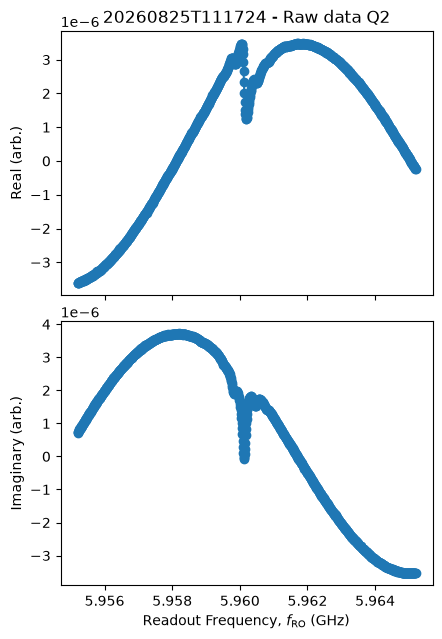

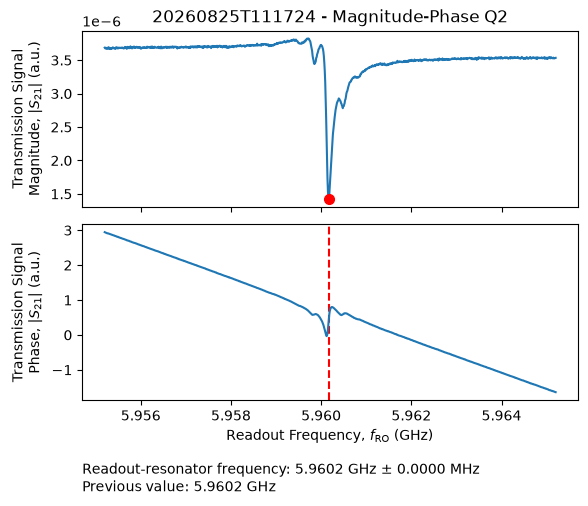

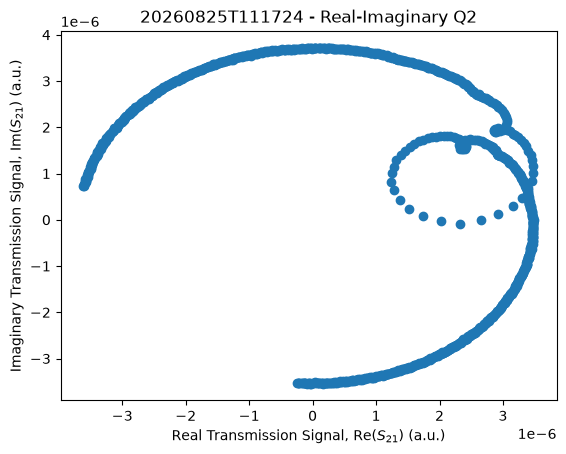

In [20]:
options = resonator_spectroscopy.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

qubit_to_measure = qubits[0]

frequencies = temporary_parameters[q.uid].readout_resonator_frequency + np.linspace(
    -freq_range / 2, freq_range / 2, n_points
)

exp_workflow = resonator_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    frequencies=frequencies,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [21]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    resonator_spectroscopy.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    print("\nReadout resonator frequency: ", qubit_to_measure.parameters.readout_resonator_frequency * 1e-9, ' GHz')
    
    print('\nUpdated global experiment parameters!\n')

Updated global experiment parameters!

{'new_parameter_values': {'Q2': {'readout_resonator_frequency': 5960170000.0+/-0}},
 'old_parameter_values': {'Q2': {'readout_resonator_frequency': 5960200000.0}}}

Readout resonator frequency:  5.960170000000001  GHz


## Qubit Spectroscopy

#### Experiment Parameters

In [27]:
update_global_parameters = True

spectroscopy_length = 10e-6
spectroscopy_amplitude = 0.2
readout_amplitude = 0.2
readout_length = 2e-6
drive_range = -20
n_avg_exponent = 13

freq_range = 100e6
n_points = 251

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.spectroscopy_length = spectroscopy_length
temp_pars.spectroscopy_amplitude = spectroscopy_amplitude
temp_pars.readout_amplitude = readout_amplitude
temp_pars.readout_length = readout_length
temp_pars.drive_range = drive_range
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.25 11:30:02.901] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 11:30:02.901] INFO      Workflow 'qubit_spectroscopy': execution started at 2026-08-25                
[2026.08.25 11:30:02.901] INFO      08:30:02.901943Z                                                              
[2026.08.25 11:30:02.917] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 11:30:03.196] INFO    Task 'temporary_qpu': started at 2026-08-25 08:30:03.196684Z
[2026.08.25 11:30:03.255] INFO    Task 'temporary_qpu': ended at 2026-08-25 08:30:03.255109Z
[2026.08.25 11:30:03.353] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 11:30:03.353] INFO    08:30:03.353456Z
[2026.08.25 11:30:03.413] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 08:30:03.413170Z
[2026.08.25 11:30:03.516] INFO    Task 'create_experiment': started at 2026-08-25 08:

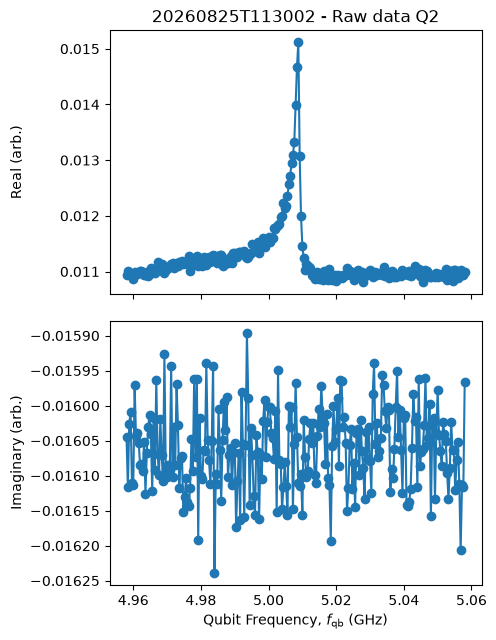

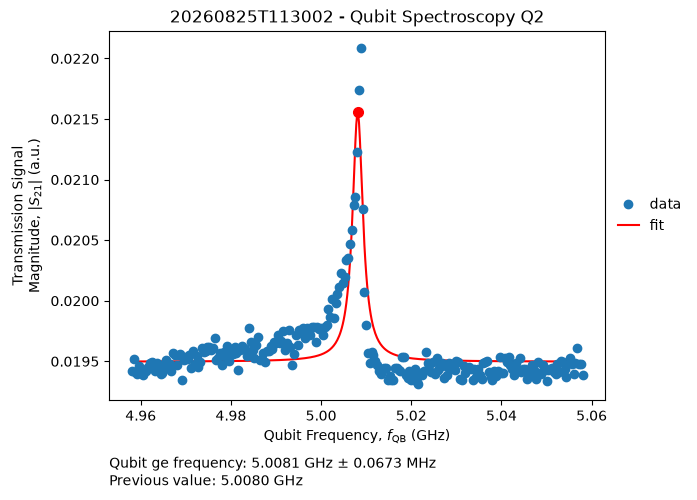

In [30]:
options = qubit_spectroscopy.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False) 
options.close_figures(False)

qubits_to_measure = [qubits[0]]

frequencies = [
    temporary_parameters[q.uid].resonance_frequency_ge + np.linspace(- freq_range / 2, freq_range / 2, n_points)
    for q in qubits_to_measure
]
exp_workflow = qubit_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    frequencies=frequencies,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [29]:
manual_center_frequency = 5.008e9
temporary_parameters[qubit_to_measure.uid].resonance_frequency_ge = manual_center_frequency

In [31]:
analysis_workflow_result= workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    qubit_spectroscopy.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    print("\nReadout resonance frequency ge: ", qubit_to_measure.parameters.resonance_frequency_ge)
    
    print('\nUpdated global experiment parameters!\n')

Updated global experiment parameters!

{'new_parameter_values': {'Q2': {'resonance_frequency_ge': 5008115602.771751+/-67288.13790448953}},
 'old_parameter_values': {'Q2': {'resonance_frequency_ge': 5008000000.0}}}
Readout resonance frequency ge:  5008115602.771751


# Control Pulses

## First Transision: g-e

### Amplitude Rabi

#### Experiment Parameters

In [34]:
update_global_parameters = True

transition = set_transition('ge')

drive_range = 10
drive_length = 100e-9
readout_amplitude = 0.2
n_avg_exponent = 13

amp_min = 0
amp_max = 1
n_amp = 41

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.drive_range = drive_range
temp_pars.readout_amplitude = readout_amplitude
if transition == 'ge':
    temp_pars.ge_drive_length = drive_length
elif transition == 'ef':
    temp_pars.ef_drive_length = drive_length
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.25 11:35:44.111] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 11:35:44.113] INFO      Workflow 'amplitude_rabi': execution started at 2026-08-25 08:35:44.109991Z   
[2026.08.25 11:35:44.115] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 11:35:44.460] INFO    Task 'temporary_qpu': started at 2026-08-25 08:35:44.460488Z
[2026.08.25 11:35:44.549] INFO    Task 'temporary_qpu': ended at 2026-08-25 08:35:44.549233Z
[2026.08.25 11:35:44.670] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 11:35:44.670] INFO    08:35:44.670955Z
[2026.08.25 11:35:44.716] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 08:35:44.714448Z
[2026.08.25 11:35:44.797] INFO    Task 'create_experiment': started at 2026-08-25 08:35:44.797185Z
[2026.08.25 11:35:44.877] INFO    Task 'create_experiment': ended at 2026-08-25 08:35:44.877408Z
[202

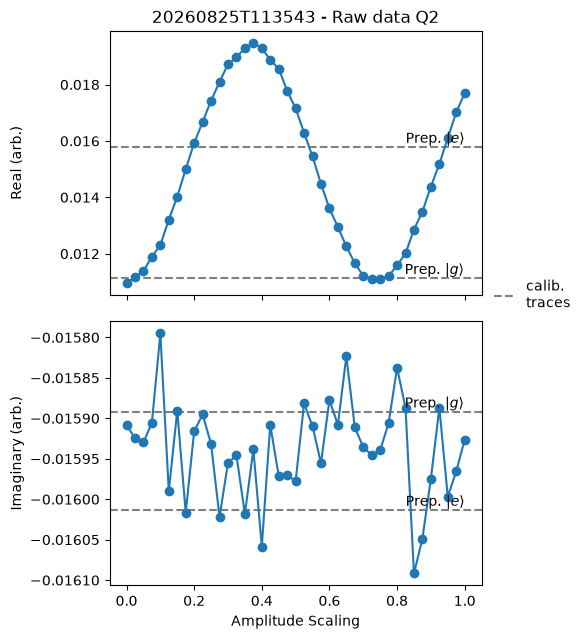

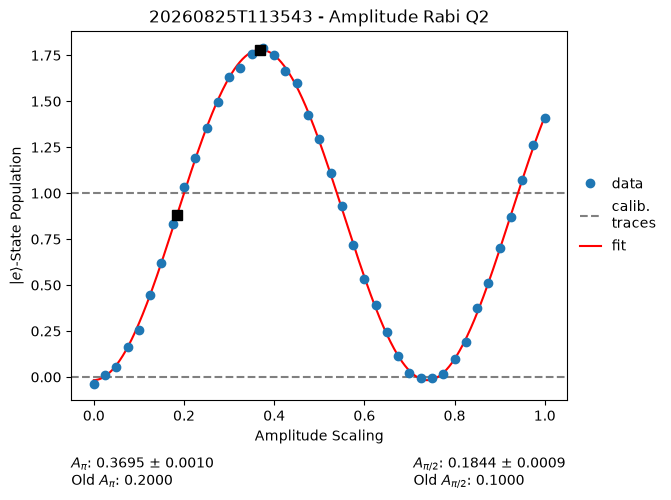

In [35]:
options = amplitude_rabi.experiment_workflow.options()

options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_rabi.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [36]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    
    amplitude_rabi.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nDrive amplitude pi ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
        print("Drive amplitude pi2 ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
    elif transition == 'ef':
        print("\nDrive amplitude pi ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi)
        print("Drive amplitude pi2 ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)
    
    print('\nUpdated global experiment parameters!\n')

Updated global experiment parameters!

{'new_parameter_values': {'Q2': {'ge_drive_amplitude_pi': 0.3695426862928893+/-0.0010423367939460773,
                                 'ge_drive_amplitude_pi2': 0.1844107701092291+/-0.000935774748291959}},
 'old_parameter_values': {'Q2': {'ge_drive_amplitude_pi': 0.2,
                                 'ge_drive_amplitude_pi2': 0.1}}}
Drive amplitude pi ge:  0.3695426862928893
Drive amplitude pi2 ge:  0.1844107701092291


### Rabi Shevron

#### Experiment Parameters

In [38]:
# Rabi chevron is a diagnostic 2D scan (amplitude vs. detuning) - it is not expected
# to update the global qubit parameters directly, so we leave this False by default.
update_global_parameters = False

transition = set_transition('ge')

drive_range = 10
drive_length = 100e-9
readout_amplitude = 0.2
n_avg_exponent = 13

amp_min = 0
amp_max = 1
n_amp = 41

# frequency detuning range swept around the qubit's current resonance frequency
chevron_detuning_min = -6e6
chevron_detuning_max = 2e6
n_detuning = 9
chevron_detunings = np.linspace(chevron_detuning_min, chevron_detuning_max, n_detuning)

if transition == 'ge':
    base_resonance_frequency = qubits[0].parameters.resonance_frequency_ge
elif transition == 'ef':
    base_resonance_frequency = qubits[0].parameters.resonance_frequency_ef

#### Run Workflow

In [44]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)  # suppress per-detuning plots; we build one 2D map below

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

rabi_chevron_results = []

for detuning in chevron_detunings:
    print(f'Measuring chevron point at detuning: {detuning * 1e-6:.3f} MHz')

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.drive_range = drive_range
    temp_pars.readout_amplitude = readout_amplitude
    if transition == 'ge':
        temp_pars.ge_drive_length = drive_length
        temp_pars.resonance_frequency_ge = base_resonance_frequency + detuning
    elif transition == 'ef':
        temp_pars.ef_drive_length = drive_length
        temp_pars.resonance_frequency_ef = base_resonance_frequency + detuning
    temporary_parameters[q.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters
    )
    workflow_result = exp_workflow.run()

    # Raw acquired signal for the qubit under test.
    # NOTE: adjust the accessor below if `get_data` does not match the acquire
    # handle used internally by the installed version of `amplitude_rabi`.
    raw_signal = workflow_result.tasks["run_experiment"].output.get_data(qubit_to_measure.uid+"/result")
    rabi_chevron_results.append(raw_signal)

rabi_chevron_arr = np.array(rabi_chevron_results)
rabi_chevron_amp = np.linspace(amp_min, amp_max, n_amp)

Measuring chevron point at detuning: -6.000 MHz
[2026.08.25 11:46:39.585] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 11:46:39.585] INFO      Workflow 'amplitude_rabi': execution started at 2026-08-25 08:46:39.585209Z   
[2026.08.25 11:46:39.585] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 11:46:39.914] INFO    Task 'temporary_qpu': started at 2026-08-25 08:46:39.914167Z
[2026.08.25 11:46:39.953] INFO    Task 'temporary_qpu': ended at 2026-08-25 08:46:39.953684Z
[2026.08.25 11:46:40.050] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 11:46:40.050] INFO    08:46:40.050400Z
[2026.08.25 11:46:40.101] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 08:46:40.101010Z
[2026.08.25 11:46:40.199] INFO    Task 'create_experiment': started at 2026-08-25 08:46:40.199426Z
[2026.08.25 11:46:40.356] INFO    Task 'create_experi

#### Plot Chevron Map

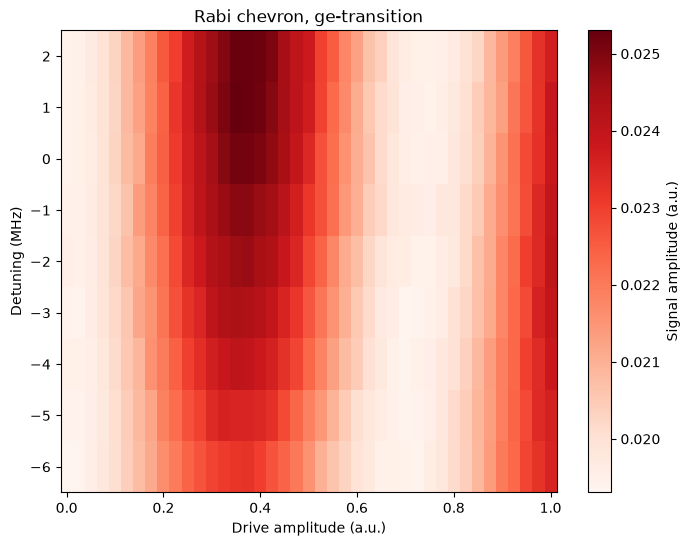

In [45]:
X = rabi_chevron_amp
Y = chevron_detunings * 1e-6
Z = np.absolute(rabi_chevron_arr)

fig, ax = plt.subplots(figsize=(8, 6))
c = ax.pcolormesh(X, Y, Z, cmap='Reds', shading='auto')
fig.colorbar(c, ax=ax, label='Signal amplitude (a.u.)')
ax.set_xlabel('Drive amplitude (a.u.)')
ax.set_ylabel('Detuning (MHz)')
ax.set_title(f'Rabi chevron, {transition}-transition')

figname = f'Rabi_chevron_{transition}_'
file_path = get_path_to_file(figname, '.png')
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

#### Save Data 

In [46]:
Data_rabi_chevron = {
    'rabi_chevron': rabi_chevron_arr,
    'detunings': chevron_detunings,
    'rabi_amp': rabi_chevron_amp,
}

file_name = f'Rabi_chevron_{transition}_'
file_path = get_path_to_file(file_name, '.mat')
savemat(file_path, Data_rabi_chevron)

### Rabi Frequency Calibration

#### Experiment Parameters

In [47]:
# This experiment derives a slope/intercept relation between drive-pulse length and
# the required pi-pulse amplitude. It is diagnostic/informational (used to
# extrapolate the amplitude needed for a target pulse length or Rabi frequency), so
# it does not directly overwrite `qubit_to_measure.parameters` below.
update_global_parameters = False

transition = set_transition('ge')

drive_range = 10
readout_amplitude = 0.2
n_avg_exponent = 12

amp_min = 0
amp_max = 1.0
n_amp = 101

drive_length_min = 50e-9
drive_length_max = 400e-9
n_drive_length = 36
drive_lengths = np.linspace(drive_length_min, drive_length_max, n_drive_length)

#### Run Workflow

In [48]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)  # suppress per-length plots; we build one summary plot below

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

fitted_pi_amplitudes = []

for drive_length in drive_lengths:
    print(f'Measuring Rabi with drive length: {drive_length * 1e9:.1f} ns')

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.drive_range = drive_range
    temp_pars.readout_amplitude = readout_amplitude
    if transition == 'ge':
        temp_pars.ge_drive_length = drive_length
    elif transition == 'ef':
        temp_pars.ef_drive_length = drive_length
    temporary_parameters[q.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters
    )
    workflow_result = exp_workflow.run()

    analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
    # NOTE: adjust the key names below to match the installed library version if
    # `new_parameter_values` is not nested exactly this way.
    new_parameter_values = analysis_workflow_result.output["new_parameter_values"]
    if transition == 'ge':
        fitted_pi_amplitude = new_parameter_values[qubit_to_measure.uid]["ge_drive_amplitude_pi"]
    elif transition == 'ef':
        fitted_pi_amplitude = new_parameter_values[qubit_to_measure.uid]["ef_drive_amplitude_pi"]
    fitted_pi_amplitudes.append(fitted_pi_amplitude)

fitted_pi_amplitudes = np.array(fitted_pi_amplitudes)

Measuring Rabi with drive length: 50.0 ns
[2026.08.25 12:07:04.042] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 12:07:04.046] INFO      Workflow 'amplitude_rabi': execution started at 2026-08-25 09:07:04.042559Z   
[2026.08.25 12:07:04.046] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 12:07:04.401] INFO    Task 'temporary_qpu': started at 2026-08-25 09:07:04.401034Z
[2026.08.25 12:07:04.462] INFO    Task 'temporary_qpu': ended at 2026-08-25 09:07:04.460122Z
[2026.08.25 12:07:04.561] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 12:07:04.563] INFO    09:07:04.561716Z
[2026.08.25 12:07:04.615] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 09:07:04.615436Z
[2026.08.25 12:07:04.701] INFO    Task 'create_experiment': started at 2026-08-25 09:07:04.701500Z
[2026.08.25 12:07:04.814] INFO    Task 'create_experiment':

#### Fit and Plot Amplitude vs. Drive Length

Rabi amplitude-length slope: 3.6770696918395964e-08
Rabi amplitude-length intercept: 0.0008458989025878482


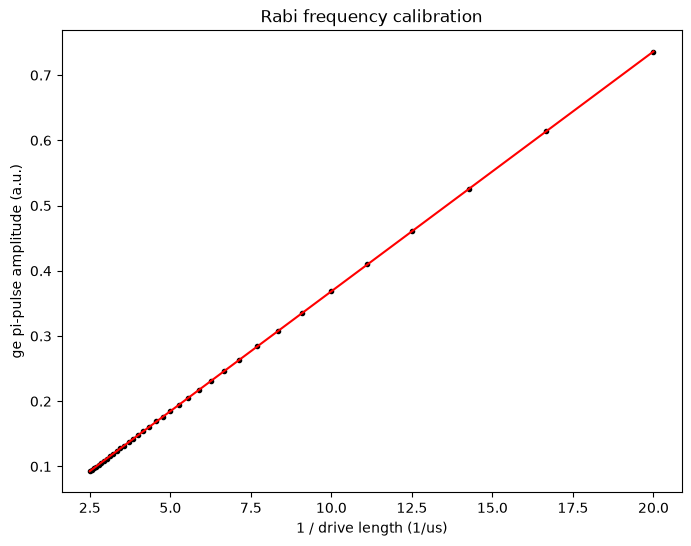

In [51]:
from uncertainties import unumpy as unp

x = (1 / drive_lengths).astype('float64')  # proxy for Rabi frequency scaling with drive length
y = unp.nominal_values(fitted_pi_amplitudes).astype('float64')

rabi_freq_calib_popt, rabi_freq_calib_pcov = np.polyfit(x, y, 1, cov=True)
rabi_slope, rabi_intercept = rabi_freq_calib_popt

print('Rabi amplitude-length slope:', rabi_slope)
print('Rabi amplitude-length intercept:', rabi_intercept)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x * 1e-6, y, '.k')
ax.plot(x * 1e-6, np.polyval(rabi_freq_calib_popt, x), '-r')
ax.set_xlabel('1 / drive length (1/us)')
ax.set_ylabel(f'{transition} pi-pulse amplitude (a.u.)')
ax.set_title('Rabi frequency calibration')

figname = f'Rabi_freq_calib_{transition}_'
file_path = get_path_to_file(figname, '.png')
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

#### Save Data

In [53]:
Data_rabi_freq_calib = {
    'drive_lengths': drive_lengths,
    'fitted_pi_amplitudes':  unp.nominal_values(fitted_pi_amplitudes).astype('float64'),
    'rabi_slope': rabi_slope,
    'rabi_intercept': rabi_intercept,
}

file_name = f'Rabi_freq_calib_{transition}_'
file_path = get_path_to_file(file_name, '.mat')
savemat(file_path, Data_rabi_freq_calib)

### Rabi Error Amplification

#### x180 pulse

##### Experiment Parameters

In [56]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

x180_max_repetitions = 16
x180_repetitions = list(range(0, x180_max_repetitions + 1))

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

##### Run Workflow

[2026.08.25 14:41:58.407] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 14:41:58.407] INFO      Workflow 'experiment_workflow_x180': execution started at 2026-08-25          
[2026.08.25 14:41:58.407] INFO      11:41:58.407340Z                                                              
[2026.08.25 14:41:58.407] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 14:41:58.792] INFO    Task 'temporary_qpu': started at 2026-08-25 11:41:58.792855Z
[2026.08.25 14:41:58.873] INFO    Task 'temporary_qpu': ended at 2026-08-25 11:41:58.873971Z
[2026.08.25 14:41:59.003] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 14:41:59.003] INFO    11:41:59.003793Z
[2026.08.25 14:41:59.073] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 11:41:59.073391Z
[2026.08.25 14:41:59.206] INFO    Task 'create_experiment': started at 2026-08-25 11:

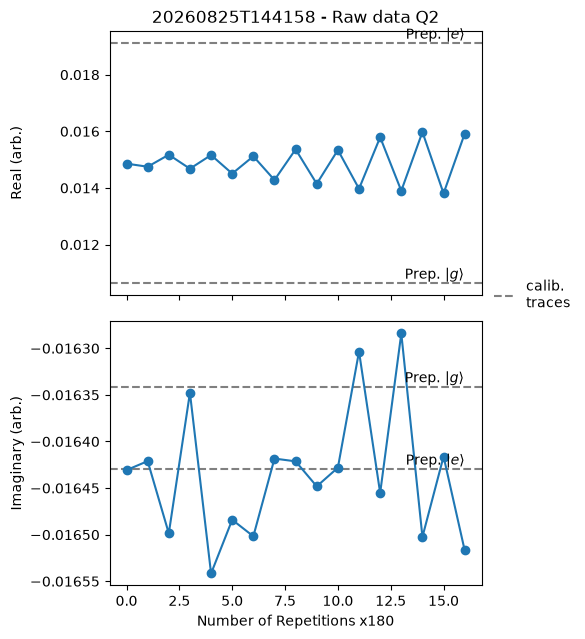

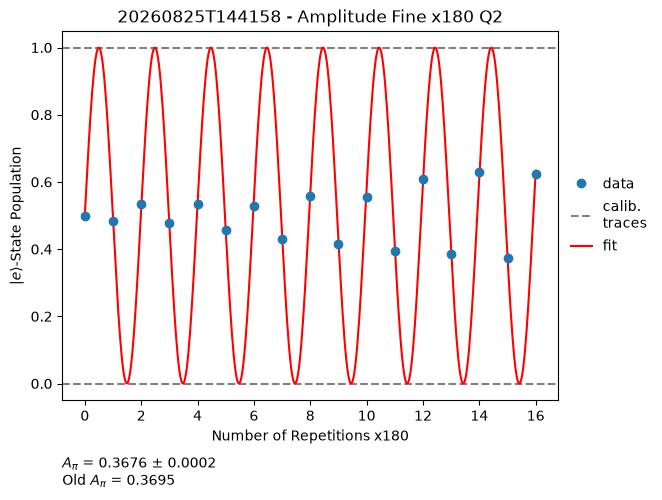

In [57]:
options = amplitude_fine.experiment_workflow_x180.options()
options.count(2**n_avg_exponent)
options.close_figures(False)  # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_fine.experiment_workflow_x180(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    repetitions=[x180_repetitions for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

##### Update Parameters

In [58]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    
    amplitude_fine.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nDrive amplitude pi ge (error-amplified): ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
    elif transition == 'ef':
        print("\nDrive amplitude pi ef (error-amplified): ", qubit_to_measure.parameters.ef_drive_amplitude_pi)
        
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_drive_amplitude_pi': 0.3675929365111754+/-0.00015603200117427992}},
 'old_parameter_values': {'Q2': {'ge_drive_amplitude_pi': 0.3695426862928893}}}

Drive amplitude pi ge (error-amplified):  0.3675929365111754

Updated global experiment parameters!



#### x90 pulse

##### Experiment Parameters

In [59]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

x90_max_repetitions = 40
x90_repetitions = list(range(1, x90_max_repetitions + 1, 2))

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

##### Run Workflow

[2026.08.25 14:43:17.531] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 14:43:17.531] INFO      Workflow 'experiment_workflow_x90': execution started at 2026-08-25           
[2026.08.25 14:43:17.531] INFO      11:43:17.531690Z                                                              
[2026.08.25 14:43:17.531] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 14:43:18.032] INFO    Task 'temporary_qpu': started at 2026-08-25 11:43:18.030694Z
[2026.08.25 14:43:18.141] INFO    Task 'temporary_qpu': ended at 2026-08-25 11:43:18.141472Z
[2026.08.25 14:43:18.350] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 14:43:18.350] INFO    11:43:18.350471Z
[2026.08.25 14:43:18.447] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 11:43:18.447430Z
[2026.08.25 14:43:18.641] INFO    Task 'create_experiment': started at 2026-08-25 11:

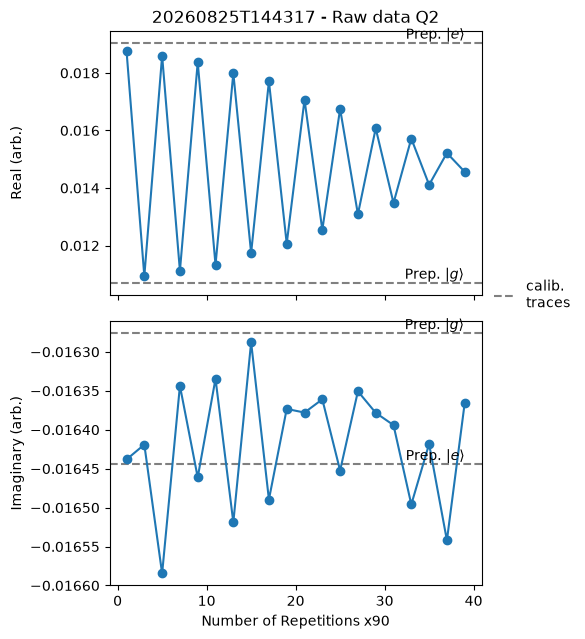

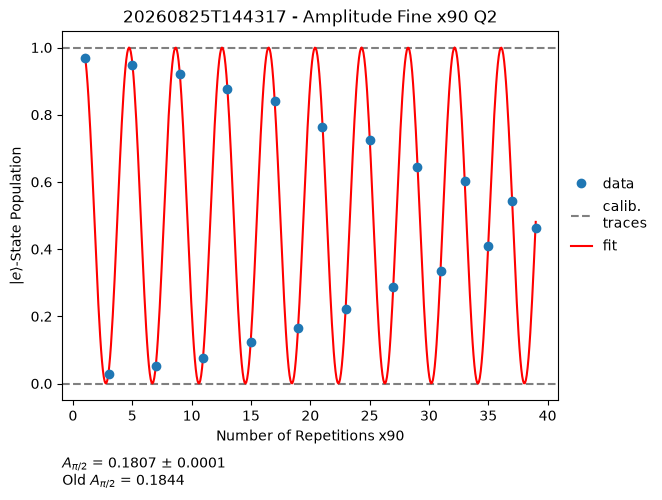

In [60]:
options = amplitude_fine.experiment_workflow_x90.options()
options.count(2**n_avg_exponent)
options.close_figures(False)  # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_fine.experiment_workflow_x90(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    repetitions=[x90_repetitions for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

##### Update Parameters

In [61]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    amplitude_fine.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nDrive amplitude pi2 ge (error-amplified): ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
    elif transition == 'ef':
        print("\nDrive amplitude pi2 ef (error-amplified): ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)
    
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_drive_amplitude_pi2': 0.18067761126293605+/-0.0001066448427428813}},
 'old_parameter_values': {'Q2': {'ge_drive_amplitude_pi2': 0.1844107701092291}}}

Drive amplitude pi2 ge (error-amplified):  0.18067761126293605

Updated global experiment parameters!



### Ramsey

#### Experiment Parameters

In [74]:
update_global_parameters = True

detuning = 0.8e6
transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 70e-6
n_delay = 101

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.25 15:34:28.959] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 15:34:28.959] INFO      Workflow 'ramsey': execution started at 2026-08-25 12:34:28.959075Z           
[2026.08.25 15:34:28.959] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 15:34:29.378] INFO    Task 'temporary_qpu': started at 2026-08-25 12:34:29.378268Z
[2026.08.25 15:34:29.441] INFO    Task 'temporary_qpu': ended at 2026-08-25 12:34:29.441774Z
[2026.08.25 15:34:29.642] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 15:34:29.642] INFO    12:34:29.642121Z
[2026.08.25 15:34:29.940] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 12:34:29.940617Z
[2026.08.25 15:34:30.058] INFO    Task 'create_experiment': started at 2026-08-25 12:34:30.058804Z
[2026.08.25 15:34:30.201] INFO    Task 'create_experiment': ended at 2026-08-25 12:34:30.201459Z
[202

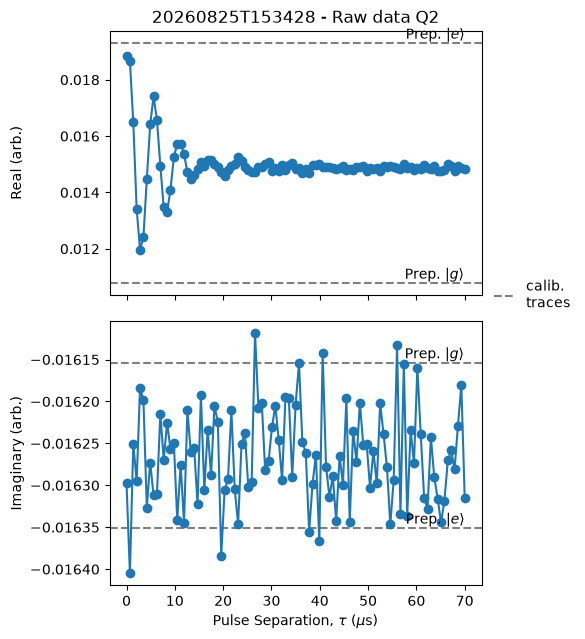

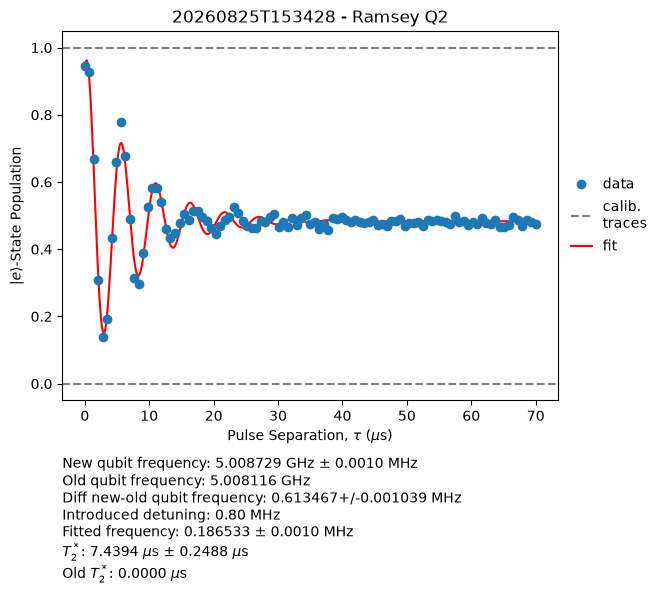

In [75]:
options = ramsey.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Ramsey in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
# qubits_to_measure = [qubits[0], qubits[2]]
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]
detunings = [
    detuning
]

exp_workflow = ramsey.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    detunings=detunings,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [76]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nge_T2_star: ", qubit_to_measure.parameters.ge_T2_star)
        print("resonance_frequency_ge: ", qubit_to_measure.parameters.resonance_frequency_ge)
    elif transition == 'ef':
        print("\nef_T2_star: ", qubit_to_measure.parameters.ef_T2_star)
        print("resonance_frequency_ef: ", qubit_to_measure.parameters.resonance_frequency_ef)
    
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_T2_star': 7.439383035157121e-06+/-2.488130389410491e-07,
                                 'resonance_frequency_ge': 5008729069.822789+/-1038.7006884343832}},
 'old_parameter_values': {'Q2': {'ge_T2_star': 0,
                                 'resonance_frequency_ge': 5008115602.771751}}}

ge_T2_star:  7.439383035157121e-06
resonance_frequency_ge:  5008729069.822789

Updated global experiment parameters!



### T1 Lifetime

#### Experiment Parameters

In [62]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 80e-6
n_delay = 51
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.25 14:45:26.044] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 14:45:26.045] INFO      Workflow 'lifetime_measurement': execution started at 2026-08-25              
[2026.08.25 14:45:26.045] INFO      11:45:26.037654Z                                                              
[2026.08.25 14:45:26.045] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 14:45:26.429] INFO    Task 'temporary_qpu': started at 2026-08-25 11:45:26.429522Z
[2026.08.25 14:45:26.489] INFO    Task 'temporary_qpu': ended at 2026-08-25 11:45:26.489624Z
[2026.08.25 14:45:26.599] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 14:45:26.600] INFO    11:45:26.589945Z
[2026.08.25 14:45:26.650] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 11:45:26.641279Z
[2026.08.25 14:45:26.750] INFO    Task 'create_experiment': started at 2026-08-25 11:

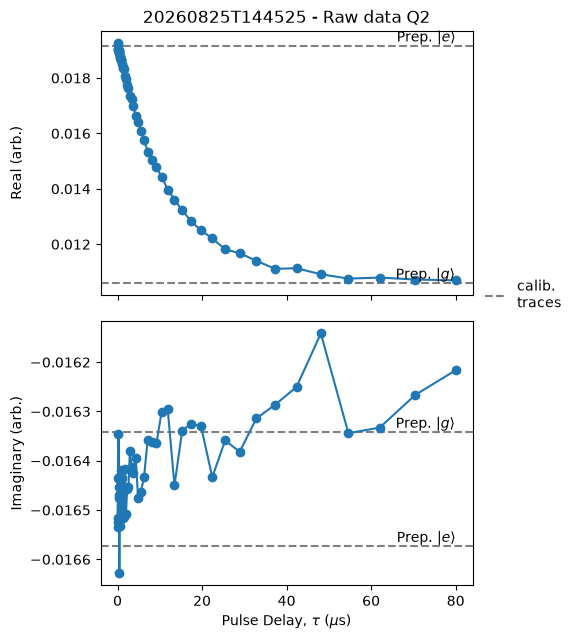

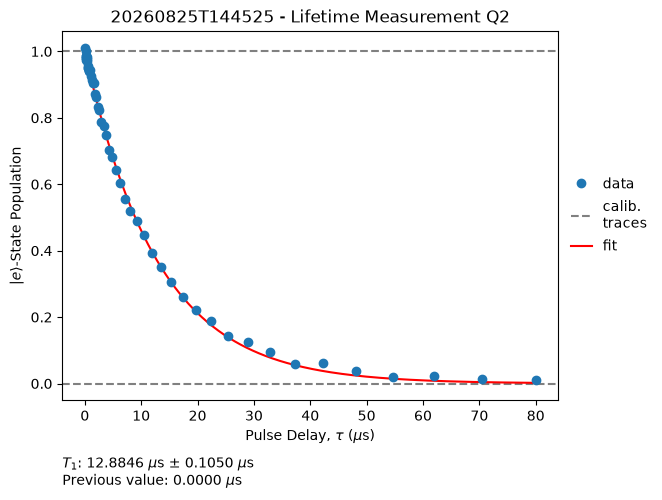

In [63]:
options = lifetime_measurement.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

if log_spacing:
    delays = [log_sweep_help(delay_min, delay_max, n_delay)]
else:
    delays = [np.linspace(delay_min, delay_max, n_delay)]

exp_workflow = lifetime_measurement.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters 
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [64]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    lifetime_measurement.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nge_T1: ", qubit_to_measure.parameters.ge_T1)
    elif transition == 'ef':
        print("\nef_T1: ", qubit_to_measure.parameters.ef_T1)
    
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_T1': 1.2884569729022237e-05+/-1.0503812894630302e-07}},
 'old_parameter_values': {'Q2': {'ge_T1': 0}}}

ge_T1:  1.2884569729022237e-05

Updated global experiment parameters!



In [ ]:
qubits[0].parameters.reset_delay_length = 300e-6
qubits[0].parameters.readout_range_out = -30

### DRAG Calibration

#### Experiment Parameters

In [77]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

q_min = -0.1
q_max = 0.1
n_q = 51

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.25 15:39:18.647] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 15:39:18.650] INFO      Workflow 'drag_q_scaling': execution started at 2026-08-25 12:39:18.647826Z   
[2026.08.25 15:39:18.650] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 15:39:18.889] INFO    Task 'temporary_qpu': started at 2026-08-25 12:39:18.889062Z
[2026.08.25 15:39:18.938] INFO    Task 'temporary_qpu': ended at 2026-08-25 12:39:18.938608Z
[2026.08.25 15:39:19.052] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 15:39:19.052] INFO    12:39:19.049714Z
[2026.08.25 15:39:19.107] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 12:39:19.107075Z
[2026.08.25 15:39:19.207] INFO    Task 'create_experiment': started at 2026-08-25 12:39:19.207195Z
[2026.08.25 15:39:19.353] INFO    Task 'create_experiment': ended at 2026-08-25 12:39:19.353520Z
[202

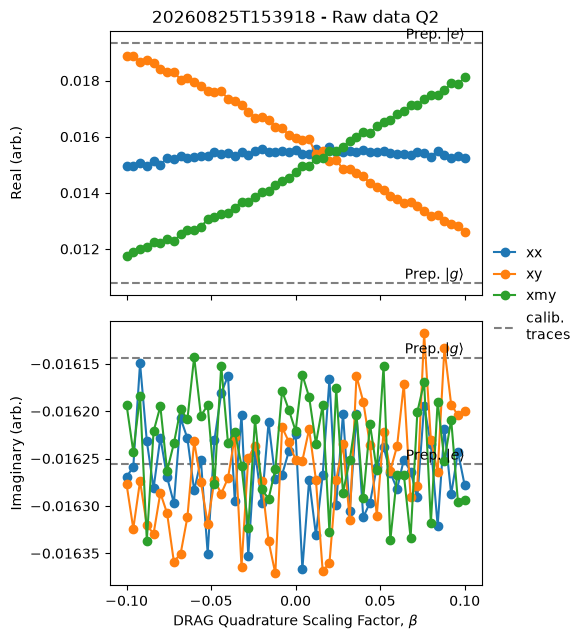

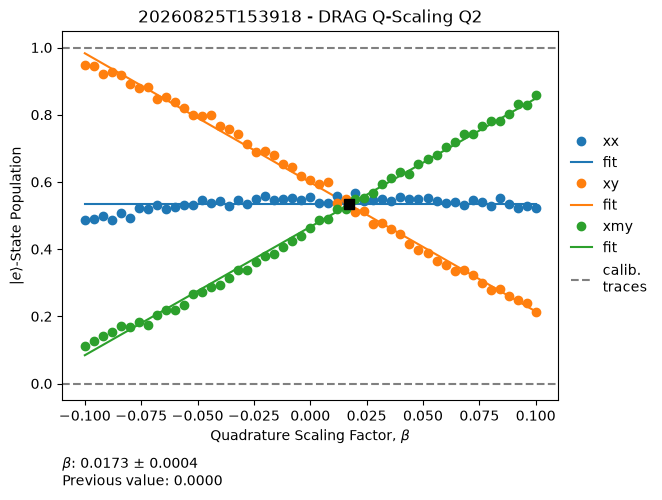

In [78]:
options = drag_q_scaling.experiment_workflow.options()
# options.update(True)  # updates the qubit parameter 'ge_drive_pulse["beta"]'
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = drag_q_scaling.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    q_scalings=[np.linspace(q_min, q_max, n_q) for _ in qubits_to_measure],
    options=options,
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [79]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

    drag_q_scaling.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nge_drive_pulse[beta]: ", qubit_to_measure.parameters.ge_drive_pulse["beta"])
    elif transition == 'ef':
        print("\nef_drive_pulse[beta]: ", qubit_to_measure.parameters.ef_drive_pulse["beta"])
    
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_drive_pulse.beta': 0.01728693103288088+/-0.0003784190809230285}},
 'old_parameter_values': {'Q2': {'ge_drive_pulse.beta': 0}}}

ge_drive_pulse[beta]:  0.01728693103288088

Updated global experiment parameters!



### Hahn-Echo

#### Experiment Parameters

In [80]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 100e-6
n_delay = 71
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.25 15:45:47.420] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 15:45:47.420] INFO      Workflow 'echo': execution started at 2026-08-25 12:45:47.420000Z             
[2026.08.25 15:45:47.420] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 15:45:47.749] INFO    Task 'temporary_qpu': started at 2026-08-25 12:45:47.749728Z
[2026.08.25 15:45:47.805] INFO    Task 'temporary_qpu': ended at 2026-08-25 12:45:47.805348Z
[2026.08.25 15:45:47.918] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 15:45:47.918] INFO    12:45:47.918808Z
[2026.08.25 15:45:47.981] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 12:45:47.981997Z
[2026.08.25 15:45:48.119] INFO    Task 'create_experiment': started at 2026-08-25 12:45:48.119328Z
[2026.08.25 15:45:48.259] INFO    Task 'create_experiment': ended at 2026-08-25 12:45:48.259364Z
[202

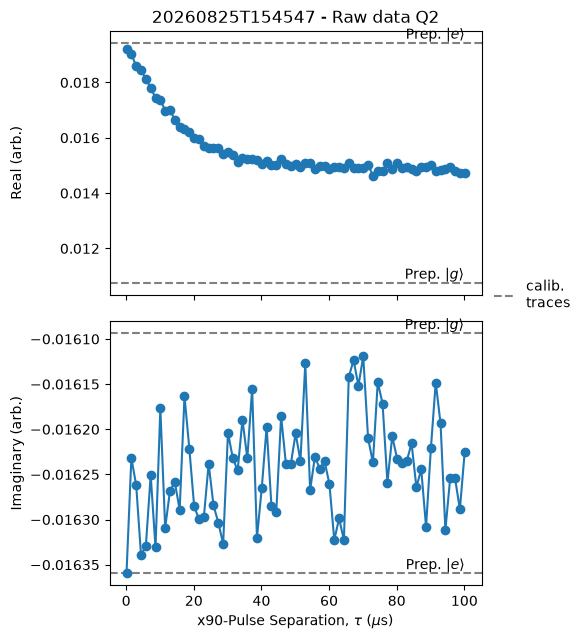

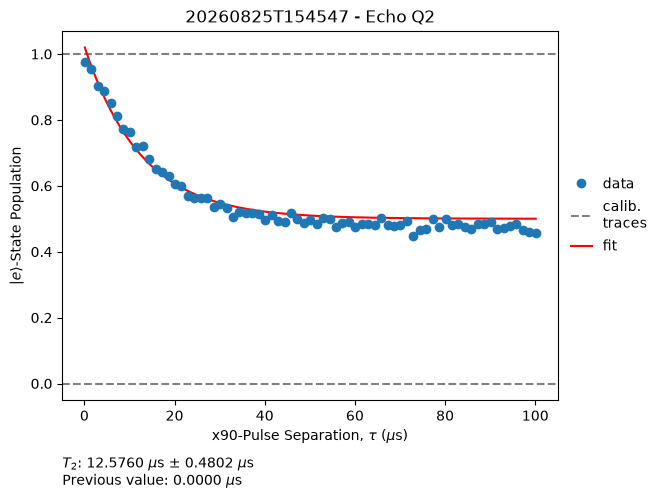

In [81]:
options = echo.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Echo in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]

exp_workflow = echo.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [82]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    echo.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nge_T2: ", qubit_to_measure.parameters.ge_T2)
    elif transition == 'ef':
        print("\nef_T2: ", qubit_to_measure.parameters.ef_T2)
    
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_T2': 1.257596576271114e-05+/-4.80195775570409e-07}},
 'old_parameter_values': {'Q2': {'ge_T2': 0}}}

ge_T2:  1.257596576271114e-05

Updated global experiment parameters!



In [83]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.2884569729022237e-05,
│   │   ge_T2=1.257596576271114e-05,
│   │   ge_T2_star=7.439383035157121e-06,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5008729069.822789,
│   │   resonance_frequency_ef=4800000000.0,
│   │   readout_resonator_frequency=5960170000.0,
│   │   ge_drive_amplitude_pi=0.3675929365111754,
│   │   ge_drive_amplitude_pi2=0.18067761126293605,
│   │   ge_drive_length=1e-07,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0.01728693103288088,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │ 

## Second Transition: e-f

### Amplitude Rabi

#### Experiment Parameters

In [85]:
update_global_parameters = True

transition = set_transition('ef')

drive_range = 10
drive_length = 100e-9
readout_amplitude = 0.3
n_avg_exponent = 13

amp_min = 0
amp_max = 1
n_amp = 31

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.drive_range = drive_range
temp_pars.readout_amplitude = readout_amplitude
if transition == 'ge':
    temp_pars.ge_drive_length = drive_length
elif transition == 'ef':
    temp_pars.ef_drive_length = drive_length
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.25 15:52:17.919] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 15:52:17.919] INFO      Workflow 'amplitude_rabi': execution started at 2026-08-25 12:52:17.912606Z   
[2026.08.25 15:52:17.919] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 15:52:18.212] INFO    Task 'temporary_qpu': started at 2026-08-25 12:52:18.212264Z
[2026.08.25 15:52:18.276] INFO    Task 'temporary_qpu': ended at 2026-08-25 12:52:18.276541Z
[2026.08.25 15:52:18.420] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 15:52:18.420] INFO    12:52:18.420940Z
[2026.08.25 15:52:18.489] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 12:52:18.489699Z
[2026.08.25 15:52:18.629] INFO    Task 'create_experiment': started at 2026-08-25 12:52:18.620009Z
[2026.08.25 15:52:18.759] INFO    Task 'create_experiment': ended at 2026-08-25 12:52:18.759463Z
[202

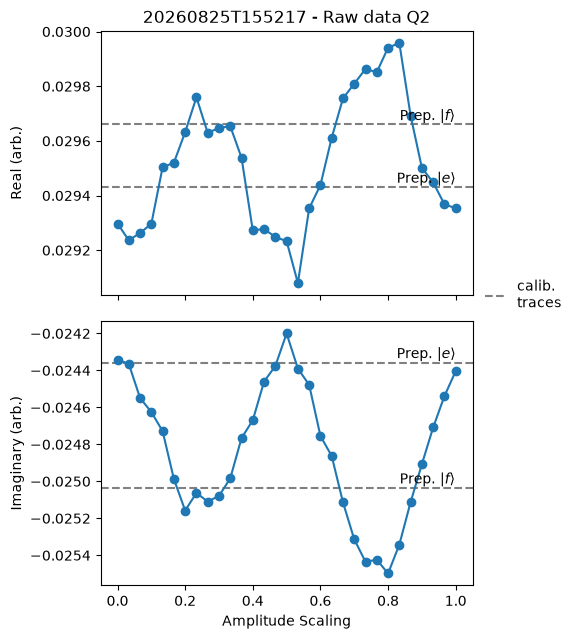

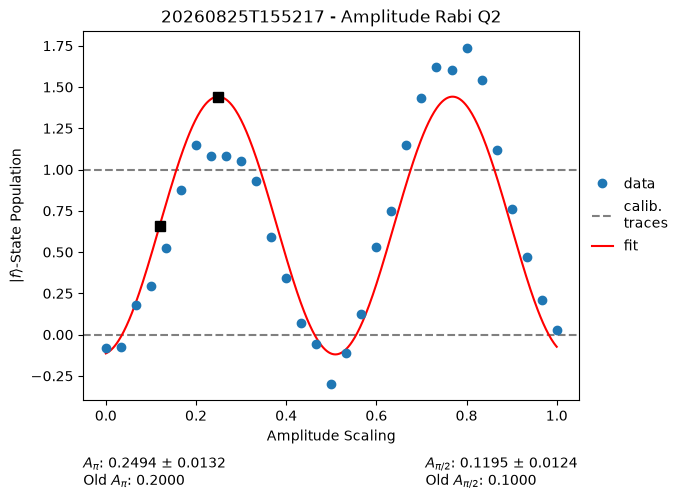

In [86]:
options = amplitude_rabi.experiment_workflow.options()

options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_rabi.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [87]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    amplitude_rabi.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nDrive amplitude pi ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
        print("Drive amplitude pi2 ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
    elif transition == 'ef':
        print("\nDrive amplitude pi ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi)
        print("Drive amplitude pi2 ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)
    
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_drive_amplitude_pi': 0.24940709147532214+/-0.013196996734607407,
                                 'ef_drive_amplitude_pi2': 0.1195299628236887+/-0.012365783585156642}},
 'old_parameter_values': {'Q2': {'ef_drive_amplitude_pi': 0.2,
                                 'ef_drive_amplitude_pi2': 0.1}}}

Drive amplitude pi ef:  0.24940709147532214
Drive amplitude pi2 ef:  0.1195299628236887

Updated global experiment parameters!



### Rabi Chevron

#### Experiment Parameters

In [88]:
update_global_parameters = False

transition = set_transition('ef')

drive_range = 10
drive_length = 100e-9
readout_amplitude = 0.2
n_avg_exponent = 12

amp_min = 0
amp_max = 1
n_amp = 31

chevron_detuning_min = -3.0e6
chevron_detuning_max = 3.0e6
n_detuning = 7
chevron_detunings = np.linspace(chevron_detuning_min, chevron_detuning_max, n_detuning)

if transition == 'ge':
    base_resonance_frequency = qubit_to_measure.parameters.resonance_frequency_ge
elif transition == 'ef':
    base_resonance_frequency = qubit_to_measure.parameters.resonance_frequency_ef

#### Run Workflow

In [90]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

rabi_chevron_results = []

for detuning in chevron_detunings:
    print(f'Measuring chevron point at detuning: {detuning * 1e-6:.3f} MHz')

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.drive_range = drive_range
    temp_pars.readout_amplitude = readout_amplitude
    if transition == 'ge':
        temp_pars.ge_drive_length = drive_length
        temp_pars.resonance_frequency_ge = base_resonance_frequency + detuning
    elif transition == 'ef':
        temp_pars.ef_drive_length = drive_length
        temp_pars.resonance_frequency_ef = base_resonance_frequency + detuning
    temporary_parameters[q.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters
    )
    workflow_result = exp_workflow.run()

    raw_signal = workflow_result.tasks["run_experiment"].output.get_data(qubit_to_measure.uid+"/result")
    rabi_chevron_results.append(raw_signal)

rabi_chevron_arr = np.array(rabi_chevron_results)
rabi_chevron_amp = np.linspace(amp_min, amp_max, n_amp)

Measuring chevron point at detuning: -3.000 MHz
[2026.08.25 15:55:27.595] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 15:55:27.608] INFO      Workflow 'amplitude_rabi': execution started at 2026-08-25 12:55:27.595034Z   
[2026.08.25 15:55:27.608] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 15:55:27.895] INFO    Task 'temporary_qpu': started at 2026-08-25 12:55:27.895182Z
[2026.08.25 15:55:27.954] INFO    Task 'temporary_qpu': ended at 2026-08-25 12:55:27.954897Z
[2026.08.25 15:55:28.126] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 15:55:28.126] INFO    12:55:28.126815Z
[2026.08.25 15:55:28.178] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 12:55:28.178781Z
[2026.08.25 15:55:28.304] INFO    Task 'create_experiment': started at 2026-08-25 12:55:28.304060Z
[2026.08.25 15:55:28.457] INFO    Task 'create_experi

#### Plot Chevron Map

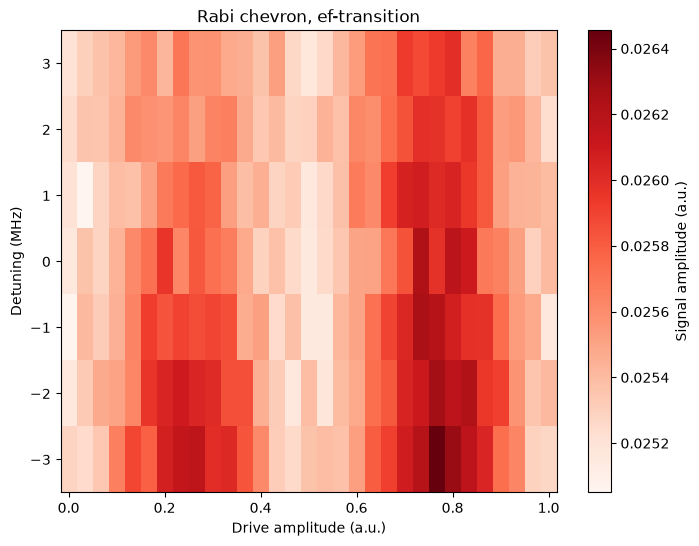

In [91]:
X = rabi_chevron_amp
Y = chevron_detunings * 1e-6
Z = np.absolute(rabi_chevron_arr)

fig, ax = plt.subplots(figsize=(8, 6))
c = ax.pcolormesh(X, Y, Z, cmap='Reds', shading='auto')
fig.colorbar(c, ax=ax, label='Signal amplitude (a.u.)')
ax.set_xlabel('Drive amplitude (a.u.)')
ax.set_ylabel('Detuning (MHz)')
ax.set_title(f'Rabi chevron, {transition}-transition')

figname = f'Rabi_chevron_{transition}_'
file_path = get_path_to_file(figname, '.png')
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

#### Save Data

In [92]:
Data_rabi_chevron = {
    'rabi_chevron': rabi_chevron_arr,
    'detunings': chevron_detunings,
    'rabi_amp': rabi_chevron_amp,
}

file_name = f'Rabi_chevron_{transition}_'
file_path = get_path_to_file(file_name, '.mat')
savemat(file_path, Data_rabi_chevron)

### Rabi Frequency Calibration

#### Experiment Parameters

In [105]:
update_global_parameters = False

transition = set_transition('ef')

drive_range = 10
readout_amplitude = 0.1
n_avg_exponent = 12

amp_min = 0
amp_max = 1.0
n_amp = 101

drive_length_min = 50e-9
drive_length_max = 400e-9
n_drive_length = 36
drive_lengths = np.linspace(drive_length_min, drive_length_max, n_drive_length)

#### Run Workflow

In [106]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

fitted_pi_amplitudes = []

for drive_length in drive_lengths:
    print(f'Measuring Rabi with drive length: {drive_length * 1e9:.1f} ns')

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.drive_range = drive_range
    temp_pars.readout_amplitude = readout_amplitude
    if transition == 'ge':
        temp_pars.ge_drive_length = drive_length
    elif transition == 'ef':
        temp_pars.ef_drive_length = drive_length
    temporary_parameters[q.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters
    )
    workflow_result = exp_workflow.run()

    analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
    new_parameter_values = analysis_workflow_result.output["new_parameter_values"]
    if transition == 'ge':
        fitted_pi_amplitude = new_parameter_values[qubit_to_measure.uid]["ge_drive_amplitude_pi"]
    elif transition == 'ef':
        fitted_pi_amplitude = new_parameter_values[qubit_to_measure.uid]["ef_drive_amplitude_pi"]
    fitted_pi_amplitudes.append(fitted_pi_amplitude)

fitted_pi_amplitudes = np.array(fitted_pi_amplitudes)

Measuring Rabi with drive length: 50.0 ns
[2026.08.25 16:21:50.268] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:21:50.268] INFO      Workflow 'amplitude_rabi': execution started at 2026-08-25 13:21:50.268527Z   
[2026.08.25 16:21:50.268] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:21:50.593] INFO    Task 'temporary_qpu': started at 2026-08-25 13:21:50.593579Z
[2026.08.25 16:21:50.644] INFO    Task 'temporary_qpu': ended at 2026-08-25 13:21:50.643294Z
[2026.08.25 16:21:50.743] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 16:21:50.744] INFO    13:21:50.743204Z
[2026.08.25 16:21:50.811] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 13:21:50.809675Z
[2026.08.25 16:21:50.944] INFO    Task 'create_experiment': started at 2026-08-25 13:21:50.944461Z
[2026.08.25 16:21:51.102] INFO    Task 'create_experiment':

[2026.08.25 16:54:50.319] ERROR   Could not extract pi- and pi/2-pulse amplitudes for Q2.


[2026.08.25 16:54:50.384] INFO    Task 'extract_qubit_parameters': ended at 2026-08-25 13:54:50.384642Z
[2026.08.25 16:54:50.480] INFO    Task 'plot_raw_complex_data_1d': started at 2026-08-25 13:54:50.480351Z
[2026.08.25 16:54:50.623] INFO    Artifact: 'Raw_data_Q2' of type 'Figure' logged at 2026-08-25 13:54:50.623142Z
[2026.08.25 16:54:51.027] INFO    Task 'plot_raw_complex_data_1d': ended at 2026-08-25 13:54:51.027199Z
[2026.08.25 16:54:51.076] INFO    Task 'plot_population': started at 2026-08-25 13:54:51.076989Z
[2026.08.25 16:54:51.173] INFO    Artifact: 'Rabi_Q2' of type 'Figure' logged at 2026-08-25 13:54:51.173022Z
[2026.08.25 16:54:51.414] INFO    Task 'plot_population': ended at 2026-08-25 13:54:51.414647Z
[2026.08.25 16:54:51.450] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:54:51.450] INFO      Workflow 'analysis_workflow': execution ended at 2026-08-25 13:54:51.450936Z  
[2026.08.25 16:54:51.450] INFO     ───────

KeyError: 'ef_drive_amplitude_pi'

#### Fit and Plot Amplitude vs. Drive Length

In [ ]:
from uncertainties import unumpy as unp

x = (1 / drive_lengths).astype('float64')  # proxy for Rabi frequency scaling with drive length
y = unp.nominal_values(fitted_pi_amplitudes).astype('float64')

rabi_freq_calib_popt, rabi_freq_calib_pcov = np.polyfit(x, y, 1, cov=True)
rabi_slope, rabi_intercept = rabi_freq_calib_popt

print('Rabi amplitude-length slope:', rabi_slope)
print('Rabi amplitude-length intercept:', rabi_intercept)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x * 1e-6, y, '.k')
ax.plot(x * 1e-6, np.polyval(rabi_freq_calib_popt, x), '-r')
ax.set_xlabel('1 / drive length (1/us)')
ax.set_ylabel(f'{transition} pi-pulse amplitude (a.u.)')
ax.set_title('Rabi frequency calibration')

figname = f'Rabi_freq_calib_{transition}_'
file_path = get_path_to_file(figname, '.png')
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

#### Save Data

In [ ]:
Data_rabi_freq_calib = {
    'drive_lengths': drive_lengths,
    'fitted_pi_amplitudes': unp.nominal_values(fitted_pi_amplitudes).astype('float64'),
    'rabi_slope': rabi_slope,
    'rabi_intercept': rabi_intercept,
}

file_name = f'Rabi_freq_calib_{transition}_'
file_path = get_path_to_file(file_name, '.mat')
savemat(file_path, Data_rabi_freq_calib)

### Rabi Error Amplification

#### x180 pulse

##### Experiment Parameters

In [95]:
update_global_parameters = True

transition = set_transition('ef')

n_avg_exponent = 13

x180_max_repetitions = 16
x180_repetitions = list(range(0, x180_max_repetitions + 1))

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

##### Run Workflow

[2026.08.25 16:12:27.732] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:12:27.732] INFO      Workflow 'experiment_workflow_x180': execution started at 2026-08-25          
[2026.08.25 16:12:27.732] INFO      13:12:27.726727Z                                                              
[2026.08.25 16:12:27.732] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:12:28.032] INFO    Task 'temporary_qpu': started at 2026-08-25 13:12:28.032756Z
[2026.08.25 16:12:28.091] INFO    Task 'temporary_qpu': ended at 2026-08-25 13:12:28.091277Z
[2026.08.25 16:12:28.224] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 16:12:28.225] INFO    13:12:28.224994Z
[2026.08.25 16:12:28.289] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 13:12:28.289769Z
[2026.08.25 16:12:28.420] INFO    Task 'create_experiment': started at 2026-08-25 13:

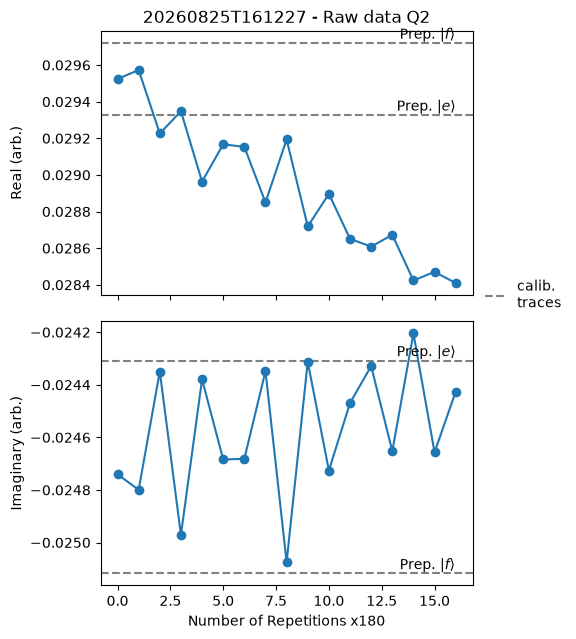

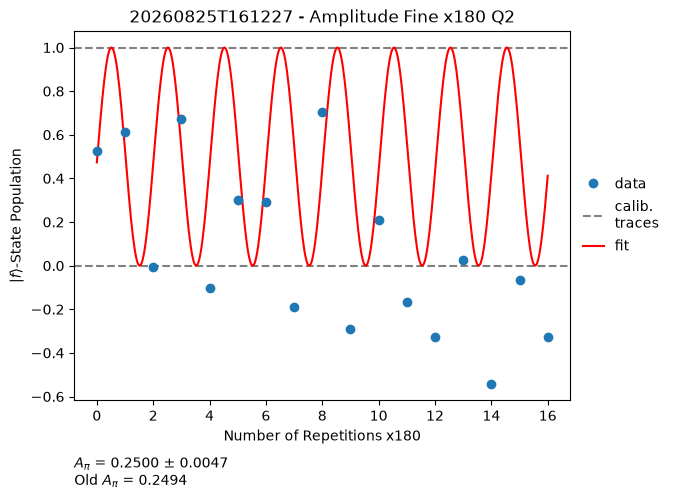

In [96]:
options = amplitude_fine.experiment_workflow_x180.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_fine.experiment_workflow_x180(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    repetitions=[x180_repetitions for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

##### Update Parameters

In [97]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    amplitude_fine.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nDrive amplitude pi ge (error-amplified): ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
    elif transition == 'ef':
        print("\nDrive amplitude pi ef (error-amplified): ", qubit_to_measure.parameters.ef_drive_amplitude_pi)
    
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_drive_amplitude_pi': 0.2500217645914539+/-0.004743775356932127}},
 'old_parameter_values': {'Q2': {'ef_drive_amplitude_pi': 0.24940709147532214}}}

Drive amplitude pi ef (error-amplified):  0.2500217645914539

Updated global experiment parameters!



#### x90 pulse

##### Experiment Parameters

In [98]:
update_global_parameters = True

transition = set_transition('ef')

n_avg_exponent = 13

x90_max_repetitions = 18
x90_repetitions = list(range(1, x90_max_repetitions + 1, 2))

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

##### Run Workflow

[2026.08.25 16:14:41.675] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:14:41.681] INFO      Workflow 'experiment_workflow_x90': execution started at 2026-08-25           
[2026.08.25 16:14:41.681] INFO      13:14:41.675925Z                                                              
[2026.08.25 16:14:41.683] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:14:41.957] INFO    Task 'temporary_qpu': started at 2026-08-25 13:14:41.957715Z
[2026.08.25 16:14:42.004] INFO    Task 'temporary_qpu': ended at 2026-08-25 13:14:42.004036Z
[2026.08.25 16:14:42.116] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 16:14:42.116] INFO    13:14:42.116650Z
[2026.08.25 16:14:42.183] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 13:14:42.180578Z
[2026.08.25 16:14:42.310] INFO    Task 'create_experiment': started at 2026-08-25 13:

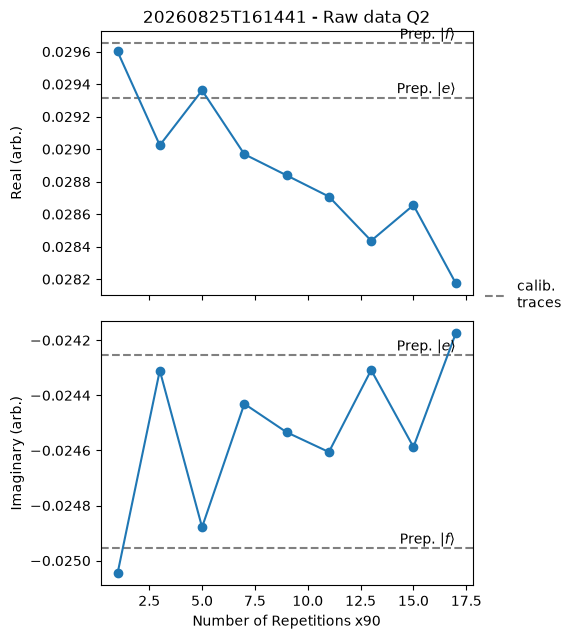

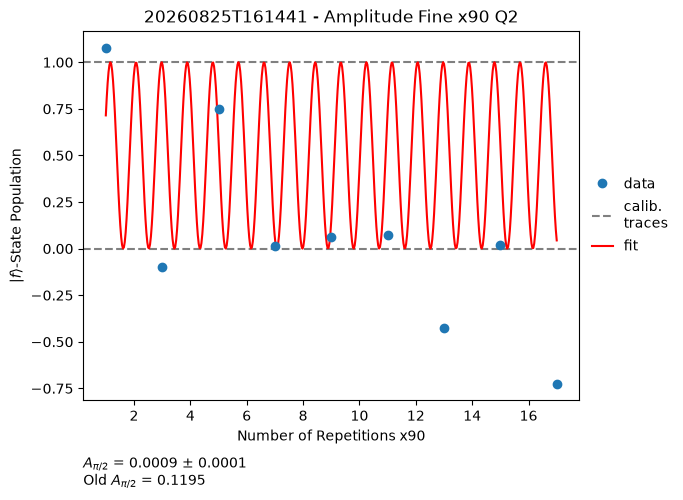

In [99]:
options = amplitude_fine.experiment_workflow_x90.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_fine.experiment_workflow_x90(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    repetitions=[x90_repetitions for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

##### Update Parameters

In [100]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)



if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    
    amplitude_fine.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nDrive amplitude pi2 ge (error-amplified): ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
    elif transition == 'ef':
        print("\nDrive amplitude pi2 ef (error-amplified): ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)
    
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_drive_amplitude_pi2': 0.0009237031489600105+/-7.941138038179512e-05}},
 'old_parameter_values': {'Q2': {'ef_drive_amplitude_pi2': 0.1195299628236887}}}

Drive amplitude pi2 ef (error-amplified):  0.0009237031489600105

Updated global experiment parameters!



### Ramsey

#### Experiment Parameters

In [112]:
update_global_parameters = True

detuning = 0.2e6
transition = set_transition('ef')

n_avg_exponent = 13

delay_min = 0
delay_max = 20e-6
n_delay = 51

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

In [ ]:
options = ramsey.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Ramsey in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
# qubits_to_measure = [qubits[0], qubits[2]]
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]
detunings = [
    detuning
]

exp_workflow = ramsey.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    detunings=detunings,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

[2026.08.25 16:59:37.152] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:59:37.152] INFO      Workflow 'ramsey': execution started at 2026-08-25 13:59:37.152672Z           
[2026.08.25 16:59:37.152] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:59:37.457] INFO    Task 'temporary_qpu': started at 2026-08-25 13:59:37.457803Z
[2026.08.25 16:59:37.516] INFO    Task 'temporary_qpu': ended at 2026-08-25 13:59:37.515823Z
[2026.08.25 16:59:37.601] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 16:59:37.601] INFO    13:59:37.601704Z
[2026.08.25 16:59:37.650] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 13:59:37.650759Z
[2026.08.25 16:59:37.748] INFO    Task 'create_experiment': started at 2026-08-25 13:59:37.748975Z
[2026.08.25 16:59:37.879] INFO    Task 'create_experiment': ended at 2026-08-25 13:59:37.879531Z
[202

#### Update Parameters

In [ ]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)


if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nge_T2_star: ", qubit_to_measure.parameters.ge_T2_star)
        print("resonance_frequency_ge: ", qubit_to_measure.parameters.resonance_frequency_ge)
    elif transition == 'ef':
        print("\nef_T2_star: ", qubit_to_measure.parameters.ef_T2_star)
        print("resonance_frequency_ef: ", qubit_to_measure.parameters.resonance_frequency_ef)
    
    print('\nUpdated global experiment parameters!\n')

### T1 Lifetime

#### Experiment Parameters

In [109]:
update_global_parameters = True

transition = set_transition('ef')

n_avg_exponent = 13

delay_min = 0
delay_max = 50e-6
n_delay = 51
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.08.25 16:57:17.995] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:57:17.995] INFO      Workflow 'lifetime_measurement': execution started at 2026-08-25              
[2026.08.25 16:57:17.995] INFO      13:57:17.995133Z                                                              
[2026.08.25 16:57:17.995] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.08.25 16:57:18.361] INFO    Task 'temporary_qpu': started at 2026-08-25 13:57:18.361068Z
[2026.08.25 16:57:18.395] INFO    Task 'temporary_qpu': ended at 2026-08-25 13:57:18.395283Z
[2026.08.25 16:57:18.492] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-08-25 
[2026.08.25 16:57:18.492] INFO    13:57:18.492341Z
[2026.08.25 16:57:18.570] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-08-25 13:57:18.570114Z
[2026.08.25 16:57:18.679] INFO    Task 'create_experiment': started at 2026-08-25 13:

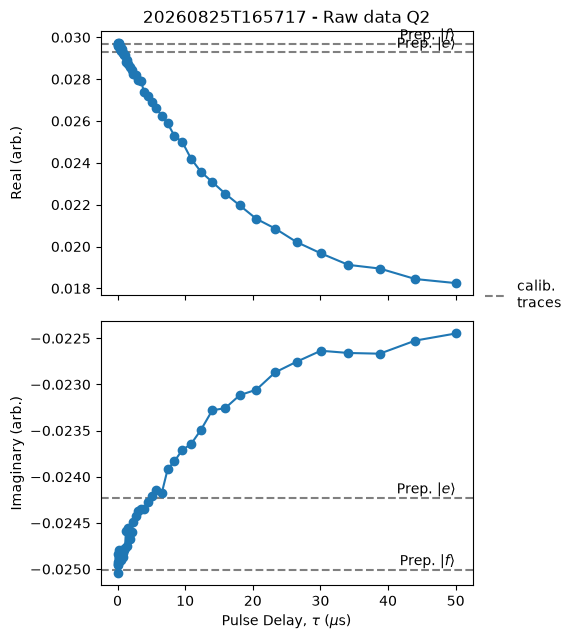

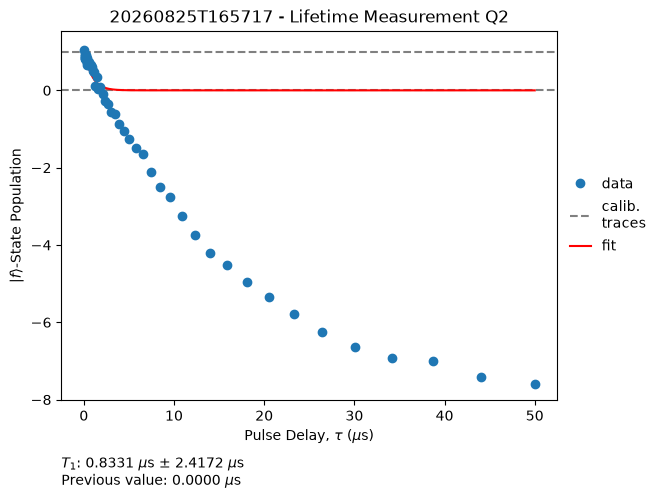

In [110]:
options = lifetime_measurement.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

if log_spacing:
    delays = [log_sweep_help(delay_min, delay_max, n_delay)]
else:
    delays = [np.linspace(delay_min, delay_max, n_delay)]

exp_workflow = lifetime_measurement.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters 
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [111]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    lifetime_measurement.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nge_T1: ", qubit_to_measure.parameters.ge_T1)
    elif transition == 'ef':
        print("\nef_T1: ", qubit_to_measure.parameters.ef_T1)
    
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_T1': 8.331254743577805e-07+/-2.417160185067394e-06}},
 'old_parameter_values': {'Q2': {'ef_T1': 0}}}

ef_T1:  8.331254743577805e-07

Updated global experiment parameters!



### DRAG Calibration

#### Experiment Parameters

In [ ]:
update_global_parameters = True

transition = set_transition('ef')

readout_range_out = -30

n_avg_exponent = 13

q_min = -0.1
q_max = 0.15
n_q = 51

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.readout_range_out = readout_range_out
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

In [ ]:
options = drag_q_scaling.experiment_workflow.options()
# options.update(True)  # updates the qubit parameter 'ge_drive_pulse["beta"]'
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = drag_q_scaling.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    q_scalings=[np.linspace(q_min, q_max, n_q) for _ in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [ ]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)


if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

    drag_q_scaling.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nge_drive_pulse[beta]: ", qubit_to_measure.parameters.ge_drive_pulse["beta"])
    elif transition == 'ef':
        print("\nef_drive_pulse[beta]: ", qubit_to_measure.parameters.ef_drive_pulse["beta"])
    
    print('\nUpdated global experiment parameters!\n')

### Hahn-Echo

#### Experiment Parameters

In [ ]:
update_global_parameters = True

transition = set_transition('ef')

n_avg_exponent = 13

delay_min = 0
delay_max = 70e-6
n_delay = 71
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

In [ ]:
options = echo.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Echo in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]

exp_workflow = echo.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters
)

workflow_result = exp_workflow.run()

#### Update Parameters

In [ ]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)

    echo.update_qpu(qpu, qubit_parameters["new_parameter_values"])
    if transition == 'ge':
        print("\nge_T2: ", qubit_to_measure.parameters.ge_T2)
    elif transition == 'ef':
        print("\nef_T2: ", qubit_to_measure.parameters.ef_T2)
    
    print('\nUpdated global experiment parameters!\n')

In [ ]:
qpu.quantum_elements

# Readout Optimisation

Optimization of the readout pulse amplitude and of the readout (resonator)
frequency.

1. **Readout Amplitude Optimization** — sweep the readout amplitude and run an
   amplitude-Rabi experiment at each amplitude. The readout amplitude with the
   smallest relative Rabi-fit errors gives the best signal-to-noise ratio.
2. **Dispersive Shift** — resonator spectroscopy with the qubit prepared in
   g, e (and f). The optimal readout frequency is the frequency of the largest
   distance between the transmission signals of the different states.
3. **Readout Settings Summary** — write the optimized readout parameters into
   the QPU and save them.

## Readout Amplitude Optimisation

#### Experiment Parameters

In [ ]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 12

# readout setting used during the sweep
readout_range_out = -30
readout_range_in = -40
readout_length = 2e-6
readout_integration_length = 2e-6
readout_integration_delay = 80e-9
reset_delay_length = 300e-6

# length and amplitude are taken from readout_length / readout_amplitude
readout_pulse = {
    'function': 'gaussian_square',
    'width': readout_length * 0.95,
}

# readout amplitude sweep
ro_amp_min = 0.0
ro_amp_max = 1.0
n_ro_amp = 11
ro_amp_arr = np.linspace(ro_amp_min, ro_amp_max, n_ro_amp)

# rabi sweep used to benchmark each readout amplitude
drive_range = 5
amp_min = 0
amp_max = 1
n_amp = 21
drive_amplitudes = np.linspace(amp_min, amp_max, n_amp)

qubit_to_measure = qubits[0]

#### Run Workflow

In [ ]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False) # never update the qubit parameters during the sweep
options.close_figures(True) # one Rabi figure per readout amplitude

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubit_to_measure]

rabi_ro_sweep_results = []
fit_values_ro_sweep = []
fit_errors_ro_sweep = []
# same order as the old popt/pcov of fit_Rabi
fit_parameter_names = ['frequency', 'phase', 'amplitude', 'offset']

for ro_amp in ro_amp_arr:
    print('Measure at readout amplitude:', round(ro_amp, 5))

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.readout_amplitude = round(ro_amp, 5)
    temp_pars.readout_length = readout_length
    temp_pars.readout_pulse = readout_pulse
    temp_pars.readout_integration_length = readout_integration_length
    temp_pars.readout_integration_delay = readout_integration_delay
    temp_pars.readout_range_out = readout_range_out
    temp_pars.readout_range_in = readout_range_in
    temp_pars.reset_delay_length = reset_delay_length
    temp_pars.drive_range = drive_range
    temporary_parameters[qubit_to_measure.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[drive_amplitudes for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()
    rabi_ro_sweep_results.append(workflow_result)

    # rotates/projects the raw data and fits a cosine model to the population
    fit_results = get_analysis_task_output(workflow_result, 'fit_data')
    fit_res = fit_results.get(qubit_to_measure.uid)
    if fit_res is None:
        print(f'  Rabi fit failed at readout amplitude {round(ro_amp, 5)}.')
        fit_values_ro_sweep.append([np.nan] * len(fit_parameter_names))
        fit_errors_ro_sweep.append([np.nan] * len(fit_parameter_names))
        continue

    fit_values_ro_sweep.append([fit_res.params[p].value for p in fit_parameter_names])
    fit_errors_ro_sweep.append([fit_res.params[p].stderr for p in fit_parameter_names])

popt_rabi_arr = np.array(fit_values_ro_sweep, dtype=float)
err_arr = np.array(fit_errors_ro_sweep, dtype=float)

#### Update Parameters

In [ ]:
ll = 1 # skip readout amplitude 0 (no signal)
ul = None
sweep_slice = slice(ll, ul)

# lmfit reports stderr = 0 when the covariance matrix could not be estimated;
# treat those points as invalid instead of "perfect".
err_arr[err_arr == 0] = np.nan
rel_err_arr = np.abs(err_arr / popt_rabi_arr)
fig, ax = plt.subplots(2, 2, sharex=True, figsize=(10, 8))
fig.suptitle(f'Relative errors for Rabi measurements - {qubit_to_measure.uid}', fontsize=16)
fig.supylabel('Relative error (a.u.)')

ax[0, 0].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 0], '.k', label='freq')
ax[1, 0].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 1], '.k', label='phase')
ax[0, 1].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 2], '.k', label='amp')
ax[1, 1].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 3], '.k', label='off')

ax[0, 0].set_title('Frequency')
ax[1, 0].set_title('Phase')
ax[0, 1].set_title('Amplitude')
ax[1, 1].set_title('Offset')

# optimal readout amplitude: smallest mean relative fit error.
mean_rel_err = np.nanmean(rel_err_arr, axis=1)
masked_rel_err = np.full(mean_rel_err.shape, np.nan)
masked_rel_err[sweep_slice] = mean_rel_err[sweep_slice]
optimal_index = int(np.nanargmin(masked_rel_err))
readout_amplitude_opt = float(ro_amp_arr[optimal_index])

for axis in ax.flatten():
    axis.axvline(x=readout_amplitude_opt, ls='-.', color='r', label='optimal')
    axis.legend()

print('Optimal readout amplitude:', round(readout_amplitude_opt, 5))

figname = f'Rabi_optimiz_{readout_range_out}dBm_'
file_path = get_path_to_file(figname, '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
# set to a value != None to override the value extracted above.
manual_readout_amplitude = None
if manual_readout_amplitude is not None:
    readout_amplitude_opt = float(manual_readout_amplitude)

if update_global_parameters:
    temporary_parameters[qubit_to_measure.uid].readout_amplitude = readout_amplitude_opt
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

print('Readout amplitude: ', qubit_to_measure.parameters.readout_amplitude)
print('Readout length: ', qubit_to_measure.parameters.readout_length)
print('Readout pulse: ', qubit_to_measure.parameters.readout_pulse)
print('Readout integration length: ', qubit_to_measure.parameters.readout_integration_length)
print('Readout integration delay: ', qubit_to_measure.parameters.readout_integration_delay)
print('Readout range out / in: ', qubit_to_measure.parameters.readout_range_out,
      '/', qubit_to_measure.parameters.readout_range_in)

In [ ]:
qpu.quantum_elements

## Dispersive Shift

#### Experiment Parameters

In [ ]:
update_global_parameters = True

states = 'gef'

n_avg_exponent = 13

freq_range = 2e6
n_points = 101

# TODO
readout_amplitude = 0.9
readout_range_out = -30
readout_range_in = -35
reset_delay_length = 150e-6

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.readout_amplitude = readout_amplitude
temp_pars.readout_range_out = readout_range_out
temp_pars.readout_range_in = readout_range_in
temp_pars.reset_delay_length = reset_delay_length
temporary_parameters[qubits[0].uid] = temp_pars

#### Run Workflow

In [ ]:
options = dispersive_shift.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False)  # updated explicitly below
options.close_figures(False)

qubit_to_measure = qubits[0]

frequencies = temporary_parameters[
    qubit_to_measure.uid
].readout_resonator_frequency + np.linspace(-freq_range / 2, freq_range / 2, n_points)

exp_workflow = dispersive_shift.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    frequencies=frequencies,
    states=states,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Analysis Plots

In [ ]:
result = workflow_result.output
res_data = {
    state: result[dsl.handles.result_handle(qubit_to_measure.uid, suffix=state)].data
    for state in states
}
res_freq = frequencies

state_labels = {'g': 'ground', 'e': 'first excited', 'f': 'second excited'}
state_colors = {'g': 'b', 'e': 'r', 'f': 'g'}

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
fig.suptitle('Spectroscopy of readout resonator for the qubit states', fontsize=16)
fig.supxlabel('Readout frequency, GHz')

ax[0].set_title('Amplitude')
ax[1].set_title('Phase')

for state, data in res_data.items():
    ax[0].plot(res_freq * 1e-9, np.abs(data), state_colors[state], label=state_labels[state])
    ax[1].plot(res_freq * 1e-9, np.unwrap(np.angle(data)), state_colors[state],
               label=state_labels[state])

for axis, ylabel in zip(ax, ['Amplitude, a.u.', 'Phase, a.u.']):
    axis.axvline(x=qubit_to_measure.parameters.readout_resonator_frequency * 1e-9,
                 label='current readout')
    axis.set_ylabel(ylabel)
    axis.legend()

file_path = get_path_to_file('Readout_spec_for_g_e', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

fig_iq, ax_iq = plt.subplots()
ax_iq.set_title('Spectroscopy of readout resonator: IQ plane')
for state, data in res_data.items():
    ax_iq.plot(data.real, data.imag, state_colors[state], label=state_labels[state])
ax_iq.set_xlabel('Real part, a.u.')
ax_iq.set_ylabel('Imaginary part, a.u.')
ax_iq.legend()

file_path = get_path_to_file('Readout_spec_for_g_e_IQ', '.png')
fig_iq.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
processed_data_dict = get_analysis_task_output(workflow_result, 'calculate_signal_differences')

fig_dist, ax_dist = plt.subplots(figsize=(10, 5))
ax_dist.set_title('Spectroscopy of readout resonator: state distances')
for state_pair, (distance, max_distance, freq_at_max) in processed_data_dict.items():
    ax_dist.plot(res_freq * 1e-9, distance, label=state_pair)
    print(f'{state_pair}: max distance {max_distance:.4g} at '
          f'{freq_at_max * 1e-9:.6f} GHz')

ax_dist.axvline(x=qubit_to_measure.parameters.readout_resonator_frequency * 1e-9,
                ls='--', label='current readout')
ax_dist.axvline(x=processed_data_dict['sum' if 'sum' in processed_data_dict else
                                      next(iter(processed_data_dict))][2] * 1e-9,
                ls='-.', color='k', label='optimal')
ax_dist.set_xlabel('Readout frequency, GHz')
ax_dist.set_ylabel('Signal distance, a.u.')
ax_dist.legend()

file_path = get_path_to_file('Readout_spec_for_g_e_distance', '.png')
fig_dist.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
analysis_workflow_result = workflow_result.tasks['analysis_workflow']
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

readout_resonator_frequency_opt = float(
    qubit_parameters['new_parameter_values'][qubit_to_measure.uid][
        'readout_resonator_frequency'
    ]
)

manual_readout_resonator_frequency = None
if manual_readout_resonator_frequency is not None:
    readout_resonator_frequency_opt = float(manual_readout_resonator_frequency)
    qubit_parameters['new_parameter_values'][qubit_to_measure.uid][
        'readout_resonator_frequency'
    ] = readout_resonator_frequency_opt

print(f'ro freq opt: {readout_resonator_frequency_opt * 1e-9:.6f} GHz')

if update_global_parameters:
    temporary_parameters[qubit_to_measure.uid].readout_resonator_frequency = (
        readout_resonator_frequency_opt
    )
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    dispersive_shift.update_qpu(qpu, qubit_parameters['new_parameter_values'])
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

print('Readout resonator frequency: ',
      qubit_to_measure.parameters.readout_resonator_frequency * 1e-9, ' GHz')

In [ ]:
data_gef_spec = {'freq': res_freq}
for state, data in res_data.items():
    data_gef_spec[f'{state}_res'] = data
    data_gef_spec[f'{state}_freq'] = res_freq
data_gef_spec.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_gef_spec['sample_name'] = sample_name
data_gef_spec['qubit_name'] = qubit_name
data_gef_spec['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('ge_spec_readout_', '.mat')
savemat(file_path, data_gef_spec)
print(f'Saved gef readout spectroscopy to: {file_path}')

In [ ]:
readout_opt = {
    'readout_amplitude': qubit_to_measure.parameters.readout_amplitude,
    'readout_length': qubit_to_measure.parameters.readout_length,
    'readout_pulse': qubit_to_measure.parameters.readout_pulse,
    'readout_integration_length': qubit_to_measure.parameters.readout_integration_length,
    'readout_integration_delay': qubit_to_measure.parameters.readout_integration_delay,
    'readout_integration_kernels_type':
        qubit_to_measure.parameters.readout_integration_kernels_type,
    'readout_resonator_frequency': qubit_to_measure.parameters.readout_resonator_frequency,
    'readout_lo_frequency': qubit_to_measure.parameters.readout_lo_frequency,
    'readout_range_out': qubit_to_measure.parameters.readout_range_out,
    'readout_range_in': qubit_to_measure.parameters.readout_range_in,
    'reset_delay_length': qubit_to_measure.parameters.reset_delay_length,
}
pprint(readout_opt)

In [ ]:
qpu.quantum_elements

# Single Shot 0 and 1 Measurements

Single-shot (unaveraged) readout of the qubit prepared in g, e (and f).

1. **One Single Shot Measurement** — acquire the single shots for each prepared
   state, classify them with a linear discriminant, and quantify the readout
   with the state distance, the relative shot noise and the correct-state
   assignment fidelity.
2. **Single Shot vs. Drive Pulse Length** — repeat the measurement for a range
   of pi-pulse lengths (i.e. Rabi frequencies).
3. **Single Shot vs. Integration Length and Delay** — repeat the measurement
   for a range of integration delays and integration lengths at a fixed
   readout pulse.
4. **Single Shot vs. Readout Amplitude and Length** — repeat the measurement
   for a range of readout amplitudes and readout lengths.

The readout parameters optimized in `# Readout Optimization` are the starting
point here; the best settings found below are written back into the QPU.

## One Single Shot Measurement

#### Experiment Parameters

In [ ]:
update_global_parameters = True

states = 'gef'

n_avg_exponent = 17

# TODO
# readout settings for the single shots
readout_length = 2e-6
readout_integration_length = 2e-6
readout_amplitude = 0.2
readout_integration_delay = 80e-9
readout_range_out = -30
readout_range_in = -40
# use a long value only if you want to see the thermal population;
# 500e-3 makes 2**17 shots per state extremely slow
reset_delay_length = 300e-6

# length and amplitude come from readout_length / readout_amplitude.
readout_pulse = {
    'function': 'const',
}

qubit_to_measure = qubits[0]

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.readout_amplitude = readout_amplitude
temp_pars.readout_length = readout_length
temp_pars.readout_pulse = readout_pulse
temp_pars.readout_integration_length = readout_integration_length
temp_pars.readout_integration_delay = readout_integration_delay
temp_pars.readout_range_out = readout_range_out
temp_pars.readout_range_in = readout_range_in
temp_pars.reset_delay_length = reset_delay_length
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('Readout length:             ', temp_pars.readout_length)
print('Readout integration length: ', temp_pars.readout_integration_length)
print('Readout integration delay:  ', temp_pars.readout_integration_delay)
print('Readout amplitude:          ', temp_pars.readout_amplitude)
print('Reset delay length:         ', temp_pars.reset_delay_length)
print('Readout resonator frequency:', temp_pars.readout_resonator_frequency)
print('Number of shots per state:  ', 2**n_avg_exponent)

#### Run Workflow

In [ ]:
options = iq_blobs.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)
# the analysis classifies the shots with sklearn LinearDiscriminantAnalysis,
# replacing the manual LDA/PCA cells of the old notebook.
options.do_analysis(True)

exp_workflow = iq_blobs.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[qubit_to_measure.uid],
    states=states,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Analysis Plots

In [ ]:
result = workflow_result.output
shots_per_state = collect_shots_from_result(result, qubit_to_measure.uid, states)

# convenience aliases matching the old variable names
zero_data = shots_per_state['g']
one_data = shots_per_state['e']
two_data = shots_per_state.get('f')

shots_arr = np.array([shots_per_state[s] for s in states])
print('Shots array shape (states, shots):', shots_arr.shape)

state_labels = {'g': 'ground', 'e': 'first excited', 'f': 'second excited'}
state_colors = {'g': 'b', 'e': 'r', 'f': 'y'}
state_alphas = {'g': 0.1, 'e': 0.1, 'f': 0.01}

In [ ]:
# plot measurement data on IQ, plus the state means
fig, ax = plt.subplots()
ax.set_title(f'Single shots on the IQ plane - {qubit_to_measure.uid}')
for s in states:
    data = shots_per_state[s]
    ax.plot(data.real, data.imag, '.', color=state_colors[s],
            alpha=state_alphas[s], label=state_labels[s])
for s in states:
    data = shots_per_state[s]
    ax.plot(np.mean(data.real), np.mean(data.imag), 'o',
            mfc=state_colors[s], mec='k')
ax.set_xlabel('Real part, a.u.')
ax.set_ylabel('Imaginary part, a.u.')
ax.legend()

# plt.xlim(-0.1, 0.12); plt.ylim(-0.25, 0.05) - set manually if needed
# ax.set_xlim(-0.1, 0.12)
# ax.set_ylim(-0.25, 0.05)

figname = 'Single_shot_points_'
file_path = get_path_to_file(figname, '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
# analize_Single_Shots(SS_results, plot=True)
res_ss = analyze_single_shots(shots_per_state, state_0='g', state_1='e', plot=True)

# assignment matrix / fidelity are new: they come from the iq_blobs analysis
assignment_fidelities = workflow_result.tasks['analysis_workflow'].output
assignment_matrices = get_analysis_task_output(
    workflow_result, 'calculate_assignment_matrices'
)
assignment_fidelity = assignment_fidelities.get(qubit_to_measure.uid)

summarize_single_shot_metrics(res_ss, assignment_fidelity)
pprint({k: v for k, v in res_ss.items()
        if not isinstance(v, np.ndarray) and k != 'figure'})

In [ ]:
# plot the raw (unrotated) distributions
n_bins = 50

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)
fig.suptitle(f'Single-shot distributions - {qubit_to_measure.uid}')

axs[0].set_title('Real')
axs[1].set_title('Imag')
for s in states:
    data = shots_per_state[s]
    axs[0].hist(data.real, bins=n_bins, alpha=0.5, label=state_labels[s])
    axs[1].hist(data.imag, bins=n_bins, alpha=0.5, label=state_labels[s])
axs[0].legend()
axs[1].legend()

figname = 'Single_shot_hist_'
file_path = get_path_to_file(figname, '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
# relative-distance histogram of the projected shots
zero_data_proj = res_ss['shots_0_proj']
one_data_proj = res_ss['shots_1_proj']
r = res_ss['distance']

n_bins = 200

fig, ax = plt.subplots()
ax.set_title(f'Projected single shots - {qubit_to_measure.uid}')
ax.hist(zero_data_proj / r, bins=n_bins, alpha=0.5, label=state_labels['g'])
ax.hist(one_data_proj / r, bins=n_bins, alpha=0.5, label=state_labels['e'])
ax.axvline(1, color='k', ls='--')
ax.axvline(-1, color='k', ls='--')
ax.set_yscale('log')
ax.set_ylabel('N points')
ax.set_xlabel('Relative distance')
ax.legend()

In [ ]:
# single Gaussian fit of the projected state-0 shots
data = zero_data_proj / r

fig, ax = plt.subplots()
n, bins, patches = ax.hist(data, bins=n_bins, alpha=0.5, density=True)

(mu, sigma) = norm.fit(data)

# add a 'best fit' line
y = norm.pdf(bins, mu, sigma)
ax.plot(bins, y, 'r--', linewidth=2)
ax.set_yscale('log')
ax.set_ylabel('Probability density')
ax.set_xlabel('Relative distance')
ax.set_title(f'Gaussian fit state 0: mu = {mu:.4f}, sigma = {sigma:.4f}')
print('mu:', mu, ' sigma:', sigma)

In [ ]:
# bimodal fit of the projected state-1 shots -> residual ground pop.
data = one_data_proj / r

fig, ax = plt.subplots()
y, x, patches = ax.hist(data, bins=n_bins, color='red', alpha=0.25)
x = (x[1:] + x[:-1]) / 2

expected = (-1, .2, 1050, 1, .2, 125)
params, cov = curve_fit(bimodal, x, y, expected)
sigma = np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
# plot combined...
ax.plot(x_fit, bimodal(x_fit, *params), color='green', lw=3, label='One+Zero')
# ...and individual Gauss curves
ax.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=2, ls='--', label='One')
ax.plot(x_fit, gauss(x_fit, *params[3:]), color='b', lw=2, ls=':', label='Zero')
ax.set_yscale('log')
ax.set_ylabel('N points')
ax.set_xlabel('Relative distance')
ax.set_ylim(1e-1, 5e3)
ax.set_title(f'Bimodal fit state 1 - {qubit_to_measure.uid}')
ax.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma},
                   index=bimodal.__code__.co_varnames[1:]))
plt.show()

print('Area ratio:', params[4] * params[5] / (params[1] * params[2]))

In [ ]:
# bimodal fit of the projected state-0 shots -> residual excited pop.
data = zero_data_proj / r

fig, ax = plt.subplots()
y, x, patches = ax.hist(data, bins=n_bins, color='blue', alpha=0.25)
x = (x[1:] + x[:-1]) / 2

expected = (-1.5, 1.0, 250, 1, 1.0, 2025)
params, cov = curve_fit(bimodal, x, y, expected)
sigma = np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
# plot combined...
ax.plot(x_fit, bimodal(x_fit, *params), color='green', lw=3, label='One+Zero')
# ...and individual Gauss curves
ax.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=2, ls='--', label='One')
ax.plot(x_fit, gauss(x_fit, *params[3:]), color='blue', lw=2, ls=':', label='Zero')
ax.set_yscale('log')
ax.set_ylabel('N points')
ax.set_xlabel('Relative distance')
ax.set_ylim(1e-1, 5e3)
ax.set_title(f'Bimodal fit state 0 - {qubit_to_measure.uid}')
ax.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma},
                   index=bimodal.__code__.co_varnames[1:]))
plt.show()

print('Area ratio:', params[1] * params[2] / (params[4] * params[5]))

In [ ]:
# 2D histogram of the shots
n_bins = 50

fig, ax = plt.subplots(tight_layout=True)
ax.set_title(f'Single-shot density - {qubit_to_measure.uid}')
ax.hist2d(zero_data.real, zero_data.imag, n_bins)
ax.hist2d(one_data.real, one_data.imag, n_bins)
ax.set_xlabel('Real part, a.u.')
ax.set_ylabel('Imaginary part, a.u.')

In [ ]:
# the assignment matrix produced by the iq_blobs analysis replaces the manual
# LinearDiscriminantAnalysis / compute_pca cells.
if qubit_to_measure.uid in assignment_matrices:
    print('Correct-state-assignment matrix:')
    print(np.round(assignment_matrices[qubit_to_measure.uid], 4))
    print('Assignment fidelity:', f'{assignment_fidelity * 100:0.2f} %')

#### Update Parameters

In [ ]:
# Data_SS = {...}; Data_SS.update(qubit_parameters._params);
# savemat(get_path_to_file('Single_shots_all_unsh_', '.mat'), Data_SS)
data_ss = {f'shots_{s}': shots_per_state[s] for s in states}
data_ss['states'] = list(states)
data_ss['shot_index'] = np.arange(shots_arr.shape[-1])
data_ss['n_shots'] = 2**n_avg_exponent
data_ss.update({k: v for k, v in res_ss.items()
                if isinstance(v, (int, float, complex))})
if qubit_to_measure.uid in assignment_matrices:
    data_ss['assignment_matrix'] = assignment_matrices[qubit_to_measure.uid]
    data_ss['assignment_fidelity'] = assignment_fidelity

data_ss.update(
    {k: v for k, v in attrs.asdict(temporary_parameters[qubit_to_measure.uid]).items()
     if isinstance(v, (int, float, str))}
)
data_ss['sample_name'] = sample_name
data_ss['qubit_name'] = qubit_name
data_ss['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Single_shots_all_unsh_', '.mat')
savemat(file_path, data_ss)
print(f'Saved single shots to: {file_path}')

In [ ]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('Readout amplitude: ', qubit_to_measure.parameters.readout_amplitude)
print('Readout length: ', qubit_to_measure.parameters.readout_length)
print('Readout integration length: ',
      qubit_to_measure.parameters.readout_integration_length)
print('Readout integration delay: ',
      qubit_to_measure.parameters.readout_integration_delay)
print('Reset delay length: ', qubit_to_measure.parameters.reset_delay_length)

In [ ]:
qpu.quantum_elements

## Single Shot Measurement for Different Rabi Frequencies

#### Experiment Parameters

In [ ]:
update_global_parameters = True

n_avg_exponent = 15  # reduce: this is a sweep over 36 pi-pulse lengths

states = 'ge'

drive_length_arr = np.linspace(60e-9, 400e-9, 36)
rabi_freq_arr = 1 / drive_length_arr

ge_drive_pulse = {
    'function': 'gaussian',
    'sigma': 0.25,
}

# The old notebook extrapolated the pi amplitude from a linear
# rabi_slope / rabi_intercept calibration. With the workflow structure the pi
# amplitude for the *current* drive length is a qubit parameter, so scale it
# instead of re-deriving it (or set `ge_drive_amplitude_pi_arr` manually).
rabi_slope = qubit_to_measure.parameters.ge_drive_amplitude_pi * \
    qubit_to_measure.parameters.ge_drive_length
ge_drive_amplitude_pi_arr = np.clip(rabi_slope / drive_length_arr, 0.0, 1.0)

print(pd.DataFrame({
    'ge_drive_length': drive_length_arr,
    'rabi_freq_MHz': rabi_freq_arr * 1e-6,
    'ge_drive_amplitude_pi': ge_drive_amplitude_pi_arr,
}))

qubit_to_measure = qubits[0]

#### Run Workflow

In [ ]:
options = iq_blobs.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)  # one IQ-blob figure per drive length
options.do_analysis(True)

ss_drive_length_sweep_shots = []
ss_drive_length_sweep_metrics = []
ss_drive_length_sweep_fidelities = []

for drive_length, drive_amplitude_pi in zip(drive_length_arr,
                                            ge_drive_amplitude_pi_arr):
    print('Drive length:', round(drive_length * 1e9, 3), 'ns',
          '| pi amplitude:', round(float(drive_amplitude_pi), 5))

    temporary_parameters = {}
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.ge_drive_length = float(drive_length)
    temp_pars.ge_drive_amplitude_pi = float(drive_amplitude_pi)
    # temp_pars.ge_drive_pulse = ge_drive_pulse
    temporary_parameters[qubit_to_measure.uid] = temp_pars

    exp_workflow = iq_blobs.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[qubit_to_measure.uid],
        states=states,
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()

    shots = collect_shots_from_result(
        workflow_result.output, qubit_to_measure.uid, states
    )
    ss_drive_length_sweep_shots.append(np.array([shots[s] for s in states]))

    res = analyze_single_shots(shots, state_0='g', state_1='e', plot=False)
    ss_drive_length_sweep_metrics.append(
        {k: v for k, v in res.items() if isinstance(v, (int, float, complex))}
    )
    ss_drive_length_sweep_fidelities.append(
        workflow_result.tasks['analysis_workflow'].output.get(
            qubit_to_measure.uid, np.nan
        )
    )

ss_drive_length_sweep_arr = np.array(ss_drive_length_sweep_shots)
print('Sweep array shape (drive lengths, states, shots):',
      ss_drive_length_sweep_arr.shape)

#### Analysis Plots

In [ ]:
rel_std_0_arr = np.array([m['rel_std_0'] for m in ss_drive_length_sweep_metrics])
fidelity_arr = np.array(ss_drive_length_sweep_fidelities, dtype=float)

optimal_index = int(np.nanargmin(rel_std_0_arr))
print('Best drive length:', round(drive_length_arr[optimal_index] * 1e9, 3), 'ns',
      '| Rabi frequency:', round(rabi_freq_arr[optimal_index] * 1e-6, 3), 'MHz',
      '| rel_std_0:', round(float(rel_std_0_arr[optimal_index]), 4))

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
fig.suptitle(f'Single shot vs. Rabi frequency - {qubit_to_measure.uid}', fontsize=16)
fig.supxlabel('Rabi frequency, MHz')

ax[0].plot(rabi_freq_arr * 1e-6, rel_std_0_arr, '.k')
ax[0].set_ylabel('Relative STD state 0')
ax[0].set_yscale('log')

ax[1].plot(rabi_freq_arr * 1e-6, fidelity_arr * 100, '.k')
ax[1].set_ylabel('Assignment fidelity, %')

for axis in ax:
    axis.axvline(x=rabi_freq_arr[optimal_index] * 1e-6, ls='-.', color='r',
                 label='optimal')
    axis.legend()

file_path = get_path_to_file('Single_shots_vs_rabi_freq_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
data_ss = {
    'ss_drive_length_sweep_arr': ss_drive_length_sweep_arr,
    'states': list(states),
    'ge_drive_length': drive_length_arr,
    'rabi_freq': rabi_freq_arr,
    'ge_drive_amplitude_pi': ge_drive_amplitude_pi_arr,
    'rel_std_0': rel_std_0_arr,
    'assignment_fidelity': fidelity_arr,
    'n_shots': 2**n_avg_exponent,
    'comment': 'Sweep of the pi-pulse length, array dim [drive_length, state, shot]',
}
data_ss.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_ss['sample_name'] = sample_name
data_ss['qubit_name'] = qubit_name
data_ss['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Single_shots_0_pi_diff_pipulses_', '.mat')
savemat(file_path, data_ss)
print(f'Saved drive-length sweep to: {file_path}')

In [ ]:
if update_global_parameters:
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.ge_drive_length = float(drive_length_arr[optimal_index])
    temp_pars.ge_drive_amplitude_pi = float(ge_drive_amplitude_pi_arr[optimal_index])
    # temp_pars.ge_drive_pulse = ge_drive_pulse
    qubit_to_measure.parameters = temp_pars
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('ge drive length: ', qubit_to_measure.parameters.ge_drive_length)
print('ge drive amplitude pi: ', qubit_to_measure.parameters.ge_drive_amplitude_pi)

In [ ]:
qpu.quantum_elements

## Single Shot Measurement for Different Integration Lengths and Delays

#### Experiment Parameters

In [ ]:
update_global_parameters = True

n_avg_exponent = 15

states = 'ge'

print('Readout length:            ', qubit_to_measure.parameters.readout_length)
print('Readout integration length:',
      qubit_to_measure.parameters.readout_integration_length)
print('Readout integration delay: ',
      qubit_to_measure.parameters.readout_integration_delay)

# TODO
# Here the readout pulse amplitude and length are fixed and we vary the
# integration delay and integration (weighting) length.
readout_length = qubit_to_measure.parameters.readout_length
readout_integration_delay_arr = np.linspace(60, 100, 5) * 1e-9
readout_integration_length_arr = np.array([readout_length])
# to sweep the integration length as well (old commented-out line
# `ro_len = np.arange(100, 2100 - port_delay_sw[k], 100)*1e-9`):
# readout_integration_length_arr = np.arange(100, 2100, 200) * 1e-9

qubit_to_measure = qubits[0]

#### Run Workflow

In [ ]:
options = iq_blobs.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)
options.do_analysis(False)  # only the projected statistics are needed here

ss_delay_sweep_metrics = []
ss_delay_sweep_shots = []

for integration_delay in readout_integration_delay_arr:
    print('Integration delay:', round(integration_delay * 1e9, 3), 'ns')

    metrics_inner = []
    shots_inner = []

    for integration_length in readout_integration_length_arr:
        print('  Integration length:', round(integration_length * 1e9, 3), 'ns')

        temporary_parameters = {}
        temp_pars = deepcopy(qubit_to_measure.parameters)
        temp_pars.readout_length = readout_length
        temp_pars.readout_integration_delay = float(integration_delay)
        temp_pars.readout_integration_length = float(integration_length)
        temporary_parameters[qubit_to_measure.uid] = temp_pars

        exp_workflow = iq_blobs.experiment_workflow(
            session=session,
            qpu=qpu,
            qubits=[qubit_to_measure.uid],
            states=states,
            options=options,
            temporary_parameters=temporary_parameters,
        )
        workflow_result = exp_workflow.run()

        shots = collect_shots_from_result(
            workflow_result.output, qubit_to_measure.uid, states
        )
        shots_inner.append(np.array([shots[s] for s in states]))

        res = analyze_single_shots(shots, state_0='g', state_1='e', plot=False)
        metrics_inner.append(
            {k: v for k, v in res.items() if isinstance(v, (int, float, complex))}
        )

    ss_delay_sweep_metrics.append(metrics_inner)
    ss_delay_sweep_shots.append(shots_inner)

ss_delay_sweep_arr = np.array(ss_delay_sweep_shots)
print('Sweep array shape (delays, integration lengths, states, shots):',
      ss_delay_sweep_arr.shape)

#### Analysis Plots

In [ ]:
# min / argmin of Rel_STD_0 over the nested sweep
min_val = []
argmin_val = []

for metrics_inner in ss_delay_sweep_metrics:
    rel_std_0 = np.array([m['rel_std_0'] for m in metrics_inner])
    min_val.append(np.nanmin(rel_std_0))
    argmin_val.append(int(np.nanargmin(rel_std_0)))

optimal_delay_index = int(np.nanargmin(np.array(min_val)))
optimal_length_index = argmin_val[optimal_delay_index]

readout_integration_delay_opt = float(
    readout_integration_delay_arr[optimal_delay_index]
)
readout_integration_length_opt = float(
    readout_integration_length_arr[optimal_length_index]
)

print('Readout length is', readout_length)
print('Minimal relative error value is', np.round(min_val[optimal_delay_index], 3),
      'for delay', np.round(readout_integration_delay_opt * 1e9, 3),
      'ns (index', optimal_delay_index, ') and integration length',
      readout_integration_length_opt, '(index', optimal_length_index, ').')
if 0 < optimal_delay_index < len(readout_integration_delay_arr) - 1:
    print('Optimal integration delay is between',
          np.round(readout_integration_delay_arr[optimal_delay_index - 1] * 1e9, 3),
          'and',
          np.round(readout_integration_delay_arr[optimal_delay_index + 1] * 1e9, 3),
          'ns')

rel_std_0_arr = np.array(
    [[m['rel_std_0'] for m in metrics_inner]
     for metrics_inner in ss_delay_sweep_metrics]
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title(f'Single shot vs. integration delay - {qubit_to_measure.uid}')
for k, integration_length in enumerate(readout_integration_length_arr):
    ax.plot(readout_integration_delay_arr * 1e9, rel_std_0_arr[:, k], '.-',
            label=f'{integration_length * 1e9:.0f} ns')
ax.axvline(x=readout_integration_delay_opt * 1e9, ls='-.', color='r', label='optimal')
ax.set_xlabel('Readout integration delay, ns')
ax.set_ylabel('Relative STD state 0')
ax.set_yscale('log')
ax.legend(title='Integration length')

file_path = get_path_to_file('Single_shots_vs_delay_and_int_len_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
# set to a value != None to override the values extracted above.
manual_readout_integration_delay = None
manual_readout_integration_length = None
if manual_readout_integration_delay is not None:
    readout_integration_delay_opt = float(manual_readout_integration_delay)
if manual_readout_integration_length is not None:
    readout_integration_length_opt = float(manual_readout_integration_length)

if update_global_parameters:
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.readout_integration_delay = readout_integration_delay_opt
    temp_pars.readout_integration_length = readout_integration_length_opt
    qubit_to_measure.parameters = temp_pars
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('Readout integration delay: ',
      qubit_to_measure.parameters.readout_integration_delay)
print('Readout integration length: ',
      qubit_to_measure.parameters.readout_integration_length)

In [ ]:
data_ss = {
    'ss_delay_sweep_arr': ss_delay_sweep_arr,
    'states': list(states),
    'readout_integration_delay_sweep': readout_integration_delay_arr,
    'readout_integration_length_sweep': readout_integration_length_arr,
    'readout_length': readout_length,
    'rel_std_0': rel_std_0_arr,
    'n_shots': 2**n_avg_exponent,
    'comment': ('Sweep integration delay and integration length, array dim '
                '[delay, integration_length, state, shot]'),
}
data_ss.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_ss['sample_name'] = sample_name
data_ss['qubit_name'] = qubit_name
data_ss['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Single_shots_0_pi_sweep_delay_and_ro_len_', '.mat')
savemat(file_path, data_ss)
print(f'Saved delay/integration-length sweep to: {file_path}')

In [ ]:
qpu.quantum_elements

## Single Shot Measurement for Different Readout Amplitudes and Lengths

#### Experiment Parameters

In [ ]:
update_global_parameters = True

n_avg_exponent = 14

states = 'ge'

# TODO
# Sweep power and length of the readout pulse. The integration delay is fixed
# and the integration window is equal to the readout pulse length.
readout_amplitude_arr = np.linspace(0.05, 1, 29)
readout_length_arr = np.linspace(1900, 2000, 10) * 1e-9

readout_integration_delay = qubit_to_measure.parameters.readout_integration_delay

qubit_to_measure = qubits[0]

#### Run Workflow

In [ ]:
options = iq_blobs.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)
options.do_analysis(False)

ss_ro_sweep_metrics = []

for readout_amplitude in readout_amplitude_arr:
    print('Readout amplitude:', round(float(readout_amplitude), 5))

    metrics_inner = []

    for readout_length in readout_length_arr:
        print('  Readout length:', round(readout_length * 1e9, 3), 'ns')

        temporary_parameters = {}
        temp_pars = deepcopy(qubit_to_measure.parameters)
        temp_pars.readout_amplitude = float(readout_amplitude)
        temp_pars.readout_length = float(readout_length)
        # old: readout_weighting_function_i = pulse_library.const(length=ro_len_sw[i])
        temp_pars.readout_integration_length = float(readout_length)
        temp_pars.readout_integration_delay = readout_integration_delay
        temporary_parameters[qubit_to_measure.uid] = temp_pars

        exp_workflow = iq_blobs.experiment_workflow(
            session=session,
            qpu=qpu,
            qubits=[qubit_to_measure.uid],
            states=states,
            options=options,
            temporary_parameters=temporary_parameters,
        )
        workflow_result = exp_workflow.run()

        shots = collect_shots_from_result(
            workflow_result.output, qubit_to_measure.uid, states
        )
        res = analyze_single_shots(shots, state_0='g', state_1='e', plot=False)
        metrics_inner.append(
            {k: v for k, v in res.items() if isinstance(v, (int, float, complex))}
        )

    ss_ro_sweep_metrics.append(metrics_inner)

#### Analysis Plots

In [ ]:
# min / argmin of Rel_STD_0 and the Rel_STD_0 vs. amplitude plot
rel_std_0_arr = np.array(
    [[m['rel_std_0'] for m in metrics_inner] for metrics_inner in ss_ro_sweep_metrics]
)

optimal_amp_index = int(np.nanargmin(np.nanmin(rel_std_0_arr, axis=1)))
optimal_len_index = int(np.nanargmin(rel_std_0_arr[optimal_amp_index, :]))

readout_amplitude_opt = float(readout_amplitude_arr[optimal_amp_index])
readout_length_opt = float(readout_length_arr[optimal_len_index])

print('Minimal relative error value is',
      np.round(rel_std_0_arr[optimal_amp_index, optimal_len_index], 3),
      'for amplitude', np.round(readout_amplitude_opt, 3),
      '(index', optimal_amp_index, ') and length', readout_length_opt,
      '(index', optimal_len_index, ').')

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title(f'Single shot vs. readout amplitude - {qubit_to_measure.uid}')
for k, readout_length in enumerate(readout_length_arr):
    ax.plot(readout_amplitude_arr, rel_std_0_arr[:, k], '.-',
            label=f'{readout_length * 1e9:.0f} ns')
ax.axvline(x=readout_amplitude_opt, ls='-.', color='r', label='optimal')
ax.set_xlabel('Readout amplitude, a.u.')
ax.set_ylabel('Relative STD state 0')
ax.set_yscale('log')
ax.legend(title='Readout length', ncol=2)

file_path = get_path_to_file('Single_shots_vs_ro_amp_and_ro_len_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title(f'Relative STD state 0 - {qubit_to_measure.uid}')
im = ax.pcolormesh(readout_length_arr * 1e9, readout_amplitude_arr, rel_std_0_arr,
                   shading='nearest')
cb = fig.colorbar(im)
cb.set_label('Relative STD state 0')
ax.plot(readout_length_opt * 1e9, readout_amplitude_opt, 'rx', ms=12, label='optimal')
ax.set_xlabel('Readout length, ns')
ax.set_ylabel('Readout amplitude, a.u.')
ax.legend()

file_path = get_path_to_file('Single_shots_ro_amp_ro_len_map_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
# set to a value != None to override the values extracted above.
manual_readout_amplitude = None
manual_readout_length = None
if manual_readout_amplitude is not None:
    readout_amplitude_opt = float(manual_readout_amplitude)
if manual_readout_length is not None:
    readout_length_opt = float(manual_readout_length)

if update_global_parameters:
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.readout_amplitude = readout_amplitude_opt
    temp_pars.readout_length = readout_length_opt
    temp_pars.readout_integration_length = readout_length_opt
    qubit_to_measure.parameters = temp_pars
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('Readout amplitude: ', qubit_to_measure.parameters.readout_amplitude)
print('Readout length: ', qubit_to_measure.parameters.readout_length)
print('Readout integration length: ',
      qubit_to_measure.parameters.readout_integration_length)

In [ ]:
data_ss = {
    'states': list(states),
    'readout_amplitude_sweep': readout_amplitude_arr,
    'readout_length_sweep': readout_length_arr,
    'readout_integration_delay': readout_integration_delay,
    'rel_std_0': rel_std_0_arr,
    'n_shots': 2**n_avg_exponent,
    'comment': ('Sweep readout amplitude and readout length, array dim '
                '[readout_amplitude, readout_length]'),
}
data_ss.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_ss['sample_name'] = sample_name
data_ss['qubit_name'] = qubit_name
data_ss['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Single_shots_0_pi_sweep_ro_amp_and_ro_len_', '.mat')
savemat(file_path, data_ss)
print(f'Saved readout amplitude/length sweep to: {file_path}')

In [ ]:
readout_opt = {
    'readout_amplitude': qubit_to_measure.parameters.readout_amplitude,
    'readout_length': qubit_to_measure.parameters.readout_length,
    'readout_pulse': qubit_to_measure.parameters.readout_pulse,
    'readout_integration_length': qubit_to_measure.parameters.readout_integration_length,
    'readout_integration_delay': qubit_to_measure.parameters.readout_integration_delay,
    'readout_integration_kernels_type':
        qubit_to_measure.parameters.readout_integration_kernels_type,
    'readout_resonator_frequency': qubit_to_measure.parameters.readout_resonator_frequency,
    'readout_lo_frequency': qubit_to_measure.parameters.readout_lo_frequency,
    'readout_range_out': qubit_to_measure.parameters.readout_range_out,
    'readout_range_in': qubit_to_measure.parameters.readout_range_in,
    'reset_delay_length': qubit_to_measure.parameters.reset_delay_length,
}
pprint(readout_opt)

In [ ]:
qpu.quantum_elements

# Population Measurements

Effective-temperature measurements of the qubit.

1. **Rabi Population Measurements (RPM)** — compare the ef-Rabi amplitude with
   and without a ge pre-pulse. The ratio of the two oscillation amplitudes
   gives the residual excited-state population `p_e` and thus the effective
   temperature. The ef pi-pulse used for the fast (two-point) version is
   calibrated in `### Setup`.
2. **Three Level Population Measurements** — the six-sequence protocol
   (`x0`, `x1`, `x2`, `y0`, `y1`, `y2`) that yields the nine `A`/`B`/`C`
   estimators of `p_e/p_g` and the corresponding temperatures `TA1 ... TC3`,
   including the repeated (statistics) version, the projection-phase
   optimization and a variant with a ge pre-pulse of swept amplitude.
3. **Population Measurements for Different Readout Frequencies** — the same
   six-sequence protocol repeated for a range of readout resonator
   frequencies (slow!).

The readout parameters optimized in `# Readout Optimization` and
`# Single Shot 0 and 1 Measurements` are the starting point here.

`laboneq_applications` has no population experiment, so the experiments and
workflows are defined in `## Custom Experiment Workflows` below.

## Helpers

#### Additional Imports

In [ ]:
# Needed by the custom population workflows.
from laboneq.workflow.tasks import compile_experiment, run_experiment

from laboneq_applications.core import validation
from laboneq_applications.experiments.options import BaseExperimentOptions
from laboneq_applications.tasks.parameter_updating import (
    temporary_qpu,
    temporary_quantum_elements_from_qpu,
)

from scipy.optimize import fsolve

#### Fit Helpers

In [ ]:
# Old `lib.helpers.fitting_helper.func_osc` / `fit_Rabi` / `normalize_1d_osc`.DS_Store
def func_osc(x, freq, phase, amp=1, off=0):
    """Old `lib.helpers.fitting_helper.func_osc`, unchanged."""
    return amp * np.cos(freq * x + phase) + off


def fit_rabi_osc(x, y, freq, phase, amp=None, off=None, plot=False, bounds=None):
    """New-structure replacement for the old `fit_Rabi`.

    Same maths (scipy `curve_fit` of `func_osc`), snake_case name. The RPM
    section fits the *raw* magnitude/phase traces, so this stays a manual fit
    instead of the lmfit result of an `analysis_workflow`.
    """
    p0 = [freq, phase]
    if amp is not None:
        p0.append(amp)
        if off is not None:
            p0.append(off)

    kwargs = {} if bounds is None else {'bounds': bounds}
    popt, pcov = curve_fit(func_osc, x, y, p0=p0, **kwargs)

    if plot:
        plt.plot(x, y, '.k')
        plt.plot(x, func_osc(x, *popt), '-r')
        plt.xlabel('Amplitude, a.u.')
        plt.ylabel('Signal, a.u.')
        plt.show()

    return popt, pcov


def normalize_1d_osc(osc, offset=None, norm=None):
    """Old `lib.helpers.fitting_helper.normalize_1d_osc`, unchanged."""
    if offset is None:
        offset = np.mean(osc)
    if norm is None:
        norm = 1 / np.abs(osc.max() - osc.min())

    return 2 * (osc - offset) * norm, offset, norm


def qrpm_dict_from_results(results):
    """New-structure replacement for `get_qrpm_dict_from_list_of_results`.

    Takes a list of `rpm_res` dicts (as built in `#### Analysis Plots` of
    `### Population Measurement`) and flattens them into one dict of arrays,
    with the same keys as the old helper.
    """
    keys = ['I_max', 'I_min', 'Q_max', 'Q_min',
            'mag_max', 'mag_min', 'pha_max', 'pha_min']
    out = {}
    for key in keys:
        for pre_pulse in ['with', 'wo']:
            out[f'{key}_{pre_pulse}'] = np.array(
                [np.mean(res[pre_pulse][key]) for res in results]
            )
    return out

#### Temperature Helpers

In [ ]:
# Old `lib.helpers.pop_temp_helper_v2`: populations -> pe/pg -> temperature.
# The six population labels of the three-level protocol.
pop_label_list = ['x0', 'x1', 'x2', 'y0', 'y1', 'y2']


def T_calc(C, f_q):
    """Old `T_calc`, unchanged: pe/pg (= C) and f_q in GHz -> temperature in K."""
    h = 6.628e-2
    k = 1.381
    return -(h * f_q / k) / np.log(C)


def A_temp(T, A, f_q, anharm):
    """Old `A_temp`, unchanged. `f_q` and `anharm` in GHz."""
    h = 6.628e-2
    k = 1.381
    f_g2 = 2 * f_q - anharm
    num = 1 - np.exp(-h * f_q / k / T)
    denum = 1 - np.exp(-h * f_g2 / k / T)
    return A - num / denum


def B_temp(T, B, f_q, anharm):
    """Old `B_temp`, unchanged."""
    h = 6.628e-2
    k = 1.381
    f_g2 = 2 * f_q - anharm
    num = np.exp(-h * f_q / k / T) - np.exp(-h * f_g2 / k / T)
    denum = 1 - np.exp(-h * f_q / k / T)
    return B - num / denum


def C_temp(T, C, f_q, anharm):
    """Old `C_temp`, unchanged."""
    h = 6.628e-2
    k = 1.381
    f_g2 = 2 * f_q - anharm
    num = np.exp(-h * f_q / k / T) - np.exp(-h * f_g2 / k / T)
    denum = 1 - np.exp(-h * f_g2 / k / T)
    return C - num / denum


def get_qubit_temperature_parameters(qubit):
    """`f_q` and `anharm` (both in GHz) of the new qubit parameters.

    New-structure replacement for
    `f_q = (lo_settings["qb_lo"] + qubit_parameters["qb_freq"]) * 1e-9` and
    `anharm = qubit_parameters['qb_anharm'] * 1e-9`: both resonance frequencies
    are absolute now, so the anharmonicity is their difference.
    """
    f_q = qubit.parameters.resonance_frequency_ge * 1e-9
    anharm = (
        qubit.parameters.resonance_frequency_ge
        - qubit.parameters.resonance_frequency_ef
    ) * 1e-9
    return f_q, anharm

In [ ]:
def get_ABC(pop_proj):
    """Old `get_ABC`, unchanged: the nine estimators from projected data."""
    x0 = pop_proj['x0']
    x1 = pop_proj['x1']
    x2 = pop_proj['x2']
    y0 = pop_proj['y0']
    y1 = pop_proj['y1']
    y2 = pop_proj['y2']

    result = {}
    result['A1'] = (x0 - x1) / (y0 - y1)
    result['B1'] = (x2 - y2) / (x0 - x1)
    result['C1'] = result['A1'] * result['B1']

    result['A2'] = (y0 - x2) / (x0 - y2)
    result['B2'] = (x1 - y1) / (y0 - x2)
    result['C2'] = result['A2'] * result['B2']

    result['A3'] = (y1 - y2) / (x1 - x2)
    result['B3'] = (x0 - y0) / (y1 - y2)
    result['C3'] = result['A3'] * result['B3']

    return result


def make_projection(pop_full_results, phase):
    """Old `make_projection`, unchanged: rotate and project onto I and Q."""
    res_I = {}
    res_Q = {}
    for k in pop_full_results:
        rot = pop_full_results[k] * np.exp(1j * phase)
        res_I[k] = rot.real
        res_Q[k] = rot.imag

    return res_I, res_Q


def get_temperature(ABC, f_q, anharm=None, three_levels=False):
    """Old `get_temperature`, with `anharm` now optional.

    N.B: with `three_levels=False` the simple low-temperature limit is used and
    `anharm` is ignored (the old notebook called
    `get_temperature(ABC_I, f_q)`, which used to raise a TypeError).
    """
    if three_levels and anharm is None:
        raise ValueError("`anharm` is required when `three_levels=True`.")

    def _pick(val, index):
        """Scalar for this element, whether `val` is a single scalar
        or an array shaped like ABC[k]."""
        arr = np.asarray(val)
        if arr.ndim == 0:
            return arr.item()
        return float(arr[index])

    result = {}
    for k in ABC:
        new_k = 'T' + k
        if k[0] == 'A':
            result[new_k] = T_calc(1 - ABC[k], f_q) * 1e3
            solve_fn = A_temp
        elif k[0] == 'B':
            result[new_k] = T_calc(ABC[k] / (ABC[k] + 1), f_q) * 1e3
            solve_fn = B_temp
        elif k[0] == 'C':
            result[new_k] = T_calc(ABC[k], f_q) * 1e3
            solve_fn = C_temp
        else:
            print('Wrong key in ABC dictionary!')
            continue

        if three_levels:
            for index, x in np.ndenumerate(ABC[k]):
                x0 = float(result[new_k][index]) * 1e-3
                f_q_i = _pick(f_q, index)
                anharm_i = _pick(anharm, index)
                root = fsolve(solve_fn, x0, args=(float(x), f_q_i, anharm_i))
                result[new_k][index] = float(root[0]) * 1e3
                
    return result


def get_stat(data):
    """Old `get_stat`, unchanged: [mean, std, relative error] per key."""
    stat = {}
    for k in data:
        arr = np.asarray(data[k], dtype=float)
        M = np.nanmean(arr)
        V = np.sqrt(np.var(arr, ddof=1))
        stat[k] = np.array([M, V, V / M], dtype=float)
        if stat[k].shape != (3,):
            raise RuntimeError(f"Unexpected stat shape for key {k!r}: "
                               f"{stat[k].shape}, data shape was {arr.shape}")
    return stat


def get_stat_nan(data):
    """Old `get_stat_nan`, unchanged: same as `get_stat` but nan-aware."""
    stat = {}
    for k in data:
        M = np.nanmean(data[k])
        V = np.sqrt(np.nanvar(data[k], ddof=1))
        stat[k] = np.array([M, V, V / M])
    return stat


def make_all_temperatures(pop_full_results, f_q, anharm, phase=0,
                          three_levels=True):
    """Old `make_all_temperatures`, unchanged."""
    proj_I, proj_Q = make_projection(pop_full_results, phase)

    ABC_I = get_ABC(proj_I)
    ABC_Q = get_ABC(proj_Q)

    TABC_I = get_temperature(ABC_I, f_q, anharm, three_levels=three_levels)
    TABC_Q = get_temperature(ABC_Q, f_q, anharm, three_levels=three_levels)
    return TABC_I, TABC_Q

In [ ]:
# Old `get_diff` / `get_axes_and_rotate` / `get_ABC_parallel` / `get_C_from_ABC`:
# the 'parallel' way of processing the data (rotation per difference vector).
def get_diff(pop_proj):
    """Old `get_diff`, unchanged."""
    x0 = pop_proj['x0']
    x1 = pop_proj['x1']
    x2 = pop_proj['x2']
    y0 = pop_proj['y0']
    y1 = pop_proj['y1']
    y2 = pop_proj['y2']
    diff_dict = {}
    # parallel to ge, index 1
    diff_dict['x0x1'] = x0 - x1  # order1, mid
    diff_dict['y0y1'] = y0 - y1  # order1, max
    diff_dict['x2y2'] = x2 - y2  # order0, min

    # parallel to gf, index 2
    diff_dict['y0x2'] = y0 - x2  # order1, mid
    diff_dict['x0y2'] = x0 - y2  # order1, max
    diff_dict['x1y1'] = x1 - y1  # order0, min

    # parallel to ef, index 3
    diff_dict['y1y2'] = y1 - y2  # order1, mid
    diff_dict['x1x2'] = x1 - x2  # order1, max
    diff_dict['x0y0'] = x0 - y0  # order0, min
    return diff_dict


def get_axes_and_rotate(D1, D2, D3):
    """Old `get_axes_and_rotate`, unchanged."""
    Angle1 = np.angle(D1)
    Angle2 = np.angle(D2)
    angle = (Angle1 + Angle2) / 2
    D1_rot = D1 * np.exp(-1j * angle)
    D2_rot = D2 * np.exp(-1j * angle)
    D3_rot = D3 * np.exp(-1j * angle)

    A = D1_rot.real / D2_rot.real
    B = D3_rot.real / D1_rot.real
    C = D3_rot.real / D2_rot.real

    return A, B, C


def get_ABC_parallel(pop_full_results):
    """Old `get_ABC_parallel`, unchanged."""
    diff_dict = get_diff(pop_full_results)

    result = {}
    result['A1'], result['B1'], result['C1'] = get_axes_and_rotate(
        diff_dict['x0x1'], diff_dict['y0y1'], diff_dict['x2y2']
    )
    result['A2'], result['B2'], result['C2'] = get_axes_and_rotate(
        diff_dict['y0x2'], diff_dict['x0y2'], diff_dict['x1y1']
    )
    result['A3'], result['B3'], result['C3'] = get_axes_and_rotate(
        diff_dict['y1y2'], diff_dict['x1x2'], diff_dict['x0y0']
    )
    return result


def get_C_from_ABC(ABC_dict):
    """Old `get_C_from_ABC`, unchanged: every estimator expressed as pe/pg."""
    CCC_dict = {}
    for k in ABC_dict:
        kn = 'C' + k
        if 'A' in k:
            CCC_dict[kn] = 1 - ABC_dict[k]
        elif 'B' in k:
            CCC_dict[kn] = ABC_dict[k] / (1 + ABC_dict[k])
        else:
            CCC_dict[kn] = ABC_dict[k]
    return CCC_dict

In [ ]:
# Old `make_rotation_temperature` / `make_optimal_temperature` /
# `find_optimal_temperature`: projection-phase optimization.
def make_rotation_temperature(data, phase_arr, f_q, anharm, three_levels=True):
    """Old `make_rotation_temperature`, unchanged."""
    STAT_I = {}
    STAT_Q = {}

    for i in range(len(phase_arr)):
        proj_I, proj_Q = make_projection(data, phase_arr[i])

        ABC_I = get_ABC(proj_I)
        ABC_Q = get_ABC(proj_Q)

        TABC_I = get_temperature(ABC_I, f_q, anharm, three_levels=three_levels)
        TABC_Q = get_temperature(ABC_Q, f_q, anharm, three_levels=three_levels)

        stat_TABC_I = get_stat(TABC_I)
        stat_TABC_Q = get_stat(TABC_Q)
        for k in stat_TABC_I:
            if i == 0:
                STAT_I[k] = [stat_TABC_I[k]]
                STAT_Q[k] = [stat_TABC_Q[k]]
            else:
                STAT_I[k].append(stat_TABC_I[k])
                STAT_Q[k].append(stat_TABC_Q[k])

    for k in stat_TABC_I:
        STAT_I[k] = np.array(STAT_I[k])
        STAT_Q[k] = np.array(STAT_Q[k])

    return STAT_I, STAT_Q


def make_optimal_temperature(data, phase_arr, f_q, anharm, skip=(),
                             info_type='rel_err', three_levels=True):
    """Old `make_optimal_temperature`, unchanged."""
    STAT_I, STAT_Q = make_rotation_temperature(
        data, phase_arr, f_q, anharm, three_levels=three_levels
    )

    optimal_method = {'rel_err': 1000, 'phase': 0, 'ph_p': 0,
                      'method': '0', 'axes': '0'}
    it = {'mean': 0, 'error': 1, 'rel_err': 2}[info_type]

    for k in STAT_I:
        if k in skip:
            continue
        rel_Q = np.nanmin(STAT_Q[k][:, it])
        ph_p_Q = np.nanargmin(STAT_Q[k][:, it])
        rel_I = np.nanmin(STAT_I[k][:, it])
        ph_p_I = np.nanargmin(STAT_I[k][:, it])

        if (rel_I or ph_p_Q) < optimal_method['rel_err']:
            optimal_method['method'] = k
            if abs(phase_arr[ph_p_Q]) < abs(phase_arr[ph_p_I]):
                optimal_method['rel_err'] = rel_Q
                optimal_method['phase'] = phase_arr[ph_p_Q]
                optimal_method['ph_p'] = ph_p_Q
                optimal_method['axes'] = 'Q'
            else:
                optimal_method['rel_err'] = rel_I
                optimal_method['phase'] = phase_arr[ph_p_I]
                optimal_method['ph_p'] = ph_p_I
                optimal_method['axes'] = 'I'
    return optimal_method


def find_optimal_temperature(pop_full_results, optimal_method, f_q, anharm,
                             three_levels=True):
    """Old `find_optimal_temperature`, unchanged."""
    proj_I, proj_Q = make_projection(pop_full_results, optimal_method['phase'])

    if optimal_method['axes'] == 'I':
        ABC = get_ABC(proj_I)
    elif optimal_method['axes'] == 'Q':
        ABC = get_ABC(proj_Q)
    else:
        print('Wrong axe in optimal_parameters!')
        return None

    TABC = get_temperature(ABC, f_q, anharm, three_levels=three_levels)
    return TABC[optimal_method['method']]

In [ ]:
# Old `plot_temperatures` / `plot_temp_single` / `plot_stat` /
# `plot_rotation_stat`.
_TEMP_COLOR_CYCLE = ['red', 'orange', 'gold', 'green', 'limegreen', 'cyan',
                     'blue', 'darkviolet', 'magenta']


def plot_temperatures(TABC_I, TABC_Q, skip=(), xlim=None, ylim=None):
    """Old `plot_temperatures`, unchanged (returns the figure now)."""
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

    ax[0].set_prop_cycle(color=_TEMP_COLOR_CYCLE)
    ax[1].set_prop_cycle(color=_TEMP_COLOR_CYCLE)

    fig.supxlabel('Point number')
    fig.supylabel('Effective temperature, mK')

    ax[0].set_title('I component')
    ax[1].set_title('Q component')

    for k in TABC_I:
        if k in skip:
            continue
        ax[0].plot(TABC_I[k], 'o-', label=k)
    ax[0].legend()

    for k in TABC_Q:
        if k in skip:
            continue
        ax[1].plot(TABC_Q[k], 'o-', label=k)
    ax[1].legend()

    if xlim is not None:
        ax[0].set_xlim(xlim)
        ax[1].set_xlim(xlim)
    if ylim is not None:
        ax[0].set_ylim(ylim)
        ax[1].set_ylim(ylim)

    return fig, ax


def plot_temp_single(TABC, skip=(), xlim=None, ylim=None, xdata=None,
                     xlabel='Point Number'):
    """Old `plot_temp_single`, unchanged."""
    if xdata is not None:
        assert len(xdata) == len(TABC[next(iter(TABC))]), \
            'Provide xdata array of proper length!'
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    ax.set_prop_cycle(color=_TEMP_COLOR_CYCLE)

    fig.supxlabel(xlabel)
    fig.supylabel('Effective temperature, mK')

    for k in TABC:
        if k in skip:
            continue
        if xdata is None:
            ax.plot(TABC[k], 'o-', label=k)
        else:
            ax.plot(xdata, TABC[k], 'o-', label=k)
    ax.legend()

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    return fig, ax


def plot_stat(STAT_I, STAT_Q):
    labels = list(STAT_I.keys())
    
    I_mean = [STAT_I[k][0] for k in labels]
    Q_mean = [STAT_Q[k][0] for k in labels]
    I_err = [STAT_I[k][0] for k in labels]
    Q_err = [STAT_Q[k][0] for k in labels]

    fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10, 8))

    fig.supylabel('Effective temperature, mK')

    ax[0].set_title('I component')
    ax[1].set_title('Q component')

    ax[0].bar(labels, I_mean)
    ax[0].errorbar(labels, I_mean, yerr=I_err, fmt='o', color='r')

    ax[1].bar(labels, Q_mean)
    ax[1].errorbar(labels, Q_mean, yerr=Q_err, fmt='o', color='r')

    return fig, ax


def plot_rotation_stat(phase_arr, STAT_I, STAT_Q, info_type='rel_err'):
    """Old `plot_rotation_stat`, unchanged (3x3 grid of the estimators).

    This also replaces the three hand-written 3x3 plotting cells of the old
    notebook (cells 390-392), which only differed in `info_type`
    ('mean' / 'error' / 'rel_err').
    """
    it, title, ylabel = {
        'mean': (0, 'Mean of effective temperature vs. phase rotation',
                 'Effective temperature, mK'),
        'error': (1, 'Absolute errors for effective temperature vs. phase rotation',
                  'Absolute error'),
        'rel_err': (2, 'Relative errors for effective temperature vs. phase rotation',
                    'Relative error'),
    }[info_type]

    fig, ax = plt.subplots(3, 3, sharex=True, figsize=(10, 8))

    fig.suptitle(title, fontsize=16)
    fig.supylabel(ylabel)
    fig.supxlabel('Phase')

    for row, letter in enumerate(['A', 'B', 'C']):
        for col, index in enumerate(['1', '2', '3']):
            k = f'T{letter}{index}'
            ax[row, col].plot(phase_arr, STAT_I[k][:, it], label='I')
            ax[row, col].plot(phase_arr, STAT_Q[k][:, it], label='Q')
            ax[row, col].set_title(f'{letter}{index}')

    fig.legend(*ax[0, 0].get_legend_handles_labels())

    return fig, ax

## Custom Experiment Workflows

`laboneq_applications` does not provide a population-measurement experiment,
so the three experiments of this section are defined here in the same way as
the built-in ones:

- `population` — the six-sequence three-level protocol (old
  `make_exp_population_full`), optionally with a ge pre-pulse of swept
  amplitude in front of every sequence (old `make_exp_population_prepulse`).
- `rabi_population` — the ef-amplitude sweep with and without a ge pre-pulse
  (old `get_rabi_population_calibration_measurement`).
- `quick_rabi_population` — only the two extreme points of that sweep, with
  and without ge pre-pulse (old `get_quick_rabi_population_measurement`).

All three use the qubit parameters (through `temporary_parameters`) and the
quantum operations of the QPU, so the old `readout_*` dictionaries, signal
maps and calibration objects are no longer needed.

#### Three Level Population Experiment

In [ ]:
# Old `make_exp_population_full` / `make_exp_population_prepulse`
# (lib/helpers/meas_helper_mod.py) + `create_exp_population_full`
# (lib/helpers/create_meas_helper.py).

# The six sequences of the three-level protocol, as lists of pi-pulse
# transitions played before the readout:
#   x0: -                 (thermal state)
#   x1: X_ge
#   x2: X_ge, X_ef
#   y0: X_ef
#   y1: X_ef, X_ge
#   y2: X_ef, X_ge, X_ef
POPULATION_SEQUENCES = {
    'x0': (),
    'x1': ('ge',),
    'x2': ('ge', 'ef'),
    'y0': ('ef',),
    'y1': ('ef', 'ge'),
    'y2': ('ef', 'ge', 'ef'),
}


@workflow.workflow_options
class PopulationWorkflowOptions:
    """Options for the population-measurement workflows.

    There is no analysis workflow for these experiments, so only the options of
    the `create_experiment` task (`count`, `averaging_mode`, ...) are relevant.
    """


@workflow.task
@dsl.qubit_experiment
def create_population_experiment(
    qpu,
    qubit,
    prepulse_amplitudes=None,
    options: BaseExperimentOptions | None = None,
):
    """Create the three-level population experiment.

    Arguments:
        qpu: The QPU consisting of the qubits and quantum operations.
        qubit: The qubit to run the experiment on.
        prepulse_amplitudes: If not None, a ge drive pulse with these amplitudes
            is played in front of every sequence and swept in real time
            (old `make_exp_population_prepulse`). If None, the plain
            six-sequence experiment is created (old `make_exp_population_full`).
        options: `BaseExperimentOptions`. The defaults (`AveragingMode.CYCLIC`,
            `AcquisitionType.INTEGRATION`) are what the old experiment used.
    """
    opts = BaseExperimentOptions() if options is None else options
    if prepulse_amplitudes is None:
        qubit = validation.validate_and_convert_single_qubit_sweeps(qubit)
    else:
        qubit, prepulse_amplitudes = (
            validation.validate_and_convert_single_qubit_sweeps(
                qubit, prepulse_amplitudes
            )
        )

    max_measure_section_length = qpu.measure_section_length([qubit])
    qop = qpu.quantum_operations

    def _sequences(prepulse_amplitude=None):
        for label, transitions in POPULATION_SEQUENCES.items():
            with dsl.section(name=f'main_{label}',
                             alignment=SectionAlignment.RIGHT):
                if prepulse_amplitude is not None or transitions:
                    with dsl.section(name=f'drive_{label}',
                                     alignment=SectionAlignment.RIGHT):
                        if prepulse_amplitude is not None:
                            sec = qop.x180(qubit, transition='ge',
                                           amplitude=prepulse_amplitude)
                            sec.alignment = SectionAlignment.RIGHT
                        for transition in transitions:
                            sec = qop.x180(qubit, transition=transition)
                            sec.alignment = SectionAlignment.RIGHT
                with dsl.section(name=f'measure_{label}',
                                 alignment=SectionAlignment.LEFT):
                    sec = qop.measure(
                        qubit,
                        dsl.handles.result_handle(qubit.uid, suffix=label),
                    )
                    sec.length = max_measure_section_length
                    qop.passive_reset(qubit)

    with dsl.acquire_loop_rt(
        count=opts.count,
        averaging_mode=opts.averaging_mode,
        acquisition_type=opts.acquisition_type,
        repetition_mode=opts.repetition_mode,
        repetition_time=opts.repetition_time,
        reset_oscillator_phase=opts.reset_oscillator_phase,
    ):
        if prepulse_amplitudes is None:
            _sequences()
        else:
            with dsl.sweep(
                name=f'prepulse_amplitude_sweep_{qubit.uid}',
                parameter=SweepParameter(
                    f'prepulse_amplitude_{qubit.uid}', prepulse_amplitudes
                ),
            ) as prepulse_amplitude:
                _sequences(prepulse_amplitude)


@workflow.workflow(name='population')
def population_experiment_workflow(
    session,
    qpu,
    qubit,
    prepulse_amplitudes=None,
    temporary_parameters=None,
    options: PopulationWorkflowOptions | None = None,
):
    """The three-level population measurement workflow.

    Replaces the old
    `create_exp_population_full(x180, x180_ef, readout_opt, n_average)` +
    `my_session.compile()` + `my_session.run()` and, with
    `prepulse_amplitudes`, `make_exp_population_prepulse(pulse_sweep, ...)`.
    """
    temp_qpu = temporary_qpu(qpu, temporary_parameters)
    qubit = temporary_quantum_elements_from_qpu(temp_qpu, qubit)
    exp = create_population_experiment(
        temp_qpu,
        qubit,
        prepulse_amplitudes=prepulse_amplitudes,
    )
    compiled_exp = compile_experiment(session, exp)
    result = run_experiment(session, compiled_exp)
    workflow.return_(result)


def collect_population_from_result(result, qubit_uid, labels=pop_label_list):
    """The six population traces of a population workflow result.

    New-structure replacement for
    `results_population_full.get_data('x0_readout')` etc.
    """
    return {
        label: result[dsl.handles.result_handle(qubit_uid, suffix=label)].data
        for label in labels
    }

#### Rabi Population Experiment

In [ ]:
# Old `get_rabi_population_calibration_measurement`
# (lib/helpers/meas_helper_mod.py).
#   wo:   X_ef(theta), X_ge          -> handle '<uid>/result/wo'
#   with: X_ge, X_ef(theta), X_ge    -> handle '<uid>/result/with'
@workflow.task
@dsl.qubit_experiment
def create_rabi_population_experiment(
    qpu,
    qubit,
    ef_amplitudes,
    options: BaseExperimentOptions | None = None,
):
    """Create the RPM calibration experiment (ef-amplitude sweep).

    Arguments:
        qpu: The QPU consisting of the qubits and quantum operations.
        qubit: The qubit to run the experiment on.
        ef_amplitudes: The ef drive amplitudes to sweep over
            (old `theta_ef_sweep`).
        options: `BaseExperimentOptions`.
    """
    opts = BaseExperimentOptions() if options is None else options
    qubit, ef_amplitudes = validation.validate_and_convert_single_qubit_sweeps(
        qubit, ef_amplitudes
    )

    max_measure_section_length = qpu.measure_section_length([qubit])
    qop = qpu.quantum_operations

    with dsl.acquire_loop_rt(
        count=opts.count,
        averaging_mode=opts.averaging_mode,
        acquisition_type=opts.acquisition_type,
        repetition_mode=opts.repetition_mode,
        repetition_time=opts.repetition_time,
        reset_oscillator_phase=opts.reset_oscillator_phase,
    ):
        with dsl.sweep(
            name=f'ef_amplitude_sweep_{qubit.uid}',
            parameter=SweepParameter(f'ef_amplitude_{qubit.uid}', ef_amplitudes),
        ) as ef_amplitude:
            # without ge pre-pulse
            with dsl.section(name='main_wo', alignment=SectionAlignment.RIGHT):
                with dsl.section(name='drive_wo',
                                 alignment=SectionAlignment.RIGHT):
                    sec = qop.x180(qubit, transition='ef',
                                   amplitude=ef_amplitude)
                    sec.alignment = SectionAlignment.RIGHT
                    sec = qop.x180(qubit, transition='ge')
                    sec.alignment = SectionAlignment.RIGHT
                with dsl.section(name='measure_wo',
                                 alignment=SectionAlignment.LEFT):
                    sec = qop.measure(
                        qubit, dsl.handles.result_handle(qubit.uid, suffix='wo')
                    )
                    sec.length = max_measure_section_length
                    qop.passive_reset(qubit)

            # with ge pre-pulse
            with dsl.section(name='main_with', alignment=SectionAlignment.RIGHT):
                with dsl.section(name='drive_with',
                                 alignment=SectionAlignment.RIGHT):
                    sec = qop.x180(qubit, transition='ge')
                    sec.alignment = SectionAlignment.RIGHT
                    sec = qop.x180(qubit, transition='ef',
                                   amplitude=ef_amplitude)
                    sec.alignment = SectionAlignment.RIGHT
                    sec = qop.x180(qubit, transition='ge')
                    sec.alignment = SectionAlignment.RIGHT
                with dsl.section(name='measure_with',
                                 alignment=SectionAlignment.LEFT):
                    sec = qop.measure(
                        qubit,
                        dsl.handles.result_handle(qubit.uid, suffix='with'),
                    )
                    sec.length = max_measure_section_length
                    qop.passive_reset(qubit)


@workflow.workflow(name='rabi_population')
def rabi_population_experiment_workflow(
    session,
    qpu,
    qubit,
    ef_amplitudes,
    temporary_parameters=None,
    options: PopulationWorkflowOptions | None = None,
):
    """The Rabi-population-measurement calibration workflow."""
    temp_qpu = temporary_qpu(qpu, temporary_parameters)
    qubit = temporary_quantum_elements_from_qpu(temp_qpu, qubit)
    exp = create_rabi_population_experiment(
        temp_qpu,
        qubit,
        ef_amplitudes=ef_amplitudes,
    )
    compiled_exp = compile_experiment(session, exp)
    result = run_experiment(session, compiled_exp)
    workflow.return_(result)

#### Quick Rabi Population Experiment

In [ ]:
# Old `get_quick_rabi_population_measurement`
# (lib/helpers/meas_helper_mod.py). Only the two extreme points of the
# ef-Rabi are measured, `repetitions` times:
#   wo_min:   X_ef(0),  X_ge                 -> '<uid>/result/wo_min'
#   wo_max:   X_ef(pi), X_ge                 -> '<uid>/result/wo_max'
#   with_min: X_ge,     X_ge                 -> '<uid>/result/with_min'
#   with_max: X_ge, X_ef(pi), X_ge           -> '<uid>/result/with_max'
QUICK_RPM_SEQUENCES = {
    'wo_min': (('ef', 0.0), ('ge', None)),
    'wo_max': (('ef', None), ('ge', None)),
    'with_min': (('ge', None), ('ge', None)),
    'with_max': (('ge', None), ('ef', None), ('ge', None)),
}


@workflow.task
@dsl.qubit_experiment
def create_quick_rabi_population_experiment(
    qpu,
    qubit,
    repetitions=1,
    options: BaseExperimentOptions | None = None,
):
    """Create the quick (two-point) RPM experiment.

    Arguments:
        qpu: The QPU consisting of the qubits and quantum operations.
        qubit: The qubit to run the experiment on.
        repetitions: How many times the four points are repeated
            (old `rep_count` of the `mock_sweep`).
        options: `BaseExperimentOptions`.
    """
    opts = BaseExperimentOptions() if options is None else options
    qubit = validation.validate_and_convert_single_qubit_sweeps(qubit)

    max_measure_section_length = qpu.measure_section_length([qubit])
    qop = qpu.quantum_operations

    with dsl.acquire_loop_rt(
        count=opts.count,
        averaging_mode=opts.averaging_mode,
        acquisition_type=opts.acquisition_type,
        repetition_mode=opts.repetition_mode,
        repetition_time=opts.repetition_time,
        reset_oscillator_phase=opts.reset_oscillator_phase,
    ):
        with dsl.sweep(
            name=f'repetition_sweep_{qubit.uid}',
            parameter=SweepParameter(
                f'repetition_{qubit.uid}', np.arange(repetitions)
            ),
        ):
            for label, pulses in QUICK_RPM_SEQUENCES.items():
                with dsl.section(name=f'main_{label}',
                                 alignment=SectionAlignment.RIGHT):
                    with dsl.section(name=f'drive_{label}',
                                     alignment=SectionAlignment.RIGHT):
                        for transition, amplitude in pulses:
                            sec = qop.x180(qubit, transition=transition,
                                           amplitude=amplitude)
                            sec.alignment = SectionAlignment.RIGHT
                    with dsl.section(name=f'measure_{label}',
                                     alignment=SectionAlignment.LEFT):
                        sec = qop.measure(
                            qubit,
                            dsl.handles.result_handle(qubit.uid, suffix=label),
                        )
                        sec.length = max_measure_section_length
                        qop.passive_reset(qubit)


@workflow.workflow(name='quick_rabi_population')
def quick_rabi_population_experiment_workflow(
    session,
    qpu,
    qubit,
    repetitions=1,
    temporary_parameters=None,
    options: PopulationWorkflowOptions | None = None,
):
    """The quick Rabi-population-measurement workflow."""
    temp_qpu = temporary_qpu(qpu, temporary_parameters)
    qubit = temporary_quantum_elements_from_qpu(temp_qpu, qubit)
    exp = create_quick_rabi_population_experiment(
        temp_qpu,
        qubit,
        repetitions=repetitions,
    )
    compiled_exp = compile_experiment(session, exp)
    result = run_experiment(session, compiled_exp)
    workflow.return_(result)

## Rabi Population Measurements (RPM)

### Setup

#### Oscillations Check

##### Experiment Parameters

In [ ]:
update_global_parameters = True

n_avg_exponent = 16

# TODO
# range of the ef pulse amplitude scan (old amp_min / amp_max / amp_num)
ef_amp_min = 0
ef_amp_max = 1
n_ef_amp = 51
ef_amplitudes = np.linspace(ef_amp_min, ef_amp_max, n_ef_amp)

# old: detuning_ef = 0; drive_ef_Oscillator_q0.frequency =
#      qubit_parameters["qb_ef_freq"] + detuning_ef
ef_detuning = 0.0

# old: gaussian_pulse_qrpm = pulse_library.gaussian(
#          length=qubit_parameters["qb_ef_len_qrpm"], amplitude=1.0)
# length comes from ef_drive_length, the amplitude is the swept quantity.
ef_drive_pulse = {
    'function': 'gaussian',
    'sigma': 0.25,
}
ef_drive_length = qubits[0].parameters.ef_drive_length

qubit_to_measure = qubits[0]

temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temp_pars.ef_drive_pulse = ef_drive_pulse
temp_pars.ef_drive_length = ef_drive_length
temp_pars.resonance_frequency_ef = (
    qubit_to_measure.parameters.resonance_frequency_ef + ef_detuning
)
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('ef drive length:            ', temp_pars.ef_drive_length)
print('ef drive pulse:             ', temp_pars.ef_drive_pulse)
print('ef resonance frequency:     ', temp_pars.resonance_frequency_ef * 1e-9, 'GHz')
print('ge drive amplitude pi:      ', temp_pars.ge_drive_amplitude_pi)
print('Reset delay length:         ', temp_pars.reset_delay_length)
print('Readout amplitude:          ', temp_pars.readout_amplitude)
print('Number of averages:         ', 2**n_avg_exponent)

##### Run Workflows

In [ ]:
options = rabi_population_experiment_workflow.options()
options.count(2**n_avg_exponent)

exp_workflow = rabi_population_experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    ef_amplitudes=ef_amplitudes,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

##### Analysis Plots

In [ ]:
result = workflow_result.output

# old: rpm_res[key] = {'amp': my_results.get_axis(f"rpm_{key}")[0], ...}
rpm_res = {}
for pre_pulse in ['with', 'wo']:
    data = result[
        dsl.handles.result_handle(qubit_to_measure.uid, suffix=pre_pulse)
    ].data
    rpm_res[pre_pulse] = {
        'amp': ef_amplitudes,
        'mag': np.abs(data),
        'pha': np.unwrap(np.angle(data)),
    }


In [ ]:
rpm_popt, rpm_pcov = {'with': {}, 'wo': {}}, {'with': {}, 'wo': {}}

freq_estimate = 8

for pre_pulse in ['with', 'wo']:
    rpm_popt[pre_pulse]['mag'], rpm_pcov[pre_pulse]['mag'] = fit_rabi_osc(
        x=rpm_res[pre_pulse]['amp'], y=rpm_res[pre_pulse]['mag'],
        freq=freq_estimate, phase=1.0, amp=1.0, off=0.018, plot=False,
    )
    rpm_popt[pre_pulse]['pha'], rpm_pcov[pre_pulse]['pha'] = fit_rabi_osc(
        x=rpm_res[pre_pulse]['amp'], y=rpm_res[pre_pulse]['pha'],
        freq=freq_estimate, phase=1.0, amp=0.01, off=-0.12, plot=False,
    )

rpm_amp_plot = np.linspace(
    rpm_res['with']['amp'][0], rpm_res['with']['amp'][-1],
    int(rpm_res['with']['amp'].shape[0] * 20),
)

In [ ]:
rpm_fig, rpm_ax = plt.subplots(6, 1, figsize=(10, 18), sharex=True)
rpm_fig.suptitle(f'Rabi population measurement - {qubit_to_measure.uid}')

rpm_ax[0].scatter(rpm_res['with']['amp'], rpm_res['with']['mag'])
rpm_ax[0].set_ylabel('Amplitude with pre-pulse')
rpm_ax[0].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *rpm_popt['with']['mag']),
               color='tab:red', linestyle='dashed')

rpm_ax[1].scatter(rpm_res['wo']['amp'], rpm_res['wo']['mag'])
rpm_ax[1].set_ylabel('Amplitude without pre-pulse')
rpm_ax[1].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *rpm_popt['wo']['mag']),
               color='tab:red', linestyle='dashed')

rpm_ax[2].scatter(rpm_res['with']['amp'], rpm_res['with']['pha'])
rpm_ax[2].set_ylabel('Phase with pre-pulse')
rpm_ax[2].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *rpm_popt['with']['pha']),
               color='tab:red', linestyle='dashed')

rpm_ax[3].scatter(rpm_res['wo']['amp'], rpm_res['wo']['pha'])
rpm_ax[3].set_ylabel('Phase without pre-pulse')
rpm_ax[3].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *rpm_popt['wo']['pha']),
               color='tab:red', linestyle='dashed')

_, offset, norm = normalize_1d_osc(rpm_res['with']['mag'])

rpm_ax[4].scatter(rpm_res['with']['amp'],
                  normalize_1d_osc(rpm_res['with']['mag'])[0],
                  label='with', color='salmon')
rpm_ax[4].plot(rpm_amp_plot,
               normalize_1d_osc(func_osc(rpm_amp_plot, *rpm_popt['with']['mag']),
                                offset, norm)[0],
               color='tab:red', linestyle='dashed')
rpm_ax[4].scatter(rpm_res['wo']['amp'],
                  normalize_1d_osc(rpm_res['wo']['mag'], norm=norm)[0],
                  label='w/o', color='skyblue')
rpm_ax[4].set_ylabel('Amplitude (normalized)')
rpm_ax[4].plot(rpm_amp_plot,
               normalize_1d_osc(func_osc(rpm_amp_plot, *rpm_popt['wo']['mag']),
                                norm=norm)[0],
               color='tab:blue', linestyle='dashed')
rpm_ax[4].legend()

_, offset, norm = normalize_1d_osc(rpm_res['with']['pha'])

rpm_ax[5].scatter(rpm_res['with']['amp'],
                  normalize_1d_osc(rpm_res['with']['pha'])[0],
                  label='with', color='salmon')
rpm_ax[5].plot(rpm_amp_plot,
               normalize_1d_osc(func_osc(rpm_amp_plot, *rpm_popt['with']['pha']),
                                offset, norm)[0],
               color='tab:red', linestyle='dashed')
rpm_ax[5].scatter(rpm_res['wo']['amp'],
                  normalize_1d_osc(rpm_res['wo']['pha'], norm=norm)[0],
                  label='w/o', color='skyblue')
rpm_ax[5].set_ylabel('Phase (normalized)')
rpm_ax[5].plot(rpm_amp_plot,
               normalize_1d_osc(func_osc(rpm_amp_plot, *rpm_popt['wo']['pha']),
                                norm=norm)[0],
               color='tab:blue', linestyle='dashed')
rpm_ax[5].legend()

rpm_ax[-1].set_xlabel('ef-amplitude')

file_path = get_path_to_file('RPM_full_amp_sweep_', '.png')
rpm_fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Pi Pulse Check

##### Analysis Plots

In [ ]:
# extract min / max pulse amplitudes (old cell 346)
signal_in_mag = True

if signal_in_mag:
    fit_params_with = rpm_popt['with']['mag']
    fit_params_wo = rpm_popt['wo']['mag']
    with_dat = rpm_res['with']['mag']
    wo_dat = rpm_res['wo']['mag']
    ylabel = 'Amplitude'
else:
    fit_params_with = rpm_popt['with']['pha']
    fit_params_wo = rpm_popt['wo']['pha']
    with_dat = rpm_res['with']['pha']
    wo_dat = rpm_res['wo']['pha']
    ylabel = 'Phase'

# alternatives, kept from the old notebook:
# amp_with = fit_params_with[1] / fit_params_with[0]
# amp_wo = fit_params_wo[1] / fit_params_wo[0]
# amp_with = rpm_amp_plot[np.argmax(func_osc(rpm_amp_plot, *fit_params_with))]

amp_with = 0.22
amp_wo = amp_with

amp_avg = (amp_with + amp_wo) / 2

cal_fig, cal_axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
cal_fig.suptitle(f'RPM ef pi-pulse calibration - {qubit_to_measure.uid}')

cal_axs[0].scatter(rpm_res['wo']['amp'], with_dat)
cal_axs[0].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *fit_params_with),
                color='tab:red', linestyle='dashed')
cal_axs[0].vlines([amp_with], with_dat.min(), with_dat.max(), color='black',
                  linestyle='dashed', label='with')
cal_axs[0].vlines([amp_avg], with_dat.min(), with_dat.max(), color='tab:green',
                  linestyle='dashed', label='avg')
cal_axs[0].vlines([amp_wo], with_dat.min(), with_dat.max(), color='tab:purple',
                  linestyle='dashed', label='wo')
cal_axs[0].legend()
cal_axs[0].set_ylabel(ylabel)
cal_axs[0].set_title('with ge pre pulse')

cal_axs[1].scatter(rpm_res['wo']['amp'], wo_dat)
cal_axs[1].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *fit_params_wo),
                color='tab:red', linestyle='dashed')
cal_axs[1].vlines([amp_with], wo_dat.min(), wo_dat.max(), color='black',
                  linestyle='dashed', label='with')
cal_axs[1].vlines([amp_avg], wo_dat.min(), wo_dat.max(), color='tab:green',
                  linestyle='dashed', label='avg')
cal_axs[1].vlines([amp_wo], wo_dat.min(), wo_dat.max(), color='tab:purple',
                  linestyle='dashed', label='wo')
cal_axs[1].legend()
cal_axs[1].set_xlabel('ef amplitude')
cal_axs[1].set_ylabel(ylabel)
cal_axs[1].set_title('without ge pre pulse')

file_path = get_path_to_file('RPM_x180_ef_calibration_', '.png')
cal_fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

##### Update Parameters

In [ ]:
# old: x180_ef_rpm = pulse_library.gaussian(
#          uid="x180_ef", length=qubit_parameters["qb_ef_len_qrpm"],
#          amplitude=amp_avg)
#      qubit_parameters["pi_ef_amp_qrpm"] = amp_avg
# set to a value != None to override the value extracted above.
manual_ef_drive_amplitude_pi = None
ef_drive_amplitude_pi_rpm = float(amp_avg)
if manual_ef_drive_amplitude_pi is not None:
    ef_drive_amplitude_pi_rpm = float(manual_ef_drive_amplitude_pi)

temporary_parameters[qubit_to_measure.uid].ef_drive_amplitude_pi = (
    ef_drive_amplitude_pi_rpm
)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(
        temporary_parameters[qubit_to_measure.uid]
    )
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('RPM ef drive amplitude pi: ', ef_drive_amplitude_pi_rpm)
print('ef drive amplitude pi (QPU): ',
      qubit_to_measure.parameters.ef_drive_amplitude_pi)

### Population Measurement

#### Experiment Parameters

In [ ]:
update_global_parameters = True

n_avg_exponent = 17

# old: rep_count = 1 of the mock_sweep
repetitions = 5

qubit_to_measure = qubits[0]

# the RPM pi-pulse calibrated above; the rest of the RPM parameters
# (ef_drive_pulse / ef_drive_length / resonance_frequency_ef) is unchanged.
temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temp_pars.ef_drive_pulse = ef_drive_pulse
temp_pars.ef_drive_length = ef_drive_length
temp_pars.ef_drive_amplitude_pi = ef_drive_amplitude_pi_rpm
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('ef drive amplitude pi: ', temp_pars.ef_drive_amplitude_pi)
print('Number of averages:    ', 2**n_avg_exponent)
print('Repetitions:           ', repetitions)

#### Run Workflow

In [ ]:
options = quick_rabi_population_experiment_workflow.options()
options.count(2**n_avg_exponent)

exp_workflow = quick_rabi_population_experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    repetitions=repetitions,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Analysis Plots

In [ ]:
result = workflow_result.output

# old: rpm_res[key] = {'mag_min': np.abs(my_results.get_data(f"rpm_{key}_min")), ...}
rpm_res = {}
for pre_pulse in ['with', 'wo']:
    data = {
        point: result[
            dsl.handles.result_handle(qubit_to_measure.uid,
                                      suffix=f'{pre_pulse}_{point}')
        ].data
        for point in ['min', 'max']
    }
    rpm_res[pre_pulse] = {
        'mag_min': np.abs(data['min']),
        'pha_min': np.angle(data['min']),
        'mag_max': np.abs(data['max']),
        'pha_max': np.angle(data['max']),
        'I_max': np.real(data['max']),
        'Q_max': np.imag(data['max']),
        'I_min': np.real(data['min']),
        'Q_min': np.imag(data['min']),
    }

qrpm_dict = qrpm_dict_from_results([rpm_res])

In [ ]:
quick_rpm_fig_iq, quick_rpm_axs_iq = plt.subplots(2, 1, figsize=(10, 12))

quick_rpm_axs_iq[0].scatter(rpm_res['with']['I_max'], rpm_res['with']['Q_max'])
quick_rpm_axs_iq[0].scatter(rpm_res['with']['I_min'], rpm_res['with']['Q_min'])
quick_rpm_axs_iq[0].set_xlabel('I')
quick_rpm_axs_iq[0].set_ylabel('Q')
quick_rpm_axs_iq[0].set_title('Quick RPM with ge pre-pulse')

quick_rpm_axs_iq[1].scatter(rpm_res['wo']['I_max'], rpm_res['wo']['Q_max'])
quick_rpm_axs_iq[1].scatter(rpm_res['wo']['I_min'], rpm_res['wo']['Q_min'])
quick_rpm_axs_iq[1].set_xlabel('I')
quick_rpm_axs_iq[1].set_ylabel('Q')
quick_rpm_axs_iq[1].set_title('Quick RPM without ge pre-pulse')

file_path = get_path_to_file('Quick_RPM_IQ_', '.png')
quick_rpm_fig_iq.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
quick_rpm_fig, quick_rpm_axs = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
quick_rpm_fig.suptitle(f'Quick RPM - {qubit_to_measure.uid}')

y_min = np.repeat(0, rpm_res['with']['mag_min'].size)
# old: y_max = np.repeat(x180_ef_rpm.amplitude, ...)
y_max = np.repeat(ef_drive_amplitude_pi_rpm, rpm_res['with']['mag_min'].size)

for axis, pre_pulse, key in zip(
    quick_rpm_axs,
    ['with', 'wo', 'with', 'wo'],
    ['mag', 'mag', 'pha', 'pha'],
):
    axis.scatter(y_min, rpm_res[pre_pulse][f'{key}_min'])
    axis.scatter(y_max, rpm_res[pre_pulse][f'{key}_max'])
    axis.scatter(np.mean(y_min), np.mean(rpm_res[pre_pulse][f'{key}_min']),
                 marker='x', color='black', s=200)
    axis.scatter(np.mean(y_max), np.mean(rpm_res[pre_pulse][f'{key}_max']),
                 marker='x', color='black', s=200)
    axis.plot(rpm_amp_plot, func_osc(rpm_amp_plot, *rpm_popt[pre_pulse][key]),
              color='tab:red', linestyle='dashed')

for axis, ylabel, title in zip(
    quick_rpm_axs,
    ['Amplitude', 'Amplitude', 'Phase', 'Phase'],
    ['with ge pre-pulse', 'without ge pre-pulse',
     'with ge pre-pulse', 'without ge pre-pulse'],
):
    axis.set_ylabel(ylabel)
    axis.set_title(title)

quick_rpm_axs[-1].set_xlabel('ef amplitude')

amps_with_mag = np.abs(rpm_res['with']['mag_min'] - rpm_res['with']['mag_max'])
amps_with_pha = np.abs(rpm_res['with']['pha_min'] - rpm_res['with']['pha_max'])

amps_wo_mag = np.abs(rpm_res['wo']['mag_min'] - rpm_res['wo']['mag_max'])
amps_wo_pha = np.abs(rpm_res['wo']['pha_min'] - rpm_res['wo']['pha_max'])

mean_amps_with_mag = np.mean(amps_with_mag)
mean_amps_with_pha = np.mean(amps_with_pha)

mean_amps_wo_mag = np.mean(amps_wo_mag)
mean_amps_wo_pha = np.mean(amps_wo_pha)

file_path = get_path_to_file('Quick_RPM_', '.png')
quick_rpm_fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
max_iq_with = np.column_stack((rpm_res['with']['I_max'], rpm_res['with']['Q_max']))
min_iq_with = np.column_stack((rpm_res['with']['I_min'], rpm_res['with']['Q_min']))
iq_amp_with = np.linalg.norm(max_iq_with - min_iq_with, axis=1)

max_iq_wo = np.column_stack((rpm_res['wo']['I_max'], rpm_res['wo']['Q_max']))
min_iq_wo = np.column_stack((rpm_res['wo']['I_min'], rpm_res['wo']['Q_min']))
iq_amp_wo = np.linalg.norm(max_iq_wo - min_iq_wo, axis=1)

iq_amp_fig, iq_amp_axs = plt.subplots(2, 1, figsize=(10, 8))
iq_amp_fig.suptitle(f'Quick RPM IQ distances - {qubit_to_measure.uid}')
iq_amp_axs[0].plot(iq_amp_with, marker='o')
iq_amp_axs[0].set_ylabel('with pre-pulse')
iq_amp_axs[1].plot(iq_amp_wo, marker='o')
iq_amp_axs[1].set_ylabel('without pre-pulse')
iq_amp_axs[1].set_xlabel('Measurement')

### Temperature

#### Analysis Plots

In [ ]:
f_q, anharm = get_qubit_temperature_parameters(qubit_to_measure)
print('f_q:   ', f_q, 'GHz')
print('anharm:', anharm, 'GHz')

# old: rpm_pe = amps_wo_mag / (amps_with_mag + amps_wo_mag)
rpm_pe = iq_amp_wo / (iq_amp_wo + iq_amp_with)

rpm_temp = T_calc(C=rpm_pe / (1 - rpm_pe), f_q=f_q)

quick_rpm_temps_fig, quick_rpm_temps_axs = plt.subplots(figsize=(15, 5))
quick_rpm_temps_axs.plot(np.arange(len(rpm_pe)), rpm_temp, marker='o')
quick_rpm_temps_axs.hlines([np.mean(rpm_temp)], 0, len(rpm_pe), color='black',
                           linestyle='dashed', label='average')
quick_rpm_temps_axs.set_ylabel('temp (K)')
quick_rpm_temps_axs.set_xlabel('Measurement')
quick_rpm_temps_axs.set_title(
    f'Quick Rabi Population Measurement - {qubit_to_measure.uid}'
)
quick_rpm_temps_axs.legend()

quick_rpm_temps_hist_fig, quick_rpm_temps_hist_ax = plt.subplots()
quick_rpm_temps_hist_ax.hist(rpm_temp, bins=75)
quick_rpm_temps_hist_ax.set_xlabel('Temperature')
quick_rpm_temps_hist_ax.set_ylabel('Counts')
quick_rpm_temps_hist_ax.set_title(
    f'Quick Rabi Population Measurement - {qubit_to_measure.uid}'
)

print('Mean pe:          ', np.mean(rpm_pe))
print('Mean temperature: ', np.mean(rpm_temp) * 1e3, 'mK')

file_path = get_path_to_file('Quick_RPM_temperature_', '.png')
quick_rpm_temps_fig.savefig(file_path, dpi=600, format='png',
                            bbox_inches='tight')

#### Update Parameters

In [ ]:
data_rpm = {
    'ef_amplitude_sweep': ef_amplitudes,
    'rpm_mag_with': rpm_res['with']['mag_max'],
    'rpm_mag_wo': rpm_res['wo']['mag_max'],
    'iq_amp_with': iq_amp_with,
    'iq_amp_wo': iq_amp_wo,
    'rpm_pe': rpm_pe,
    'rpm_temp': rpm_temp,
    'ef_drive_amplitude_pi_rpm': ef_drive_amplitude_pi_rpm,
    'n_shots': 2**n_avg_exponent,
    'repetitions': repetitions,
    'f_q': f_q,
    'anharm': anharm,
    'comment': 'Quick Rabi population measurement, temperature in K',
}
data_rpm.update(qrpm_dict)
data_rpm.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_rpm['sample_name'] = sample_name
data_rpm['qubit_name'] = qubit_name
data_rpm['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('RPM_temperature_', '.mat')
savemat(file_path, data_rpm)
print(f'Saved Rabi population measurement to: {file_path}')

## Three Level Population Measurements

### Single-Point Experiment

#### Experiment Parameters

In [ ]:
update_global_parameters = True

n_avg_exponent = 15

qubit_to_measure = qubits[0]

# old: readout_opt / readout_low passed to create_exp_population_full
temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('ge drive amplitude pi:      ', temp_pars.ge_drive_amplitude_pi)
print('ef drive amplitude pi:      ', temp_pars.ef_drive_amplitude_pi)
print('Readout amplitude:          ', temp_pars.readout_amplitude)
print('Readout length:             ', temp_pars.readout_length)
print('Readout resonator frequency:', temp_pars.readout_resonator_frequency)
print('Reset delay length:         ', temp_pars.reset_delay_length)
print('Number of averages:         ', 2**n_avg_exponent)

#### Run Workflow

In [ ]:
options = population_experiment_workflow.options()
options.count(2**n_avg_exponent)

exp_workflow = population_experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Analysis Plots

In [ ]:
# old: print(results_population_full.get_data('x0_readout'))
pop_result = collect_population_from_result(
    workflow_result.output, qubit_to_measure.uid
)
for label in pop_label_list:
    print(f'{label}: {pop_result[label]}')

### Population Statistics

#### Experiment Parameters

In [ ]:
update_global_parameters = True

n_avg_exponent = 15

# old: N = 3 #Number of measurements
n_measurements = 3

# estimators that are excluded from the plots (old `skip = ['TC2']`)
skip = ['TC2']

three_levels = True

qubit_to_measure = qubits[0]

temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temporary_parameters[qubit_to_measure.uid] = temp_pars

f_q, anharm = get_qubit_temperature_parameters(qubit_to_measure)
print('f_q:               ', f_q, 'GHz')
print('anharm:            ', anharm, 'GHz')
print('Number of averages:', 2**n_avg_exponent)
print('Number of runs:    ', n_measurements)

#### Run Workflow

In [ ]:
options = population_experiment_workflow.options()
options.count(2**n_avg_exponent)

pop_full_results = {}
pop_workflow_results = []

for i in range(n_measurements):
    print('Iteration: ', i)

    exp_workflow = population_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()
    pop_workflow_results.append(workflow_result)

    pop_result = collect_population_from_result(
        workflow_result.output, qubit_to_measure.uid
    )
    for label in pop_label_list:
        pop_full_results.setdefault(label, []).append(pop_result[label])

for label in pop_label_list:
    pop_full_results[label] = np.array(pop_full_results[label])

print('Population array shape (runs,):', pop_full_results['x0'].shape)

#### Analysis Plots

In [ ]:
# fast temperature extraction (projection onto I and Q at phase 0)
TABC_I, TABC_Q = make_all_temperatures(pop_full_results, f_q, anharm,
                                       three_levels=three_levels)

fig, ax = plot_temperatures(TABC_I, TABC_Q, skip=skip)

file_path = get_path_to_file('Population_stat_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

# %%
STAT_I = get_stat(TABC_I)
STAT_Q = get_stat(TABC_Q)

# give plot_stat copies so it cannot modify the original statistis
STAT_I_plot = {k: v.copy() for k, v in STAT_I.items()}
STAT_Q_plot = {k: v.copy() for k, v in STAT_Q.items()}

fig, ax = plot_stat(STAT_I_plot, STAT_Q_plot)

for k in STAT_I:
    print(k, '| I mean:', np.round(STAT_I[k][0], 3),
          'rel. err:', np.round(STAT_I[k][2], 4),
          '| Q mean:', np.round(STAT_Q[k][0], 3),
          'rel. err:', np.round(STAT_Q[k][2], 4))

file_path = get_path_to_file('Population_stat_bars_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
# population, 3-level method, proper rotation ('parallel' approach)
ABC = get_ABC_parallel(pop_full_results)
TABC = get_temperature(ABC, f_q, anharm, three_levels=three_levels)

fig, ax = plot_temp_single(TABC, skip=skip)

STAT = get_stat(TABC)
fig_stat, ax_stat = plot_stat(STAT, STAT)

file_path = get_path_to_file('Population_stat_parallel_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots()
ax.set_title(f'Population measurements on the IQ plane - {qubit_to_measure.uid}')
for label in pop_label_list:
    ax.plot(pop_full_results[label].real, pop_full_results[label].imag, 'o-',
            label=label)
ax.set_xlabel('Real part, a.u.')
ax.set_ylabel('Imaginary part, a.u.')
ax.legend()

file_path = get_path_to_file('Population_stat_IQ_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')


In [ ]:
# pe/pg and temperature per estimator, written out explicitly (old cells
# 407-410). `get_C_from_ABC` does the same for a whole ABC dictionary.
A_real = ((pop_full_results['x0'].real - pop_full_results['x1'].real)
          / (pop_full_results['y0'].real - pop_full_results['y1'].real))
A_imag = ((pop_full_results['x0'].imag - pop_full_results['x1'].imag)
          / (pop_full_results['y0'].imag - pop_full_results['y1'].imag))

B_real = ((pop_full_results['x1'].real - pop_full_results['y1'].real)
          / (pop_full_results['y0'].real - pop_full_results['x2'].real))
B_imag = ((pop_full_results['x1'].imag - pop_full_results['y1'].imag)
          / (pop_full_results['y0'].imag - pop_full_results['x2'].imag))

C_real = ((pop_full_results['x0'].real - pop_full_results['y0'].real)
          / (pop_full_results['x1'].real - pop_full_results['x2'].real))
C_imag = ((pop_full_results['x0'].imag - pop_full_results['y0'].imag)
          / (pop_full_results['x1'].imag - pop_full_results['x2'].imag))

fig, ax = plt.subplots()
ax.plot(C_real, '-o', label='C_Q')
ax.plot(C_imag, '-o', label='C_I')
ax.plot(1 - A_real, '-o', label='A_Q')
ax.plot(1 - A_imag, '-o', label='A_I')
ax.plot(B_real / (B_real + 1), '-o', label='B_Q')
ax.plot(B_imag / (B_imag + 1), '-o', label='B_I')
ax.set_xlabel('Experiment number')
ax.set_ylabel('$p_e/p_g$')
ax.legend()

print('Mean pe/pg C_real:', np.mean(C_real) * 1e2)
print('Mean pe/pg C_imag:', np.mean(C_imag) * 1e2)
print('Mean pe/pg A_real:', np.mean(1 - A_real) * 1e2)
print('Mean pe/pg A_imag:', np.mean(1 - A_imag) * 1e2)
print('Mean pe/pg B_real:', np.mean(B_real / (B_real + 1)) * 1e2)
print('Mean pe/pg B_imag:', np.mean(B_imag / (B_imag + 1)) * 1e2)

T_A_real = T_calc(1 - A_real, f_q) * 1e3
T_A_imag = T_calc(1 - A_imag, f_q) * 1e3
T_B_real = T_calc(B_real / (B_real + 1), f_q) * 1e3
T_B_imag = T_calc(B_imag / (B_imag + 1), f_q) * 1e3
T_C_real = T_calc(C_real, f_q) * 1e3
T_C_imag = T_calc(C_imag, f_q) * 1e3

fig, ax = plt.subplots()
ax.plot(T_A_real, '-o', label='A_Q', color='red')
ax.plot(T_A_imag, '-D', mfc='w', label='A_I', color='red')
ax.plot(T_B_real, '-o', label='B_Q', color='blue')
ax.plot(T_B_imag, '-D', mfc='w', label='B_I', color='blue')
ax.plot(T_C_real, '-o', label='C_Q', color='green')
ax.plot(T_C_imag, '-D', mfc='w', label='C_I', color='green')
ax.set_xlabel('Experiment number')
ax.set_ylabel('T_eff, mK')
ax.axhline(100, linestyle='dashed', color='grey')
ax.axhspan(90, 110, color='lightgrey')
ax.legend()

file_path = get_path_to_file('Population_stat_temperatures_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
# old: Data_T_stat.update(pop_full_results);
#      Data_T_stat.update(qubit_parameters._params);
#      Data_T_stat.update(lo_settings._params)
data_t_stat = {f'pop_{label}': pop_full_results[label]
               for label in pop_label_list}
data_t_stat.update({f'{k}_I': v for k, v in TABC_I.items()})
data_t_stat.update({f'{k}_Q': v for k, v in TABC_Q.items()})
data_t_stat.update({f'{k}_parallel': v for k, v in TABC.items()})
data_t_stat.update({
    'T_A_real': T_A_real,
    'T_A_imag': T_A_imag,
    'T_B_real': T_B_real,
    'T_B_imag': T_B_imag,
    'T_C_real': T_C_real,
    'T_C_imag': T_C_imag,
    'n_measurements': n_measurements,
    'n_shots': 2**n_avg_exponent,
    'f_q': f_q,
    'anharm': anharm,
    'three_levels': three_levels,
    'comment': ('Three level population statistics, array dim [run]; '
                'temperatures in mK'),
})
data_t_stat.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_t_stat['sample_name'] = sample_name
data_t_stat['qubit_name'] = qubit_name
data_t_stat['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Teff_stat_all_unsh_', '.mat')
savemat(file_path, data_t_stat)
print(f'Saved population statistics to: {file_path}')

### Rotation and Measurement Optimisation

#### Experiment Parameters

In [ ]:
# No new experiment is run here: the projection phase of the data acquired in
# `### Population Statistics` is optimized.
phase_arr = np.linspace(-1, 1, 65) * np.pi / 2

# estimators that are excluded from the optimization (old skip = ['TA1','TA3'])
skip_optimization = ['TA1', 'TA3']

# optional: use only a slice of the runs (old `pop_slice`)
# pop_slice = {k: v[1:33] for k, v in pop_full_results.items()}
pop_data = pop_full_results

#### Analysis Plots

In [ ]:
STAT_I, STAT_Q = make_rotation_temperature(pop_data, phase_arr, f_q, anharm,
                                           three_levels=three_levels)

for info_type in ['mean', 'error', 'rel_err']:
    fig, ax = plot_rotation_stat(phase_arr, STAT_I, STAT_Q,
                                 info_type=info_type)
    file_path = get_path_to_file(f'Population_rotation_{info_type}_', '.png')
    fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
for k in STAT_I:
    print('For', k)
    print('  I: min rel. err:', np.nanmin(STAT_I[k][:, 2]),
          'at phase point', np.nanargmin(STAT_I[k][:, 2]))
    print('  Q: min rel. err:', np.nanmin(STAT_Q[k][:, 2]),
          'at phase point', np.nanargmin(STAT_Q[k][:, 2]))

In [ ]:
optimal_method = make_optimal_temperature(pop_data, phase_arr, f_q, anharm,
                                          skip=skip_optimization,
                                          three_levels=three_levels)
pprint(optimal_method)

Teff = find_optimal_temperature(pop_data, optimal_method, f_q, anharm,
                                three_levels=three_levels)

fig, ax = plt.subplots()
ax.plot(Teff, 'o-')
ax.set_xlabel('Experiment number')
ax.set_ylabel('T_eff, mK')
ax.set_title(f"Optimal method {optimal_method['method']} "
             f"({optimal_method['axes']}) - {qubit_to_measure.uid}")

print('Mean optimal temperature:', np.nanmean(Teff), 'mK')

file_path = get_path_to_file('Population_optimal_temperature_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

!stop here

In [ ]:
# statistics at a single (zero) phase, for comparison
STAT_I_0, STAT_Q_0 = make_rotation_temperature(pop_data, [0], f_q, anharm,
                                               three_levels=three_levels)

# give plot_stat copies so it cannot modify the original statistis
STAT_I_0_plot = {k: v.copy() for k, v in STAT_I_0.items()}
STAT_Q_0_plot = {k: v.copy() for k, v in STAT_Q_0.items()}

fig, ax = plot_stat(STAT_I_0_plot, STAT_Q_0_plot)

#### Update Parameters

In [ ]:
data_t_opt = {
    'phase_arr': phase_arr,
    'optimal_phase': optimal_method['phase'],
    'optimal_method': optimal_method['method'],
    'optimal_axes': optimal_method['axes'],
    'optimal_rel_err': optimal_method['rel_err'],
    'Teff': Teff,
    'f_q': f_q,
    'anharm': anharm,
    'comment': 'Projection-phase optimization of the population statistics',
}
data_t_opt.update({f'STAT_{k}_I': v for k, v in STAT_I.items()})
data_t_opt.update({f'STAT_{k}_Q': v for k, v in STAT_Q.items()})
data_t_opt.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_t_opt['sample_name'] = sample_name
data_t_opt['qubit_name'] = qubit_name
data_t_opt['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Teff_rotation_optimization_', '.mat')
savemat(file_path, data_t_opt)
print(f'Saved rotation optimization to: {file_path}')

### Population with Prepulse

#### Experiment Parameters

In [ ]:
update_global_parameters = False

n_avg_exponent = 17

qubit_to_measure = qubits[0]

# range of the ge pre-pulse amplitude scan (old amp_min / amp_max / amp_num)
prepulse_amp_min = 0
prepulse_amp_max = qubit_to_measure.parameters.ge_drive_amplitude_pi
n_prepulse_amp = 51
prepulse_amplitudes = np.linspace(prepulse_amp_min, prepulse_amp_max,
                                  n_prepulse_amp)

# old: gaussian_pulse = pulse_library.gaussian(
#          length=qubit_parameters["qb_len"], amplitude=1.0)
ge_drive_pulse = {
    'function': 'gaussian',
    'sigma': 0.25,
}

temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temp_pars.ge_drive_pulse = ge_drive_pulse
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('ge drive pulse:        ', temp_pars.ge_drive_pulse)
print('ge drive length:       ', temp_pars.ge_drive_length)
print('ge drive amplitude pi: ', temp_pars.ge_drive_amplitude_pi)
print('Number of averages:    ', 2**n_avg_exponent)

#### Run Workflow

In [ ]:
options = population_experiment_workflow.options()
options.count(2**n_avg_exponent)

exp_workflow = population_experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    prepulse_amplitudes=prepulse_amplitudes,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Analysis Plots

In [ ]:
# old: pulse_amp = results_population_prepulse.get_axis("x0_readout")[0]
pulse_amp = prepulse_amplitudes

pop_prepulse_results = collect_population_from_result(
    workflow_result.output, qubit_to_measure.uid
)

# convenience aliases matching the old variable names
x0 = pop_prepulse_results['x0']
x1 = pop_prepulse_results['x1']
x2 = pop_prepulse_results['x2']
y0 = pop_prepulse_results['y0']
y1 = pop_prepulse_results['y1']
y2 = pop_prepulse_results['y2']

fig, ax = plt.subplots()
ax.plot(pulse_amp,
        (abs(x0) - np.min(abs(x0))) / (np.max(abs(x0)) - np.min(abs(x0))),
        'o-')
ax.set_xlabel('Pre-pulse amplitude, a.u.')
ax.set_ylabel('Normalized $|x0|$')
ax.set_title(f'Population with pre-pulse - {qubit_to_measure.uid}')

In [ ]:
A_real = (x0.real - x1.real) / (y0.real - y1.real)
A_imag = (x0.imag - x1.imag) / (y0.imag - y1.imag)

B_real = (x1.real - y1.real) / (y0.real - x2.real)
B_imag = (x1.imag - y1.imag) / (y0.imag - x2.imag)

C_real = (x0.real - y0.real) / (x1.real - x2.real)
C_imag = (x0.imag - y0.imag) / (x1.imag - x2.imag)

pe0 = 1 - A_real[0]
print('Residual excited population at zero pre-pulse amplitude:', pe0)

fig, ax = plt.subplots()
# ax.plot(pulse_amp, C_real, '-o', label='C_Q')
# ax.plot(pulse_amp, C_imag, '-o', label='C_I')
ax.plot(pulse_amp, 1 - A_real, '-o', label='A_Q')
# ax.plot(pulse_amp, 1 - A_imag, '-o', label='A_I')
ax.plot(pulse_amp, B_real / (B_real + 1), '-o', label='B_Q')
# ax.plot(pulse_amp, B_imag / (B_imag + 1), '-o', label='B_I')

pe = (abs(x0) - np.min(abs(x0))) / (np.max(abs(x0)) - np.min(abs(x0)))
pe_sh = (1 - 2 * pe0) * pe + pe0
ax.plot(pulse_amp, pe_sh / (1 - pe_sh), '-')

ax.set_xlabel('Pre-pulse amplitude, a.u.')
ax.set_ylabel('$p_e/p_g$')
ax.set_ylim(0.0, 1.0)
ax.legend()

file_path = get_path_to_file('Population_prepulse_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
data_pop_prep = {f'pop_{label}': pop_prepulse_results[label]
                 for label in pop_label_list}
data_pop_prep.update({
    'prepulse_amplitude_sweep': pulse_amp,
    'pe0': pe0,
    'n_shots': 2**n_avg_exponent,
    'comment': ('Three level population vs. ge pre-pulse amplitude, array dim '
                '[prepulse_amplitude]'),
})
data_pop_prep.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_pop_prep['sample_name'] = sample_name
data_pop_prep['qubit_name'] = qubit_name
data_pop_prep['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Population_prep_', '.mat')
savemat(file_path, data_pop_prep)
print(f'Saved population with pre-pulse to: {file_path}')

## Population Measurements for Different Readout Frequencies

The three-level protocol repeated for a range of readout resonator
frequencies. Every frequency needs its own compilation, so this is slow.

#### Experiment Parameters

In [ ]:
update_global_parameters = False

n_avg_exponent = 12

# frequency range around the current readout resonator frequency
freq_range = 10e6
n_points = 25

qubit_to_measure = qubits[0]

# old: ro_freq_arr = np.linspace(qubit_parameters["ro_freq"] - spec_range / 2,
#                                qubit_parameters["ro_freq"] + spec_range / 2,
#                                spec_num)
readout_resonator_frequency_arr = (
    qubit_to_measure.parameters.readout_resonator_frequency
    + np.linspace(-freq_range / 2, freq_range / 2, n_points)
)

# old readout_i dict: readout_range / readout_delay / relax_time
readout_range_out = -25
readout_integration_delay = qubit_to_measure.parameters.readout_integration_delay

print('Readout resonator frequencies: ',
      readout_resonator_frequency_arr[0] * 1e-9, '...',
      readout_resonator_frequency_arr[-1] * 1e-9, 'GHz')
print('Number of averages:            ', 2**n_avg_exponent)

#### Run Workflow

In [ ]:
options = population_experiment_workflow.options()
options.count(2**n_avg_exponent)

pop_i_results = {}

for readout_resonator_frequency in readout_resonator_frequency_arr:
    print('Readout resonator frequency:',
          round(readout_resonator_frequency * 1e-9, 6), 'GHz')

    temporary_parameters = {}
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.readout_resonator_frequency = float(readout_resonator_frequency)
    temp_pars.readout_range_out = readout_range_out
    temp_pars.readout_integration_delay = readout_integration_delay
    temporary_parameters[qubit_to_measure.uid] = temp_pars

    exp_workflow = population_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()

    pop_result = collect_population_from_result(
        workflow_result.output, qubit_to_measure.uid
    )
    for label in pop_label_list:
        pop_i_results.setdefault(label, []).append(pop_result[label])

for label in pop_label_list:
    pop_i_results[label] = np.array(pop_i_results[label])

print('Population array shape (frequencies,):', pop_i_results['x0'].shape)

#### Analysis Plots

In [ ]:
fig, ax = plt.subplots()
ax.set_title(f'Population vs. readout frequency: IQ - {qubit_to_measure.uid}')
ax.plot(pop_i_results['x0'].real, pop_i_results['x0'].imag, label='x0')
ax.plot(pop_i_results['x1'].real, pop_i_results['x1'].imag, label='x1')
ax.set_xlabel('Real part, a.u.')
ax.set_ylabel('Imaginary part, a.u.')
ax.legend()

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
fig.suptitle(f'Population vs. readout frequency - {qubit_to_measure.uid}')
fig.supxlabel('Readout resonator frequency, GHz')

ax[0].plot(readout_resonator_frequency_arr * 1e-9,
           np.abs(pop_i_results['x0'] - pop_i_results['x1']), 'o-',
           label='|x0 - x1|')
ax[0].set_ylabel('Signal distance, a.u.')
ax[0].legend()

ax[1].plot(readout_resonator_frequency_arr * 1e-9,
           np.unwrap(np.angle(pop_i_results['x0']))
           - np.unwrap(np.angle(pop_i_results['x1'])), 'o-',
           label='phase(x0) - phase(x1)')
ax[1].plot(readout_resonator_frequency_arr * 1e-9,
           np.unwrap(np.angle(pop_i_results['x0']))
           - np.unwrap(np.angle(pop_i_results['y0'])), 'o-',
           label='phase(x0) - phase(y0)')
ax[1].set_ylabel('Phase difference, rad')
ax[1].legend()

file_path = get_path_to_file('Population_vs_ro_freq_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
# fast temperature extraction per readout frequency
skip = ['TC3']

TABC_I, TABC_Q = make_all_temperatures(pop_i_results, f_q, anharm,
                                       three_levels=three_levels)

fig, ax = plot_temperatures(TABC_I, TABC_Q, skip=skip)

fig_i, ax_i = plt.subplots(1, 2, sharey=True, figsize=(12, 5))
fig_i.suptitle(f'Temperature vs. readout frequency - {qubit_to_measure.uid}')
for k in TABC_I:
    ax_i[0].plot(readout_resonator_frequency_arr * 1e-9, TABC_I[k], label=k)
    ax_i[1].plot(readout_resonator_frequency_arr * 1e-9, TABC_Q[k], label=k)
ax_i[0].set_title('I component')
ax_i[1].set_title('Q component')
for axis in ax_i:
    axis.set_xlabel('Readout resonator frequency, GHz')
    axis.set_ylim(0, 200)
    axis.legend()
ax_i[0].set_ylabel('Effective temperature, mK')

fig_iq, ax_iq = plt.subplots()
ax_iq.set_title(f'Temperature I vs. Q - {qubit_to_measure.uid}')
for k in TABC_I:
    ax_iq.plot(TABC_I[k], TABC_Q[k], 'o', label=k)
ax_iq.set_xlim(0, 200)
ax_iq.set_ylim(0, 200)
ax_iq.set_xlabel('T_eff (I), mK')
ax_iq.set_ylabel('T_eff (Q), mK')
ax_iq.legend()

STAT_I = get_stat_nan(TABC_I)
STAT_Q = get_stat_nan(TABC_Q)
fig_stat, ax_stat = plot_stat(STAT_I, STAT_Q)

file_path = get_path_to_file('Population_vs_ro_freq_temperature_', '.png')
fig_i.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
data_pop_ro_freq = {f'pop_{label}': pop_i_results[label]
                    for label in pop_label_list}
data_pop_ro_freq.update({f'{k}_I': v for k, v in TABC_I.items()})
data_pop_ro_freq.update({f'{k}_Q': v for k, v in TABC_Q.items()})
data_pop_ro_freq.update({
    'readout_resonator_frequency_sweep': readout_resonator_frequency_arr,
    'readout_range_out': readout_range_out,
    'readout_integration_delay': readout_integration_delay,
    'n_shots': 2**n_avg_exponent,
    'f_q': f_q,
    'anharm': anharm,
    'comment': ('Three level population vs. readout resonator frequency, array '
                'dim [readout_resonator_frequency]; temperatures in mK'),
})
data_pop_ro_freq.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_pop_ro_freq['sample_name'] = sample_name
data_pop_ro_freq['qubit_name'] = qubit_name
data_pop_ro_freq['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Population_vs_ro_freq_', '.mat')
savemat(file_path, data_pop_ro_freq)
print(f'Saved population vs. readout frequency to: {file_path}')

In [ ]:
# set to a value != None to move the readout to the frequency with the lowest
# temperature spread (old notebook did this by hand).
manual_readout_resonator_frequency = None

# spread of the estimators at every readout frequency, as a figure of merit
temperature_matrix = np.array(
    [TABC_I[k] for k in TABC_I if k not in skip], dtype=float
)
rel_err_vs_freq = np.abs(
    np.nanstd(temperature_matrix, axis=0) / np.nanmean(temperature_matrix, axis=0)
)
optimal_index = int(np.nanargmin(rel_err_vs_freq))
readout_resonator_frequency_opt = float(
    readout_resonator_frequency_arr[optimal_index]
)
if manual_readout_resonator_frequency is not None:
    readout_resonator_frequency_opt = float(manual_readout_resonator_frequency)

print('Optimal readout resonator frequency:',
      round(readout_resonator_frequency_opt * 1e-9, 6), 'GHz',
      '(index', optimal_index, ')')

if update_global_parameters:
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.readout_resonator_frequency = readout_resonator_frequency_opt
    qubit_to_measure.parameters = temp_pars
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('Readout resonator frequency: ',
      qubit_to_measure.parameters.readout_resonator_frequency * 1e-9, ' GHz')

In [ ]:
qubits[0].parameters